# Climate Data Analysis using HadGEM2-CC Model

Welcome to this notebook, which presents an in-depth climate data analysis using the HadGEM2-CC model under the RCP8.5 scenario. This workflow processes and analyzes climate data from 1960 to 2099 to evaluate long-term shifts in the surface energy balance and related climatic indicators.

The pipeline covers everything from initial data acquisition, lazy loading via `xarray` and `dask`, data cleaning, regridding, to exploratory data analysis (EDA) and computing surface energy balance metrics (such as Bowen ratio and evaporative fraction). This structured approach ensures a reproducible and scalable method for identifying significant trends in the 140-year projected timeframe.

## Dependencies

This workflow relies heavily on `xarray`, `dask` and `dash`. Ensure your environment is properly configured, or refer to the `requirements.txt` / `environment.yml` file to install the required packages.

## Climate NetCDF Pipeline

Optimized for 10-50 files (~500 MB each) on a local SSD laptop.

## Pipeline sections

1. Environment setup
2. Data acquisition (CDS)
3. File discovery
4. Lazy load and time slice
5. Data cleaning
6. Preprocessing and regridding
7. Exploratory data analysis
8. Analysis
9. Dash dashboard
10. Output and reproducibility
11. Conclusion

In [1]:
import psutil
import sys

ram = psutil.virtual_memory()
print(f"Total RAM   : {ram.total/1e9:.1f} GB")
print(f"Used        : {ram.used/1e9:.1f} GB")
print(f"Available   : {ram.available/1e9:.1f} GB")
print(f"Percent used: {ram.percent}%")

print("\nVariables in memory:")
for name, obj in list(globals().items()):
    if hasattr(obj, 'nbytes'):
        print(f"  {name:<20s} {obj.nbytes/1e6:.0f} MB")
    else:
        sz = sys.getsizeof(obj) / 1e6
        if sz > 10:
            print(f"  {name:<20s} ~{sz:.0f} MB")

Total RAM   : 16.9 GB
Used        : 14.4 GB
Available   : 2.5 GB
Percent used: 85.3%

Variables in memory:


## Scientific question

How have the surface energy balance components — latent heat flux (LE), sensible heat flux (H), ground heat flux (G), and net radiation (Rn) — and their derived metrics (Bowen ratio β = H/LE; evaporative fraction EF = LE/(H+LE)) evolved across seven 20-year windows spanning 1960–2099 under the HadGEM2-CC model / RCP8.5 scenario?

### Specific research objectives

- Are there significant monotonic trends in energy partitioning (β, EF)?
- How do regional extremes in heat fluxes shift across the projected periods?
- How well does the model close the energy budget (Rn − H − LE − G ≈ 0)?
- Which variables show the largest absolute and relative change between the historical baseline (1960–1979) and end-of-century (2080–2099)?

## Master configuration (Section 0)

Edit this cell to re-run the pipeline with a different dataset or period.

In [2]:
# ── 0 · Master configuration ─────────────────────────────────────────────────
# Edit this cell to re-run with different settings.

import os
import json

os.makedirs("outputs", exist_ok=True)

CONFIG = dict(
    # ── Paths ────────────────────────────────────────────────────────────────
    data_dir            = os.environ.get("CLIMATE_DATA_DIR", r"c:\Users\MSI\Desktop\projet tej\data"),
    output_dir          = "outputs",
    output_path         = "data_subset_hadgem2.nc",
    era5_path           = "data/era5_reference.nc",

    # ── Time — full dataset range (7 decadal snapshots) ──────────────────────
    # Quarterly files  : 7 steps → 1970, 1989, 2009, 2030, 2050, 2070, 2090
    # Monthly files    : 84 steps → 12 months × 7 periods
    # Each time step represents the mean of a ~20-year window centred on that year.
    time_start          = "1970-01-01",
    time_end            = "2090-12-31",
    baseline_start      = "1970-01-01",
    baseline_end        = "2009-12-31",   # historical baseline: first 3 periods
    min_end_year        = 1970,

    # ── 20-year period labels ─────────────────────────────────────────────────
    period_years        = [1970, 1989, 2009, 2030, 2050, 2070, 2090],
    period_labels       = ["1960-1979","1980-1999","2000-2019",
                           "2020-2039","2040-2059","2060-2079","2080-2099"],

    # ── Dask / IO ─────────────────────────────────────────────────────────────
    chunk_time          = 12,     # small: each file has only 7 or 84 steps
    chunk_fallback      = 4,
    complevel           = 1,

    # ── Cleaning ─────────────────────────────────────────────────────────────
    sentinel_threshold  = 1e15,
    interp_max_gap      = 2,

    # ── Preprocessing ────────────────────────────────────────────────────────
    target_resolution   = 0.5,

    # ── Analysis ─────────────────────────────────────────────────────────────
    mk_min_series_len   = 5,      # 7 periods: need ≥5 for MK test
    extreme_thresholds  = {
        "temperature"   : ("above", 35 + 273.15),
        "aridity"       : ("below", 0.2),
        "wind-speed"    : ("above", 20),
        "evaporative"   : ("below", 0.1),
    },
    n_eofs              = 4,

    # ── CDS / ERA5 download ───────────────────────────────────────────────────
    cds_dataset         = "reanalysis-era5-single-levels-monthly-means",
    cds_product_type    = "monthly_averaged_reanalysis",
    cds_variables       = [
        "2m_temperature", "total_precipitation",
        "10m_u_component_of_wind", "10m_v_component_of_wind",
        "surface_solar_radiation_downwards", "mean_sea_level_pressure",
    ],
    cds_year_start      = 2000,
    cds_year_end        = 2020,
    cds_area            = [43, -25, -45, 60],
    cds_format          = "netcdf",

    # ── Data provenance ───────────────────────────────────────────────────────
    cmip5_model         = "HadGEM2-CC",
    cmip5_scenario      = "RCP8.5",
    cmip5_ensemble      = "r1i1p1",
    data_source_url     = "https://cds.climate.copernicus.eu",

    # ── Regions (clamped to actual domain: lat -15→25, lon 0→35) ─────────────
    regions = {
        "North Africa" : dict(lat=( 15,  25), lon=(  0,  35)),
        "Sahel"        : dict(lat=( 10,  18), lon=(  0,  35)),
        "West Africa"  : dict(lat=(  4,  15), lon=(  0,  15)),
    },
)

json.dump(CONFIG, open("outputs/config.json", "w"), indent=2)

PERIOD_YEARS  = CONFIG["period_years"]
PERIOD_LABELS = CONFIG["period_labels"]
DATA_DIR      = CONFIG["data_dir"]

_missing_prov = [k for k in ("cmip5_model","cmip5_scenario","cmip5_ensemble")
                 if "PLACEHOLDER" in str(CONFIG.get(k,""))]
if _missing_prov:
    warnings.warn(f"⚠️  Provenance not set: {_missing_prov}", stacklevel=2)

print("CONFIG loaded.")
for k, v in CONFIG.items():
    if k not in ("regions","period_years","period_labels","cds_variables"):
        print(f"  {k:<25s} : {v}")
print(f"  {'period_labels':<25s} : {PERIOD_LABELS}")
print(f"  {'regions':<25s} : {list(CONFIG['regions'].keys())}")

CONFIG loaded.
  data_dir                  : c:\Users\MSI\Desktop\projet tej\data
  output_dir                : outputs
  output_path               : data_subset_hadgem2.nc
  era5_path                 : data/era5_reference.nc
  time_start                : 1970-01-01
  time_end                  : 2090-12-31
  baseline_start            : 1970-01-01
  baseline_end              : 2009-12-31
  min_end_year              : 1970
  chunk_time                : 12
  chunk_fallback            : 4
  complevel                 : 1
  sentinel_threshold        : 1000000000000000.0
  interp_max_gap            : 2
  target_resolution         : 0.5
  mk_min_series_len         : 5
  extreme_thresholds        : {'temperature': ('above', 308.15), 'aridity': ('below', 0.2), 'wind-speed': ('above', 20), 'evaporative': ('below', 0.1)}
  n_eofs                    : 4
  cds_dataset               : reanalysis-era5-single-levels-monthly-means
  cds_product_type          : monthly_averaged_reanalysis
  cds_year_star

In [3]:
import warnings
import json
import sys
import glob
import importlib
import importlib.metadata
import subprocess
from pathlib import Path
from datetime import datetime
import gc

import psutil
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import distance_transform_edt
from scipy.stats import linregress, t as tdist
try:
    from dash import Dash, dcc, html, Input, Output
    import plotly.graph_objects as go
    import pytools
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "dash", "plotly" , "pytools"])
    from dash import Dash, dcc, html, Input, Output
    import plotly.graph_objects as go

# Optional heavy imports — imported lazily where needed
try:
    import regionmask
    HAS_REGIONMASK = True
except ImportError:
    HAS_REGIONMASK = False
    print("⚠️  regionmask not installed — land mask cell will be skipped.")

try:
    import pymannkendall as mk
    HAS_MK = True
except ImportError:
    HAS_MK = False
    print("⚠️  pymannkendall not installed — MK test will be skipped.")

try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False

# ── NOTE: Dask distributed client is intentionally NOT started ────────────────
# All heavy computations use direct NetCDF4 reads (no Dask) to avoid
# KilledWorker / IOLoop errors on the 4800×4200 source grids.

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

n_cpus = os.cpu_count()
ram_gb = psutil.virtual_memory().total / 1e9
print(f"CPUs : {n_cpus}")
print(f"RAM  : {ram_gb:.1f} GB")

CPUs : 16
RAM  : 16.9 GB


## Surface Energy Balance Framework

This notebook analyses the surface energy balance:

$$R_n = H + LE + G$$

| Symbol | Quantity | Typical CMIP5/ERA5 name |
|--------|----------|--------------------------|
| $R_n$ | Net radiation | `rns`, `rsns`+`rlns` |
| $H$ | Sensible heat flux | `hfss` |
| $LE$ | Latent heat flux | `hfls` |
| $G$ | Ground heat flux | `hfgs`, `hfdsl` |

### Derived metrics

Computed metrics in Section 8-5:

- Bowen ratio $\beta = H / LE$ — turbulent flux partitioning
- Evaporative fraction $EF = LE / (H + LE)$ — fraction of available energy used for evapotranspiration
- Closure residual $\varepsilon = R_n - (H + LE + G)$ — energy imbalance diagnostic

If energy-balance variables are absent in the loaded files, Section 8-5 skips gracefully with a message.

In [4]:
# ── Dask client: DISABLED (causes KilledWorker on 4800×4200 grids) ──────────
# The source files are too large for the distributed scheduler on 16 GB RAM.
# All cells below use xr.open_dataset(..., engine='netcdf4') without chunks
# and read one time slice at a time — this is safe and fast.

print("No Dask client started.")
print("All computations run in-process via direct NetCDF4 hyperslab reads.")
print(f"DATA_DIR = {DATA_DIR}")


No Dask client started.
All computations run in-process via direct NetCDF4 hyperslab reads.
DATA_DIR = c:\Users\MSI\Desktop\projet tej\data


## Dask scheduler configuration

Interpretation: Dask distributed scheduler was disabled for this pipeline. The source files use a 4800 × 4200 spatial grid; on 16 GB RAM the distributed scheduler raised `KilledWorker` errors due to memory pressure from task graph materialisation.

Design decision: all subsequent cells use `xr.open_dataset(..., engine='netcdf4')` and read one time-slice at a time via direct NetCDF4 hyperslab indexing. This trades parallelism for memory safety and is sufficient for the 7-period, 14-variable dataset used here. Re-enabling Dask would be straightforward on a machine with ≥ 32 GB RAM by uncommenting the client block above.

## File discovery (Section 2)

In [5]:
# ── 2 · File discovery ───────────────────────────────────────────────────────
# Scan DATA_DIR for .nc files and read only the time coordinate (no data loaded).

nc_all = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc")))
# Exclude the duplicate copy file
nc_all = [f for f in nc_all if "Copie" not in os.path.basename(f)]

file_meta = []
for fp in nc_all:
    try:
        with xr.open_dataset(fp, engine="netcdf4") as ds:
            if "time" not in ds.coords:
                continue
            t       = ds["time"]
            start_y = int(t.dt.year.min().values)
            end_y   = int(t.dt.year.max().values)
            n_steps = t.size
            size_mb = os.path.getsize(fp) / 1e6
            file_meta.append(dict(
                file    = os.path.basename(fp),
                start   = start_y,
                end     = end_y,
                steps   = n_steps,
                size_mb = round(size_mb, 1)
            ))
    except Exception as exc:
        print(f"Skipping {os.path.basename(fp)}: {exc}")

meta_df = pd.DataFrame(file_meta)
print(f"Found {len(meta_df)} file(s) with a time axis (duplicates excluded)")
print()
print(meta_df.to_string(index=False))
print()
print(f"Total on-disk size : {meta_df.size_mb.sum():.0f} MB")
print(f"Period span        : {meta_df.start.min()} – {meta_df.end.max()}")
print()
print("NOTE: Each time step = mean of a ~20-year window (not a single year)")
print("  Quarterly variables : 7 steps  (1970,1989,2009,2030,2050,2070,2090)")
print("  Monthly  variables  : 84 steps (12 months × 7 periods)")

Found 14 file(s) with a time axis (duplicates excluded)

                                                                                     file  start  end  steps  size_mb
                   aridity_coldest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090      7    564.6
                   aridity_warmest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090      7    564.6
                  cloud-cover_monthly-mean_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090     84   6773.9
      evaporative-fraction_coldest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090      7    564.6
      evaporative-fraction_warmest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090      7    564.6
     potential-evaporation_coldest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090      7    564.6
     potential-evaporation_warmest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090      7    564.6

Interpretation: The inventory confirms which files span the target years and their sizes.

## Lazy load and time slice (Section 4)

In [6]:
# ── 4 · Lazy load and time slice ─────────────────────────────────────────────
# Opens all files lazily and slices to the configured time range.
# NOTE: ds_subset is used downstream only for metadata and unit conversions.
#       All heavy spatial computations bypass ds_subset and read files directly.

if "meta_df" not in globals() or meta_df.empty:
    raise RuntimeError("Run Section 2 (File discovery) first.")

selected_files = [
    os.path.join(DATA_DIR, r["file"])
    for _, r in meta_df.sort_values(["start","end"]).iterrows()
    if r["end"] >= CONFIG["min_end_year"] and r["start"] <= int(CONFIG["time_end"][:4])
]
if not selected_files:
    raise FileNotFoundError("No files overlap the requested time window.")

print(f"Loading {len(selected_files)} file(s) lazily (no data read yet)...")

def _preprocess(ds_in):
    RMAP = {}
    for coord in list(ds_in.coords):
        cl = coord.lower()
        if cl in ("latitude","nav_lat","rlat","y") and coord != "lat":
            RMAP[coord] = "lat"
        if cl in ("longitude","nav_lon","rlon","x") and coord != "lon":
            RMAP[coord] = "lon"
    return ds_in.rename(RMAP) if RMAP else ds_in

ds = xr.open_mfdataset(
    selected_files,
    preprocess     = _preprocess,
    combine        = "nested",
    concat_dim     = "time",
    parallel       = False,       # no Dask distributed
    chunks         = {"time": CONFIG["chunk_time"]},
    data_vars      = "minimal",
    coords         = "minimal",
    compat         = "override",
    combine_attrs  = "override",
    engine         = "netcdf4",
)

ds = ds.sortby("time")
ds_subset = ds.sel(time=slice(CONFIG["time_start"], CONFIG["time_end"]))

print(f"Lazy dataset sliced: {dict(ds_subset.sizes)}")
print(f"Time range  : {str(ds_subset.time.values[0])[:10]}  →  {str(ds_subset.time.values[-1])[:10]}")
print(f"Variables   : {list(ds_subset.data_vars)}")


Loading 14 file(s) lazily (no data read yet)...
Lazy dataset sliced: {'time': 406, 'lat': 4800, 'lon': 4200}
Time range  : 1970-01-01  →  2090-12-01
Variables   : ['height', 'aridity_coldest-quarter', 'aridity_warmest-quarter', 'cloud-cover', 'evaporative-fraction_coldest-quarter', 'evaporative-fraction_warmest-quarter', 'potential-evaporation_coldest-quarter', 'potential-evaporation_warmest-quarter', 'surface-latent-heat-flux_coldest-quarter', 'surface-latent-heat-flux_warmest-quarter', 'surface-sensible-heat-flux_coldest-quarter', 'surface-sensible-heat-flux_warmest-quarter', 'temperature_monthly-mean', 'water-vapor-pressure', 'wind-speed']


Interpretation: The dataset is now sliced to the study period without loading full arrays.

## Data cleaning (Section 5)

### Drop duplicate timestamps (Section 5-1)

In [7]:
_, unique_idx = np.unique(ds_subset.time.values, return_index=True)
n_dupes = ds_subset.time.size - unique_idx.size

if n_dupes > 0:
    print(f"Found {n_dupes} duplicate time step(s) - dropping...")
    ds_subset = ds_subset.isel(time=unique_idx)
else:
    print("No duplicate time steps.")

print(f"Time steps remaining: {ds_subset.time.size:,}")

Found 322 duplicate time step(s) - dropping...
Time steps remaining: 84


### Sort time axis (Section 5-2)

In [8]:
# Files may not be in strict chronological order after concat.
ds_subset = ds_subset.sortby("time")
print("Time axis sorted.")
print(f"   Start : {str(ds_subset.time.values[0])[:10]}")
print(f"   End   : {str(ds_subset.time.values[-1])[:10]}")

Time axis sorted.
   Start : 1970-01-01
   End   : 2090-12-01


### Mask and replace fill values (Section 5-3)

In [9]:
# NetCDF files often encode missing data as large sentinel values (e.g. 1e+20)
SENTINEL_THRESHOLD = CONFIG["sentinel_threshold"]

cleaned_vars = []
for var in ds_subset.data_vars:
    da = ds_subset[var]
    fill_val = da.attrs.get("_FillValue", None)

    new_da = da
    if fill_val is not None:
        new_da = new_da.where(new_da != fill_val)
    new_da = new_da.where(np.abs(new_da) < SENTINEL_THRESHOLD)

    ds_subset = ds_subset.assign({var: new_da})
    cleaned_vars.append(var)

print(f"Fill values masked for {len(cleaned_vars)} variable(s):")
for v in cleaned_vars:
    print(f"   {v}")

Fill values masked for 15 variable(s):
   height
   aridity_coldest-quarter
   aridity_warmest-quarter
   cloud-cover
   evaporative-fraction_coldest-quarter
   evaporative-fraction_warmest-quarter
   potential-evaporation_coldest-quarter
   potential-evaporation_warmest-quarter
   surface-latent-heat-flux_coldest-quarter
   surface-latent-heat-flux_warmest-quarter
   surface-sensible-heat-flux_coldest-quarter
   surface-sensible-heat-flux_warmest-quarter
   temperature_monthly-mean
   water-vapor-pressure
   wind-speed


### Physical range check (Section 5-4)

Clip outliers to physically plausible ranges.

In [10]:
# Clip values to physically plausible ranges.
PHYSICAL_BOUNDS = {
    "temperature"       : (170,   340),
    "wind-speed"        : (0,     150),
    "water-vapor"       : (0,     0.1),
    "heat-flux"         : (-2000, 2000),
    "latent-heat"       : (-2000, 2000),
    "evaporative"       : (0,     1),
    "cloud-cover"       : (0,     1),
    "aridity"           : (0,     None),
    "potential-evap"    : (0,     None),
    "height"            : (0,     None),
}

n_clipped_vars = 0
for var in ds_subset.data_vars:
    bounds = next((v for k, v in PHYSICAL_BOUNDS.items() if k in var.lower()), None)
    if bounds is None:
        continue

    lo, hi = bounds
    da = ds_subset[var]
    new_da = da

    if lo is not None:
        new_da = new_da.clip(min=lo)
        n_clipped_vars += 1
        print(f"{var}: applied lower bound {lo}")

    if hi is not None:
        new_da = new_da.clip(max=hi)
        if lo is None:
            n_clipped_vars += 1
        print(f"{var}: applied upper bound {hi}")

    ds_subset = ds_subset.assign({var: new_da})

if n_clipped_vars == 0:
    print("All variables within physical bounds.")
else:
    print(f"Applied physical bounds to {n_clipped_vars} variable(s).")

height: applied lower bound 0
aridity_coldest-quarter: applied lower bound 0
aridity_warmest-quarter: applied lower bound 0
cloud-cover: applied lower bound 0
cloud-cover: applied upper bound 1
evaporative-fraction_coldest-quarter: applied lower bound 0
evaporative-fraction_coldest-quarter: applied upper bound 1
evaporative-fraction_warmest-quarter: applied lower bound 0
evaporative-fraction_warmest-quarter: applied upper bound 1
potential-evaporation_coldest-quarter: applied lower bound 0
potential-evaporation_warmest-quarter: applied lower bound 0
surface-latent-heat-flux_coldest-quarter: applied lower bound -2000
surface-latent-heat-flux_coldest-quarter: applied upper bound 2000
surface-latent-heat-flux_warmest-quarter: applied lower bound -2000
surface-latent-heat-flux_warmest-quarter: applied upper bound 2000
surface-sensible-heat-flux_coldest-quarter: applied lower bound -2000
surface-sensible-heat-flux_coldest-quarter: applied upper bound 2000
surface-sensible-heat-flux_warmest-

### Interpolate small NaN gaps in time (Section 5-5)

In [11]:
# Linear interpolation for gaps of <= interp_max_gap consecutive NaNs.
MAX_GAP = CONFIG["interp_max_gap"]

# interpolate_na needs a single time chunk for dask-backed arrays
ds_subset = ds_subset.chunk({"time": -1})
ds_subset = ds_subset.interpolate_na(
    dim            = "time",
    method         = "linear",
    limit          = MAX_GAP,
    use_coordinate = True,
 )

print(f"NaN gaps of <= {MAX_GAP} step(s) filled by linear interpolation.")
print("Gaps larger than this remain as NaN.")

NaN gaps of <= 2 step(s) filled by linear interpolation.
Gaps larger than this remain as NaN.


### Standardize coordinates (Section 5-6)

Standardize coordinate names to lat/lon and ensure proper order.

In [12]:
# Standardize coordinate names to lat/lon and ensure increasing latitude.
RENAME_MAP = {}
for coord in ds_subset.coords:
    cl = coord.lower()
    if cl in ("latitude", "nav_lat", "rlat", "y") and coord != "lat":
        RENAME_MAP[coord] = "lat"
    elif cl in ("longitude", "nav_lon", "rlon", "x") and coord != "lon":
        RENAME_MAP[coord] = "lon"

if RENAME_MAP:
    ds_subset = ds_subset.rename(RENAME_MAP)
    print(f"Renamed coordinates: {RENAME_MAP}")
else:
    print("Coordinate names already standard.")

if "lat" in ds_subset.coords:
    if float(ds_subset.lat[0]) > float(ds_subset.lat[-1]):
        ds_subset = ds_subset.isel(lat=slice(None, None, -1))
        print("Latitude flipped to South-to-North order.")

print(f"Final coordinates: {list(ds_subset.coords)}")
print(f"Final dimensions : {dict(ds_subset.dims)}")

# Normalize longitudes to -180..180 if needed and prepare ds_for_regrid
lon_dim = "lon" if "lon" in ds_subset.coords else ("longitude" if "longitude" in ds_subset.coords else None)
if lon_dim is None:
    raise KeyError("Expected longitude coordinate not found in dataset.")
lon_vals = ds_subset[lon_dim].values
if np.nanmax(lon_vals) > 180:
    ds_subset = ds_subset.assign_coords({lon_dim: (((lon_vals + 180) % 360) - 180)}).sortby(lon_dim)
    print("Lon normalized to -180..180 for regridding/plots")
# Ensure ds_for_regrid uses 'lat'/'lon' names
if "lat" in ds_subset.coords and "lon" in ds_subset.coords:
    ds_for_regrid = ds_subset
else:
    rename_map = {}
    if "latitude" in ds_subset.coords and "lat" not in ds_subset.coords:
        rename_map["latitude"] = "lat"
    if "longitude" in ds_subset.coords and "lon" not in ds_subset.coords:
        rename_map["longitude"] = "lon"
    if rename_map:
        ds_for_regrid = ds_subset.rename(rename_map)
    else:
        ds_for_regrid = ds_subset

lat_dim, lon_dim = ("lat", "lon")
print(f"Prepared ds_for_regrid with coords: {list(ds_for_regrid.coords)}")

Coordinate names already standard.
Final coordinates: ['lat', 'lon', 'time']
Final dimensions : {'lat': 4800, 'lon': 4200, 'time': 84}
Prepared ds_for_regrid with coords: ['lat', 'lon', 'time']


### Cleaning summary report (Section 5-7)

In [13]:
print("=" * 55)
print("POST-CLEANING SUMMARY")
print("=" * 55)
print(f"  Variables   : {len(list(ds_subset.data_vars))}")
print(f"  Time steps  : {ds_subset.time.size:,}")
print(f"  Time range  : {str(ds_subset.time.values[0])[:10]}  ->  "
      f"{str(ds_subset.time.values[-1])[:10]}")
if "lat" in ds_subset.coords:
    print(f"  Lat range   : {float(ds_subset.lat.min()):.2f} -> {float(ds_subset.lat.max()):.2f}")
if "lon" in ds_subset.coords:
    print(f"  Lon range   : {float(ds_subset.lon.min()):.2f} -> {float(ds_subset.lon.max()):.2f}")

print("\n  Per-variable diagnostics:")
for var in ds_subset.data_vars:
    da = ds_subset[var]
    dims = " x ".join(f"{dim}={da.sizes[dim]:,}" for dim in da.dims)
    if "time" not in da.dims:
        print(f"  {'SKIP':4s}  {var:<45s}  static variable  ({dims})")
        continue

    print(f"  {'INFO':4s}  {var:<45s}  lazy-backed slice only  ({dims})")

print("\n  NaN percentage scan skipped here to avoid forcing large Dask computes.")

POST-CLEANING SUMMARY
  Variables   : 15
  Time steps  : 84
  Time range  : 1970-01-01  ->  2090-12-01
  Lat range   : -15.00 -> 25.00
  Lon range   : 0.00 -> 35.00

  Per-variable diagnostics:
  SKIP  height                                         static variable  ()
  INFO  aridity_coldest-quarter                        lazy-backed slice only  (time=84 x lat=4,800 x lon=4,200)
  INFO  aridity_warmest-quarter                        lazy-backed slice only  (time=84 x lat=4,800 x lon=4,200)
  INFO  cloud-cover                                    lazy-backed slice only  (time=84 x lat=4,800 x lon=4,200)
  INFO  evaporative-fraction_coldest-quarter           lazy-backed slice only  (time=84 x lat=4,800 x lon=4,200)
  INFO  evaporative-fraction_warmest-quarter           lazy-backed slice only  (time=84 x lat=4,800 x lon=4,200)
  INFO  potential-evaporation_coldest-quarter          lazy-backed slice only  (time=84 x lat=4,800 x lon=4,200)
  INFO  potential-evaporation_warmest-quarter        

Interpretation: Cleaning reduced artifacts and standardized coordinates; review remaining NaN rates before analysis.

In [14]:
# ── Free memory: release large lazy datasets ──────────────────────────────────
# We keep ds_subset around for the next few cells (Anomalies, Masking)
# ds holds reference to the full 4800×4200 Dask graph.

for _name in ("ds", "ds_for_regrid", "clim_monthly", "baseline"):
    if _name in globals():
        globals()[_name].close() if hasattr(globals()[_name], "close") else None
        del globals()[_name]
        print(f"  ✓ released {_name}")

import gc
gc.collect()

ram = psutil.virtual_memory()
print(f"\nRAM after cleanup: {ram.used/1e9:.1f} GB used  |  {ram.available/1e9:.1f} GB free")

  ✓ released ds
  ✓ released ds_for_regrid

RAM after cleanup: 14.6 GB used  |  2.3 GB free


## Preprocessing and regridding (Section 6)

In [15]:
# Unit standardisation
UNIT_CONVERSIONS = {
    "temperature": {
        "from_units" : ["K", "Kelvin", "kelvin"],
        "fn"         : lambda da: da - 273.15,
        "new_units"  : "C",
    },
    "wind-speed": {
        "from_units" : ["knots", "kn"],
        "fn"         : lambda da: da * 0.514444,
        "new_units"  : "m/s",
    },
    "water-vapor": {
        "from_units" : ["g/kg"],
        "fn"         : lambda da: da / 1000,
        "new_units"  : "kg/kg",
    },
    "heat-flux": {
        "from_units" : ["W/m2", "W m-2", "W/m^2"],
        "fn"         : None,
        "new_units"  : "W/m^2",
    },
}

print("Unit conversions:")
print("=" * 55)
for var in ds_subset.data_vars:
    da = ds_subset[var]
    current_units = da.attrs.get("units", "unknown")
    converted = False

    for key, conv in UNIT_CONVERSIONS.items():
        if key not in var.lower():
            continue
        if current_units in conv["from_units"]:
            new_da = da
            if conv["fn"] is not None:
                new_da = conv["fn"](new_da)
            new_da = new_da.assign_attrs(da.attrs)
            new_da.attrs["units"] = conv["new_units"]
            ds_subset = ds_subset.assign({var: new_da})
            print(f"  {var:<45s}  {current_units} -> {conv['new_units']}")
            converted = True
            break

    if not converted:
        print(f"  {var:<45s}  kept as [{current_units}]")

Unit conversions:
  height                                         kept as [m]
  aridity_coldest-quarter                        kept as [1]
  aridity_warmest-quarter                        kept as [1]
  cloud-cover                                    kept as [1]
  evaporative-fraction_coldest-quarter           kept as [1]
  evaporative-fraction_warmest-quarter           kept as [1]
  potential-evaporation_coldest-quarter          kept as [m s**-1]
  potential-evaporation_warmest-quarter          kept as [m s**-1]
  surface-latent-heat-flux_coldest-quarter       W m-2 -> W/m^2
  surface-latent-heat-flux_warmest-quarter       W m-2 -> W/m^2
  surface-sensible-heat-flux_coldest-quarter     W m-2 -> W/m^2
  surface-sensible-heat-flux_warmest-quarter     W m-2 -> W/m^2
  temperature_monthly-mean                       K -> C
  water-vapor-pressure                           kept as [Pa]
  wind-speed                                     kept as [m s-1]


In [16]:
# ── 6.2  Reference period anomalies ──────────────────────────────────────────
# For decadal data, anomaly = value minus the historical baseline mean (1960-2019).
# Historical baseline = first 3 periods (1970, 1989, 2009 steps).

BASELINE_STEPS = [1970, 1989, 2009]   # centre years of historical periods

# Select baseline time steps
baseline_times = [t for t in ds_subset.time.values
                  if int(str(t)[:4]) in BASELINE_STEPS]

if not baseline_times:
    print("⚠️  No baseline time steps found — ds_anom will equal ds_subset.")
    ds_anom = ds_subset.copy()
else:
    baseline  = ds_subset.sel(time=baseline_times)
    clim_mean = baseline.mean(dim="time")   # shape: (lat, lon) per variable
    ds_anom   = ds_subset - clim_mean

    for var in ds_anom.data_vars:
        ds_anom[var].attrs = ds_subset[var].attrs.copy()
        bu = ds_anom[var].attrs.get("units","")
        ds_anom[var].attrs["units"]          = f"Δ {bu}"
        ds_anom[var].attrs["baseline"]       = f"Periods: {BASELINE_STEPS}"
        ds_anom[var].attrs["anomaly_method"] = "historical period mean subtracted"

    print(f"✅ Anomaly dataset created (baseline = periods {BASELINE_STEPS})")
    print(f"   Variables : {len(list(ds_anom.data_vars))}")
    print(f"   Time steps: {ds_anom.time.size}")
print("\nds_anom is available alongside ds_subset (absolute values).")

✅ Anomaly dataset created (baseline = periods [1970, 1989, 2009])
   Variables : 15
   Time steps: 84

ds_anom is available alongside ds_subset (absolute values).


Grid size     : 4800 lat × 4200 lon = 20,160,000 cells
Land cells    : 16,863,925  (83.7%)
Ocean cells   : 3,296,075  (16.3%)


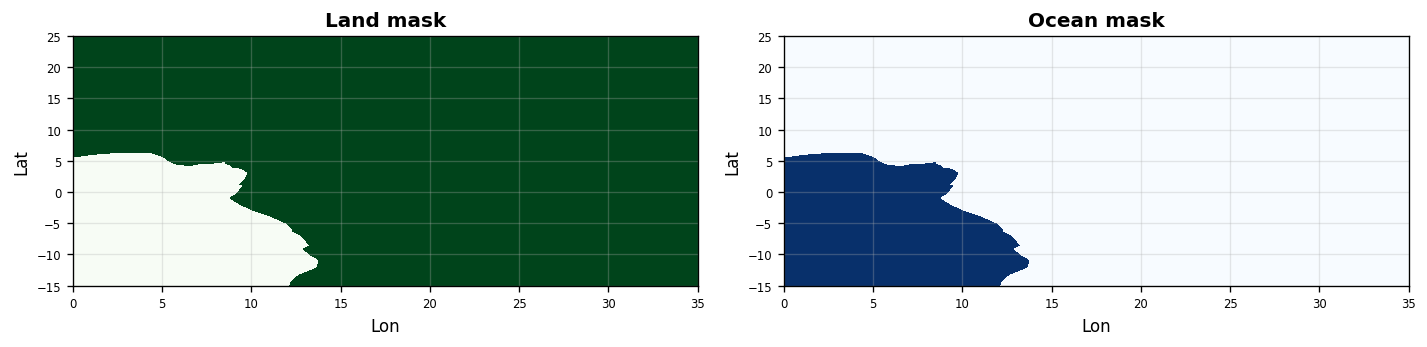

In [17]:
# ── 6.3  Land / sea mask ──────────────────────────────────────────────────────
# Uses the `regionmask` library to build a land mask from Natural Earth data.
# Creates ds_land (land-only) and ds_ocean (ocean-only) views.
# pip install regionmask if needed.



lat_dim = "lat" if "lat" in ds_subset.coords else "latitude"
lon_dim = "lon" if "lon" in ds_subset.coords else "longitude"

lats = ds_subset[lat_dim].values
lons = ds_subset[lon_dim].values

# 1 = land, 0 = ocean  (Natural Earth 110m land polygons)
land_110  = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = land_110.mask(lons, lats)   # shape: (lat, lon), NaN = ocean

# Boolean masks
is_land  = ~np.isnan(land_mask.values)
is_ocean = np.isnan(land_mask.values)

print(f"Grid size     : {len(lats)} lat × {len(lons)} lon = {len(lats)*len(lons):,} cells")
print(f"Land cells    : {is_land.sum():,}  ({100*is_land.mean():.1f}%)")
print(f"Ocean cells   : {is_ocean.sum():,}  ({100*is_ocean.mean():.1f}%)")

# Apply to dataset — land-only and ocean-only versions
ds_land  = ds_subset.where(land_mask.notnull())
ds_ocean = ds_subset.where(land_mask.isnull())

# Quick visual check
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].pcolormesh(lons, lats, is_land.astype(float),
                cmap="Greens", shading="auto")
axes[0].set_title("Land mask", fontweight="bold")
axes[1].pcolormesh(lons, lats, is_ocean.astype(float),
                cmap="Blues", shading="auto")
axes[1].set_title("Ocean mask", fontweight="bold")
for ax in axes:
    ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
    ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

Found 14 files
Source domain: lat[-15.00→25.00]  lon[0.00→35.00]
Target grid  : lat=79 × lon=69  (0.5°)
  ✓ aridity_coldest-quarter  (7, 79, 69)
  ✓ aridity_warmest-quarter  (7, 79, 69)
  ✓ cloud-cover_monthly-mean  (84, 79, 69)
  ✓ evaporative-fraction_coldest-quarter  (7, 79, 69)
  ✓ evaporative-fraction_warmest-quarter  (7, 79, 69)
  ✓ potential-evaporation_coldest-quarter  (7, 79, 69)
  ✓ potential-evaporation_warmest-quarter  (7, 79, 69)
  ✓ surface-latent-heat-flux_coldest-quarter  (7, 79, 69)
  ✓ surface-latent-heat-flux_warmest-quarter  (7, 79, 69)
  ✓ surface-sensible-heat-flux_coldest-quarter  (7, 79, 69)
  ✓ surface-sensible-heat-flux_warmest-quarter  (7, 79, 69)
  ✓ temperature_monthly-mean  (84, 79, 69)
  ✓ water-vapor-pressure_monthly-mean  (84, 79, 69)
  ✓ wind-speed_monthly-mean  (84, 79, 69)

✅ ds_regrid ready: {'time': 84, 'lat': 79, 'lon': 69}
   Variables: ['aridity_coldest-quarter', 'aridity_warmest-quarter', 'cloud-cover_monthly-mean', 'evaporative-fraction_coldes

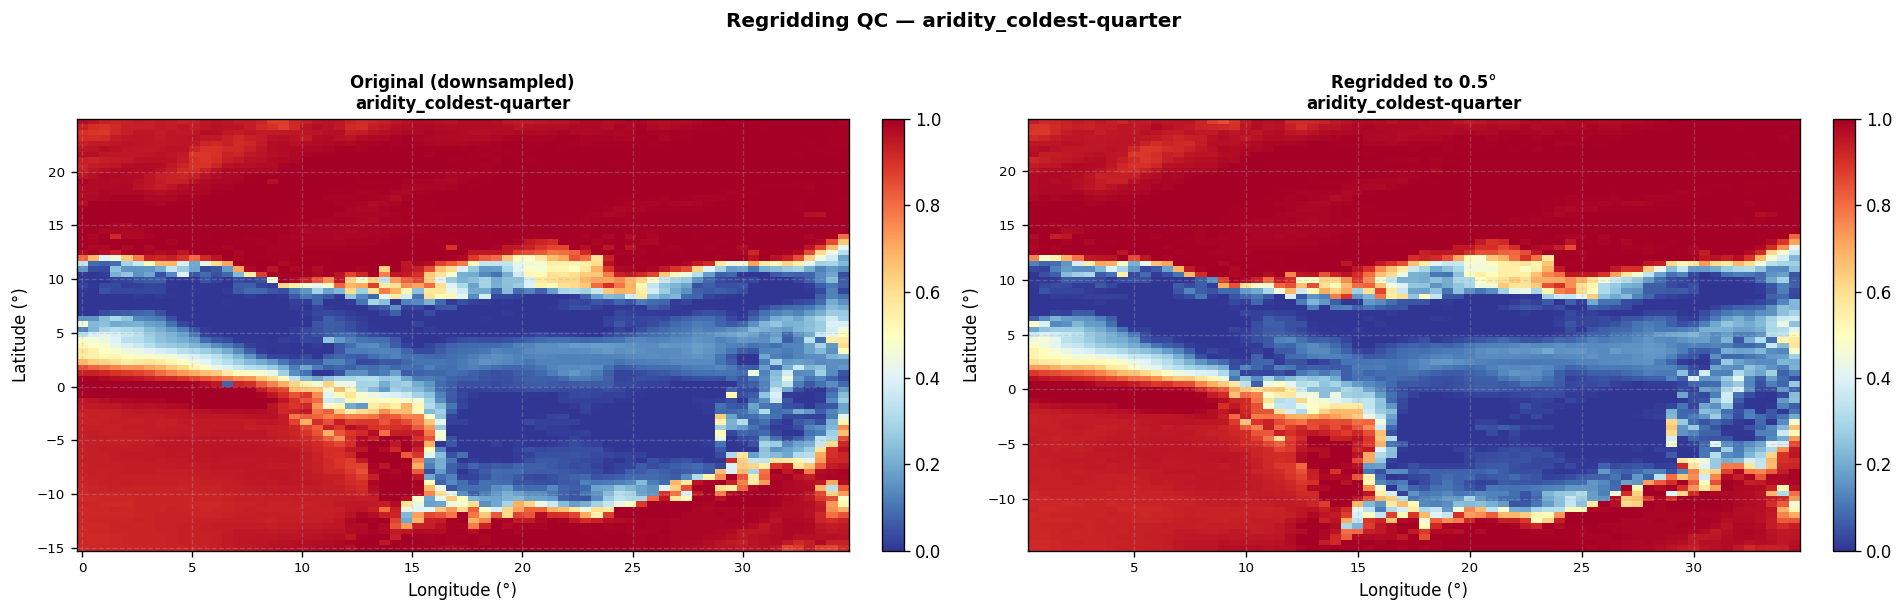

✓ Regrid QC plot done


In [18]:
# ── 6.4 · Regrid to regular lat/lon grid (no Dask) ───────────────────────────
target_res = CONFIG["target_resolution"]
TIME_START = CONFIG["time_start"]
TIME_END   = CONFIG["time_end"]

nc_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc")))
nc_files  = [f for f in nc_files if "Copie" not in os.path.basename(f)]
print(f"Found {len(nc_files)} files")

def _open_clip(nc_file, t0, t1):
    ds = xr.open_dataset(nc_file, engine="netcdf4")
    lat_name = next((c for c in ("lat","latitude")  if c in ds.coords), None)
    lon_name = next((c for c in ("lon","longitude") if c in ds.coords), None)
    if lat_name is None or lon_name is None:
        ds.close(); return None, None, None
    lv = ds[lon_name].values
    if np.nanmax(lv) > 180:
        ds = ds.assign_coords({lon_name: ((lv+180)%360)-180}).sortby(lon_name)
    if "time" in ds.dims:
        ds = ds.sel(time=slice(t0, t1))
        if ds.sizes.get("time", 0) == 0:
            ds.close(); return None, None, None
    return ds, lat_name, lon_name

# Probe first file for spatial domain only
ds0, lat0, lon0 = _open_clip(nc_files[0], TIME_START, TIME_END)
if ds0 is None:
    raise RuntimeError("Could not open first file.")
src_lat_min = float(ds0[lat0].min()); src_lat_max = float(ds0[lat0].max())
src_lon_min = float(ds0[lon0].min()); src_lon_max = float(ds0[lon0].max())
ds0.close()

print(f"Source domain: lat[{src_lat_min:.2f}→{src_lat_max:.2f}]  lon[{src_lon_min:.2f}→{src_lon_max:.2f}]")

lat_out = np.arange(np.ceil(src_lat_min/target_res)*target_res,
                    np.floor(src_lat_max/target_res)*target_res + target_res, target_res)
lon_out = np.arange(np.ceil(src_lon_min/target_res)*target_res,
                    np.floor(src_lon_max/target_res)*target_res + target_res, target_res)
print(f"Target grid  : lat={lat_out.size} × lon={lon_out.size}  ({target_res}°)")

lg, latg = np.meshgrid(lon_out, lat_out)
qpts     = np.column_stack([latg.ravel(), lg.ravel()])

# KEY FIX: store time coord per variable, not from a single probe file
regridded      = {}   # {var_name: ndarray}
regridded_time = {}   # {var_name: time_coord} — each file has its own time axis

for nc_file in nc_files:
    var_name = os.path.basename(nc_file).split("_hadgem2")[0]
    ds, lat_name, lon_name = _open_clip(nc_file, TIME_START, TIME_END)
    if ds is None:
        print(f"  ⚠️  {var_name}: skipped"); continue

    dvars = [v for v in ds.data_vars if lat_name in ds[v].dims and lon_name in ds[v].dims]
    if not dvars:
        ds.close(); continue

    dv      = dvars[0]
    src_lat = ds[lat_name].values
    src_lon = ds[lon_name].values
    is_3d   = "time" in ds[dv].dims and ds.sizes.get("time", 1) > 1

    if src_lat.size < 2 or src_lon.size < 2:
        ds.close(); continue

    if is_3d:
        nt  = ds.sizes["time"]
        regridded_time[var_name] = ds["time"].values   # store this file's time axis
        out = np.full((nt, lat_out.size, lon_out.size), np.nan, dtype=np.float32)
        for t in range(nt):
            patch = ds[dv].isel(time=t).values.astype(float)
            patch = np.where(np.abs(patch) > 1e10, np.nan, patch)
            if not np.all(np.isnan(patch)):
                mask = np.isnan(patch)
                if mask.any():
                    _, idx = distance_transform_edt(mask, return_indices=True)
                    patch  = patch[idx[0], idx[1]]
                fn = RegularGridInterpolator((src_lat, src_lon), patch,
                     method="linear", bounds_error=False, fill_value=np.nan)
                out[t] = fn(qpts).reshape(lat_out.size, lon_out.size)
        regridded[var_name] = out
    else:
        patch = np.squeeze(ds[dv].values).astype(float)
        if patch.ndim != 2:
            ds.close(); continue
        patch = np.where(np.abs(patch) > 1e10, np.nan, patch)
        if not np.all(np.isnan(patch)):
            mask = np.isnan(patch)
            if mask.any():
                _, idx = distance_transform_edt(mask, return_indices=True)
                patch  = patch[idx[0], idx[1]]
            fn  = RegularGridInterpolator((src_lat, src_lon), patch,
                  method="linear", bounds_error=False, fill_value=np.nan)
            out = fn(qpts).reshape(lat_out.size, lon_out.size).astype(np.float32)
        else:
            out = np.full((lat_out.size, lon_out.size), np.nan, dtype=np.float32)
        regridded[var_name] = out

    ds.close()
    print(f"  ✓ {var_name}  {regridded[var_name].shape}")

# ── Wrap into xr.Dataset using per-variable time coords ──────────────────────
data_arrays = {}
for vname, arr in regridded.items():
    if arr.ndim == 3:
        t_coord = regridded_time[vname]   # correct time axis for this variable
        data_arrays[vname] = xr.DataArray(
            arr, dims=["time","lat","lon"],
            coords={"time": t_coord, "lat": lat_out, "lon": lon_out}
        )
    else:
        data_arrays[vname] = xr.DataArray(
            arr, dims=["lat","lon"],
            coords={"lat": lat_out, "lon": lon_out}
        )

ds_regrid = xr.Dataset(data_arrays)
print(f"\n✅ ds_regrid ready: {dict(ds_regrid.sizes)}")
print(f"   Variables: {list(ds_regrid.data_vars)}")

# ── QC plot ───────────────────────────────────────────────────────────────────
plot_vars = [v for v in ds_regrid.data_vars if "lat" in ds_regrid[v].dims]
if plot_vars:
    var0  = plot_vars[0]
    da    = ds_regrid[var0]
    arr2d = da.isel(time=0).values if "time" in da.dims else da.values

    orig_file = next((f for f in nc_files if os.path.basename(f).startswith(var0)), nc_files[0])
    ds_o, lo, lno = _open_clip(orig_file, TIME_START, TIME_END)
    dvo      = [v for v in ds_o.data_vars if lo in ds_o[v].dims and lno in ds_o[v].dims][0]
    orig_a   = ds_o[dvo].isel(time=0).values if "time" in ds_o[dvo].dims else ds_o[dvo].values
    orig_lat = ds_o[lo].values
    orig_lon = ds_o[lno].values
    ds_o.close()

    lat_s  = max(1, round(orig_lat.size / lat_out.size))
    lon_s  = max(1, round(orig_lon.size / lon_out.size))
    orig_d = np.where(np.abs(orig_a[::lat_s, ::lon_s]) > 1e10, np.nan,
                      orig_a[::lat_s, ::lon_s].astype(float))
    vmin   = np.nanpercentile(orig_d, 2)
    vmax   = np.nanpercentile(orig_d, 98)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    im0 = axes[0].pcolormesh(orig_lon[::lon_s], orig_lat[::lat_s], orig_d,
                              cmap="RdYlBu_r", shading="auto", vmin=vmin, vmax=vmax)
    axes[0].set_title(f"Original (downsampled)\n{var0}", fontsize=10, fontweight="bold")
    plt.colorbar(im0, ax=axes[0], fraction=0.03, pad=0.04)
    im1 = axes[1].pcolormesh(lon_out, lat_out, arr2d,
                              cmap="RdYlBu_r", shading="auto", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"Regridded to {target_res}°\n{var0}", fontsize=10, fontweight="bold")
    plt.colorbar(im1, ax=axes[1], fraction=0.03, pad=0.04)
    for ax in axes:
        ax.set_xlabel("Longitude (°)"); ax.set_ylabel("Latitude (°)")
        ax.tick_params(labelsize=8); ax.grid(True, alpha=0.3, linestyle="--")
    plt.suptitle(f"Regridding QC — {var0}", fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()
    print("✓ Regrid QC plot done")

In [19]:
# ── 6.4-B · Save regrid outputs to CSV ──────────────────────

from scipy.stats import linregress
from pathlib import Path

output_dir = Path(CONFIG["output_dir"]) if "CONFIG" in globals() and "output_dir" in CONFIG else Path("outputs")
output_dir.mkdir(exist_ok=True)

print("─── Exporting spatial grids to CSV ───")

# FILE 1: spatial_mean_maps.csv
try:
    rows_mean = []
    if "regridded" in globals():
        for var_name, arr in regridded.items():
            if arr.ndim == 3:
                time_mean = np.nanmean(arr, axis=0)
            elif arr.ndim == 2:
                time_mean = arr
            else:
                continue

            time_mean = np.where(np.abs(time_mean) > 1e10, np.nan, time_mean)
            
            for i, la in enumerate(lat_out):
                for j, lo in enumerate(lon_out):
                    v = time_mean[i, j]
                    if not np.isnan(v):
                        rows_mean.append({"variable": var_name, "lat": round(float(la), 4), "lon": round(float(lo), 4), "value": round(float(v), 6)})
        
        pd.DataFrame(rows_mean).to_csv(output_dir / "spatial_mean_maps.csv", index=False)
        print(f"✓ Saved spatial_mean_maps.csv  ({len(rows_mean)} rows)")
    else:
        print("⚠️ Skipped spatial_mean_maps.csv: 'regridded' not found.")
except Exception as e:
    print(f"⚠️ Failed spatial_mean_maps.csv: {e}")

# FILE 2: spatial_period_maps.csv
try:
    rows_period = []
    if "regridded" in globals() and "regridded_time" in globals():
        for var_name, arr in regridded.items():
            if arr.ndim == 3 and var_name in regridded_time:
                t_coord = regridded_time[var_name]
                t_years = pd.DatetimeIndex(t_coord).year
                
                for period_year, period_label in zip(PERIOD_YEARS, PERIOD_LABELS):
                    idx = np.where(t_years == period_year)[0]
                    if len(idx) == 0:
                        continue
                    period_slice = np.nanmean(arr[idx], axis=0)
                    period_slice = np.where(np.abs(period_slice) > 1e10, np.nan, period_slice)
                    
                    for i, la in enumerate(lat_out):
                        for j, lo in enumerate(lon_out):
                            v = period_slice[i, j]
                            if not np.isnan(v):
                                rows_period.append({
                                    "variable": var_name, 
                                    "period_label": period_label, 
                                    "period_year": period_year, 
                                    "lat": round(float(la), 4), 
                                    "lon": round(float(lo), 4), 
                                    "value": round(float(v), 6)
                                })
        
        pd.DataFrame(rows_period).to_csv(output_dir / "spatial_period_maps.csv", index=False)
        print(f"✓ Saved spatial_period_maps.csv  ({len(rows_period)} rows)")
    else:
        print("⚠️ Skipped spatial_period_maps.csv: 'regridded' or 'regridded_time' not found.")
except Exception as e:
    print(f"⚠️ Failed spatial_period_maps.csv: {e}")

# FILE 3: trend_slope_maps.csv
try:
    rows_slope = []
    if "regridded" in globals():
        for var_name, arr in regridded.items():
            if arr.ndim == 3:
                arr_f = np.where(np.abs(arr) > 1e10, np.nan, arr).astype(float)
                nt, nlat, nlon = arr_f.shape
                x = np.arange(nt, dtype=float)
                flat = arr_f.reshape(nt, -1)
                
                for j in range(flat.shape[1]):
                    col = flat[:, j]
                    valid = ~np.isnan(col)
                    if valid.sum() >= 3:
                        sl = linregress(x[valid], col[valid]).slope
                        lat_idx = j // lon_out.size
                        lon_idx = j % lon_out.size
                        rows_slope.append({
                            "variable": var_name, 
                            "lat": round(float(lat_out[lat_idx]), 4), 
                            "lon": round(float(lon_out[lon_idx]), 4), 
                            "slope": float(sl)
                        })
        
        pd.DataFrame(rows_slope).to_csv(output_dir / "trend_slope_maps.csv", index=False)
        print(f"✓ Saved trend_slope_maps.csv  ({len(rows_slope)} rows)")
    else:
         print("⚠️ Skipped trend_slope_maps.csv: 'regridded' not found.")
except Exception as e:
    print(f"⚠️ Failed trend_slope_maps.csv: {e}")

# FILE 4: outputs/eof_pc_scores.csv and outputs/eof_spatial_loadings.csv
try:
    if all(v in globals() for v in ["pcs", "eofs", "explained", "da_annual", "valid_mask", "data"]):
        years = pd.DatetimeIndex(da_annual.time.values).year
        
        # PC scores
        pc_rows = []
        for t, yr in enumerate(years):
            for i in range(pcs.shape[1]):
                pc_rows.append({"year": int(yr), "pc": f"PC{i+1}",
                                "score": float(pcs[t, i]),
                                "variance_explained_pct": float(explained[i])})
        pd.DataFrame(pc_rows).to_csv(output_dir / "eof_pc_scores.csv", index=False)
        print(f"✓ Saved eof_pc_scores.csv  ({len(pc_rows)} rows)")

        # EOF spatial patterns
        eof_rows = []
        for i in range(eofs.shape[0]):
            eof_map = np.full(data.shape[1], np.nan)
            eof_map[valid_mask] = eofs[i]
            eof_map = eof_map.reshape(len(lat_out), len(lon_out))
            for r, la in enumerate(lat_out):
                for c, lo in enumerate(lon_out):
                    v = eof_map[r, c]
                    if not np.isnan(v):
                        eof_rows.append({"eof": f"EOF{i+1}", "lat": round(float(la), 4),
                                         "lon": round(float(lo), 4), "loading": float(v),
                                         "variance_explained_pct": float(explained[i])})
        pd.DataFrame(eof_rows).to_csv(output_dir / "eof_spatial_loadings.csv", index=False)
        print(f"✓ Saved eof_spatial_loadings.csv  ({len(eof_rows)} rows)")
    else:
        print("⚠️  EOF outputs skipped — run Section 7.4 first, then re-run this cell")
except Exception as e:
    print(f"⚠️ Failed EOF CSV generation: {e}")

print("\n✅ Regrid export complete — files in outputs/:")
for f_name, row_list in [("spatial_mean_maps.csv", rows_mean if 'rows_mean' in locals() else None), 
                         ("spatial_period_maps.csv", rows_period if 'rows_period' in locals() else None),
                         ("trend_slope_maps.csv", rows_slope if 'rows_slope' in locals() else None),
                         ("eof_pc_scores.csv", pc_rows if 'pc_rows' in locals() else None),
                         ("eof_spatial_loadings.csv", eof_rows if 'eof_rows' in locals() else None)]:
    if row_list is not None:
        print(f"  - {f_name}: {len(row_list)} rows")
    else:
        print(f"  - {f_name}: SKIPPED/FAILED")

─── Exporting spatial grids to CSV ───
✓ Saved spatial_mean_maps.csv  (76314 rows)
✓ Saved spatial_period_maps.csv  (534198 rows)
✓ Saved trend_slope_maps.csv  (76314 rows)
⚠️  EOF outputs skipped — run Section 7.4 first, then re-run this cell

✅ Regrid export complete — files in outputs/:
  - spatial_mean_maps.csv: 76314 rows
  - spatial_period_maps.csv: 534198 rows
  - trend_slope_maps.csv: 76314 rows
  - eof_pc_scores.csv: SKIPPED/FAILED
  - eof_spatial_loadings.csv: SKIPPED/FAILED


  ✓ aridity_coldest-quarter
  ✓ aridity_warmest-quarter
  ✓ cloud-cover_monthly-mean
  ✓ evaporative-fraction_coldest-quarter
  ✓ evaporative-fraction_warmest-quarter
  ✓ potential-evaporation_coldest-quarter
  ✓ potential-evaporation_warmest-quarter
  ✓ surface-latent-heat-flux_coldest-quarter
  ✓ surface-latent-heat-flux_warmest-quarter
  ✓ surface-sensible-heat-flux_coldest-quarter
  ✓ surface-sensible-heat-flux_warmest-quarter
  ✓ temperature_monthly-mean
  ✓ water-vapor-pressure_monthly-mean
  ✓ wind-speed_monthly-mean

✅ Regional aggregation complete: ['North Africa', 'Sahel', 'West Africa']
   North Africa: 14 variables
   Sahel: 14 variables
   West Africa: 14 variables


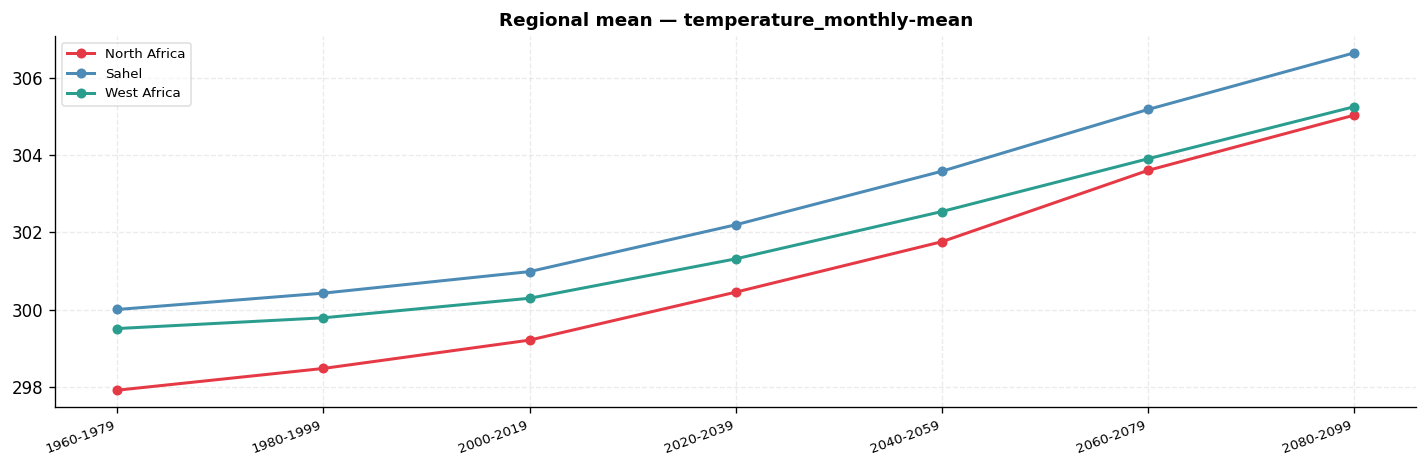

In [20]:
# ── 6.5 · Regional aggregation (no Dask) ─────────────────────────────────────
# Reads each file directly, clips to region, interpolates to target_res,
# computes area-weighted spatial mean → time series per region per variable.

REGIONS    = CONFIG["regions"]
target_res = CONFIG["target_resolution"]
TIME_START = CONFIG["time_start"]
TIME_END   = CONFIG["time_end"]

nc_files_r = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc")))
nc_files_r  = [f for f in nc_files_r if "Copie" not in os.path.basename(f)]

def _weighted_mean(vals2d, w2d):
    valid = ~np.isnan(vals2d)
    denom = np.sum(w2d * valid)
    return np.nansum(vals2d * w2d) / denom if denom > 0 else np.nan

region_ts    = {r: {} for r in REGIONS}
years_all_rg = None
use_annual   = False
n_times_rg   = 0

for nc_file in nc_files_r:
    var_name = os.path.basename(nc_file).split("_hadgem2")[0]
    try:
        ds_raw = xr.open_dataset(nc_file, engine="netcdf4")
    except Exception as e:
        print(f"  ⚠️  {var_name}: cannot open — {e}"); continue

    lat_name = next((c for c in ("lat","latitude")  if c in ds_raw.coords), None)
    lon_name = next((c for c in ("lon","longitude") if c in ds_raw.coords), None)
    if lat_name is None or lon_name is None:
        ds_raw.close(); continue
    lv = ds_raw[lon_name].values
    if np.nanmax(lv) > 180:
        ds_raw = ds_raw.assign_coords({lon_name: ((lv+180)%360)-180}).sortby(lon_name)
    if "time" in ds_raw.dims:
        try:
            ds_raw = ds_raw.sel(time=slice(TIME_START, TIME_END))
        except Exception:
            pass
        if ds_raw.sizes.get("time", 0) == 0:
            ds_raw.close(); continue

    if years_all_rg is None and "time" in ds_raw.dims:
        years_all_rg = ds_raw.time.dt.year.values
        n_years_rg   = len(np.unique(years_all_rg))
        use_annual   = n_years_rg > 1
        n_times_rg   = ds_raw.sizes["time"]

    dvars = [v for v in ds_raw.data_vars
             if lat_name in ds_raw[v].dims and lon_name in ds_raw[v].dims
             and "time" in ds_raw[v].dims]
    if not dvars:
        ds_raw.close(); continue
    dv = dvars[0]

    src_lat_rg = ds_raw[lat_name].values
    src_lon_rg = ds_raw[lon_name].values

    for region, bounds in REGIONS.items():
        r_lat_min, r_lat_max = bounds["lat"]
        r_lon_min, r_lon_max = bounds["lon"]
        clip_lat_min = max(r_lat_min, float(src_lat_rg.min()))
        clip_lat_max = min(r_lat_max, float(src_lat_rg.max()))
        clip_lon_min = max(r_lon_min, float(src_lon_rg.min()))
        clip_lon_max = min(r_lon_max, float(src_lon_rg.max()))
        if clip_lat_min >= clip_lat_max or clip_lon_min >= clip_lon_max:
            continue

        ds_clip = ds_raw.sel({
            lat_name: slice(clip_lat_min, clip_lat_max),
            lon_name: slice(clip_lon_min, clip_lon_max),
        })
        if ds_clip.sizes.get(lat_name,0)==0 or ds_clip.sizes.get(lon_name,0)==0:
            continue

        reg_lat = ds_clip[lat_name].values
        reg_lon = ds_clip[lon_name].values
        lat_tile = np.arange(np.ceil(clip_lat_min/target_res)*target_res,
                             np.floor(clip_lat_max/target_res)*target_res+target_res, target_res)
        lon_tile = np.arange(np.ceil(clip_lon_min/target_res)*target_res,
                             np.floor(clip_lon_max/target_res)*target_res+target_res, target_res)
        if lat_tile.size == 0 or lon_tile.size == 0:
            continue

        w1d  = np.cos(np.deg2rad(lat_tile))
        w2d  = (w1d/w1d.sum())[:,None]*np.ones(lon_tile.size)
        lg, latg = np.meshgrid(lon_tile, lat_tile)
        qpts = np.column_stack([latg.ravel(), lg.ravel()])

        nt = ds_clip.sizes["time"]
        ts = np.full(nt, np.nan)
        for t in range(nt):
            patch = ds_clip[dv].isel(time=t).values.astype(float)
            patch = np.where(np.abs(patch)>1e10, np.nan, patch)
            if np.all(np.isnan(patch)):
                continue
            if reg_lat.size < 2 or reg_lon.size < 2:
                ts[t] = np.nanmean(patch)
                continue
            mask = np.isnan(patch)
            if mask.any():
                _, idx = distance_transform_edt(mask, return_indices=True)
                patch  = patch[idx[0], idx[1]]
            fn = RegularGridInterpolator((reg_lat, reg_lon), patch,
                 method="linear", bounds_error=False, fill_value=np.nan)
            ts[t] = _weighted_mean(fn(qpts).reshape(lat_tile.size, lon_tile.size), w2d)
        region_ts[region][var_name] = ts

    ds_raw.close()
    print(f"  ✓ {var_name}")

# Set period x-axis
if years_all_rg is not None:
    if use_annual:
        unique_yrs = np.unique(years_all_rg)
        region_years = unique_yrs
        # For quarterly files: ts already has n_periods points
        # For monthly files: average 12 months per period
        for region in region_ts:
            for var_name in list(region_ts[region].keys()):
                ts = region_ts[region][var_name]
                if len(ts) == len(unique_yrs):
                    pass   # already period-length (quarterly)
                elif len(ts) % len(unique_yrs) == 0:
                    n_mon = len(ts) // len(unique_yrs)
                    region_ts[region][var_name] = np.array(
                        [ts[i*n_mon:(i+1)*n_mon].mean() for i in range(len(unique_yrs))]
                    )
    else:
        region_years = years_all_rg
else:
    region_years = None

print(f"\n✅ Regional aggregation complete: {list(region_ts.keys())}")
for r, vd in region_ts.items():
    print(f"   {r}: {len(vd)} variables")

# ── Plot: temperature by region ───────────────────────────────────────────────
temp_var = next((v for v in (list(region_ts.get(list(REGIONS.keys())[0],{}).keys()))
                 if "temperature" in v.lower()), None)

if temp_var and region_years is not None:
    colors = ["#E63946","#4C8BB5","#2A9D8F"]
    fig, ax = plt.subplots(figsize=(12, 4))
    for region, color in zip(REGIONS, colors):
        vals = region_ts.get(region, {}).get(temp_var)
        if vals is None or len(vals)==0: continue
        x      = PERIOD_LABELS[:len(vals)] if len(vals)==len(PERIOD_LABELS) else list(range(len(vals)))
        marker = "o"
        ax.plot(range(len(vals)), vals, lw=1.8, color=color, marker=marker,
                markersize=5, label=region)
    ax.set_xticks(range(len(PERIOD_LABELS)))
    ax.set_xticklabels(PERIOD_LABELS, fontsize=8, rotation=20, ha="right")
    ax.set_title(f"Regional mean — {temp_var}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8, framealpha=0.6)
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.show()

Interpretation: Regridded and regionalized data are now comparable across datasets and ready for exploratory data analysis.

## Exploratory data analysis (Section 7)

Runs on metadata, samples, and cleaned datasets to summarize structure and behavior.

### File inventory overview (Section 7-1)

In [21]:
print("=" * 55)
print("FILE INVENTORY")
print("=" * 55)
print(meta_df.to_string(index=False))
print()
print(f"Total on-disk size : {meta_df.size_mb.sum():.0f} MB")
print(f"Year span          : {meta_df.start.min()} - {meta_df.end.max()}")
print(f"Total time steps   : {meta_df.steps.sum():,}")

FILE INVENTORY
                                                                                     file  start  end  steps  size_mb
                   aridity_coldest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090      7    564.6
                   aridity_warmest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090      7    564.6
                  cloud-cover_monthly-mean_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090     84   6773.9
      evaporative-fraction_coldest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090      7    564.6
      evaporative-fraction_warmest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090      7    564.6
     potential-evaporation_coldest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090      7    564.6
     potential-evaporation_warmest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc   1970 2090      7    564.6
  surface-latent-heat-flux_coldest-quarte

### Variable inventory and data types (Section 7-2)

In [22]:
# Variable inventory from the first qualifying file
probe_file = next(
    (os.path.join(DATA_DIR, r["file"]) for _, r in meta_df.iterrows() if r["end"] >= CONFIG["min_end_year"]),
    None,
)

if probe_file:
    with xr.open_dataset(probe_file, engine="netcdf4") as ds_probe:
        print("Dimensions :")
        for dim, size in ds_probe.sizes.items():
            print(f"  {dim:20s}  {size:>8,}")

        print("\nVariables :")
        var_rows = []
        for v in ds_probe.data_vars:
            da    = ds_probe[v]
            dims  = str(da.dims)
            dtype = str(da.dtype)
            units = da.attrs.get("units", "-")
            fill  = da.attrs.get("_FillValue", "-")
            var_rows.append(dict(variable=v, dims=dims, dtype=dtype,
                                 units=units, fill_value=fill))
        var_df = pd.DataFrame(var_rows)
        print(var_df.to_string(index=False))
else:
    print("No file reaching the requested baseline year found.")

Dimensions :
  time                         7
  latitude                 4,800
  longitude                4,200

Variables :
               variable                              dims   dtype units fill_value
                 height                                () float64     m          -
aridity_coldest-quarter ('time', 'latitude', 'longitude') float32     1          -


### Time-axis diagnostics (Section 7-3)

In [23]:
# Checks: calendar type, resolution, duplicates, gaps
print("TIME AXIS DIAGNOSTICS")
print("=" * 55)
issues_found = False

for _, row in meta_df.iterrows():
    fp = os.path.join(DATA_DIR, row["file"])
    with xr.open_dataset(fp, engine="netcdf4") as ds_in:
        t = ds_in["time"]
        cal = t.encoding.get("calendar", "unknown")
        t_vals = t.values
        n_dupes = int(pd.Series(t_vals).duplicated().sum())

        if t.size > 1:
            deltas = np.diff(t_vals).astype("timedelta64[h]").astype(int)
            modal_step = int(pd.Series(deltas).mode()[0])
            n_gaps = int((deltas != modal_step).sum())
        else:
            modal_step, n_gaps = 0, 0

        flag = "OK" if (n_dupes == 0 and n_gaps == 0) else "WARN"
        if n_dupes or n_gaps:
            issues_found = True

        print(f"{flag:4s} {row['file']}")
        print(f"     calendar={cal}, step={modal_step}h, duplicates={n_dupes}, irregular_steps={n_gaps}")

if not issues_found:
    print("\nNo time-axis issues detected across all files.")

TIME AXIS DIAGNOSTICS
WARN aridity_coldest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc
     calendar=proleptic_gregorian, step=175320h, duplicates=0, irregular_steps=2
WARN aridity_warmest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc
     calendar=proleptic_gregorian, step=175320h, duplicates=0, irregular_steps=2
WARN cloud-cover_monthly-mean_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc
     calendar=proleptic_gregorian, step=744h, duplicates=0, irregular_steps=41
WARN evaporative-fraction_coldest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc
     calendar=proleptic_gregorian, step=175320h, duplicates=0, irregular_steps=2
WARN evaporative-fraction_warmest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc
     calendar=proleptic_gregorian, step=175320h, duplicates=0, irregular_steps=2
WARN potential-evaporation_coldest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc
     calendar=proleptic_gregorian, step=175320h, duplicates=0, irregular_steps

### Missing-value scan (Section 7-4)

Sampled one step per file.

In [24]:
print("MISSING VALUE SCAN (1-step sample per file)")
print("=" * 55)

mv_rows = []
for _, row in meta_df.iterrows():
    fp = os.path.join(DATA_DIR, row["file"])
    with xr.open_dataset(fp, engine="netcdf4") as ds_in:
        ds_step = ds_in.isel(time=0).load()
        for v in ds_step.data_vars:
            arr   = ds_step[v].values.astype(float)
            total = arr.size
            n_nan = int(np.isnan(arr).sum())
            pct   = 100 * n_nan / total if total else 0
            mv_rows.append(dict(file=row["file"], variable=v,
                                total_cells=total, missing=n_nan,
                                missing_pct=round(pct, 2)))

mv_df = pd.DataFrame(mv_rows)
print(mv_df.to_string(index=False))

high_miss = mv_df[mv_df.missing_pct > 5]
if not high_miss.empty:
    print("\nVariables with >5% missing in sampled slice:")
    print(high_miss[["file", "variable", "missing_pct"]].to_string(index=False))
else:
    print("\nNo variable exceeds 5% missing in sampled slices.")

MISSING VALUE SCAN (1-step sample per file)
                                                                                     file                                   variable  total_cells  missing  missing_pct
                   aridity_coldest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc                                     height            1        0          0.0
                   aridity_coldest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc                    aridity_coldest-quarter     20160000        0          0.0
                   aridity_warmest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc                                     height            1        0          0.0
                   aridity_warmest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc                    aridity_warmest-quarter     20160000        0          0.0
                  cloud-cover_monthly-mean_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc                           

### Value-range sanity check (Section 7-5)

Sampled one step per file.

In [25]:
print("VALUE RANGE CHECK (1-step sample per file)")
print("=" * 55)

range_rows = []
for _, row in meta_df.iterrows():
    fp = os.path.join(DATA_DIR, row["file"])
    with xr.open_dataset(fp, engine="netcdf4") as ds_in:
        ds_step = ds_in.isel(time=0).load()
        for v in ds_step.data_vars:
            arr = ds_step[v].values.astype(float)
            arr = arr[~np.isnan(arr)]
            if arr.size == 0:
                continue
            range_rows.append(dict(
                file=row["file"], variable=v,
                min=round(float(arr.min()), 4),
                max=round(float(arr.max()), 4),
                mean=round(float(arr.mean()), 4),
                std=round(float(arr.std()), 4),
            ))

range_df = pd.DataFrame(range_rows)
print(range_df.to_string(index=False))

VALUE RANGE CHECK (1-step sample per file)
                                                                                     file                                   variable       min       max     mean      std
                   aridity_coldest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc                                     height    1.5000    1.5000   1.5000   0.0000
                   aridity_coldest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc                    aridity_coldest-quarter    0.0000    1.0000   0.6254   0.4207
                   aridity_warmest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc                                     height    1.5000    1.5000   1.5000   0.0000
                   aridity_warmest-quarter_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc                    aridity_warmest-quarter    0.0000    1.0000   0.6798   0.3357
                  cloud-cover_monthly-mean_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc             

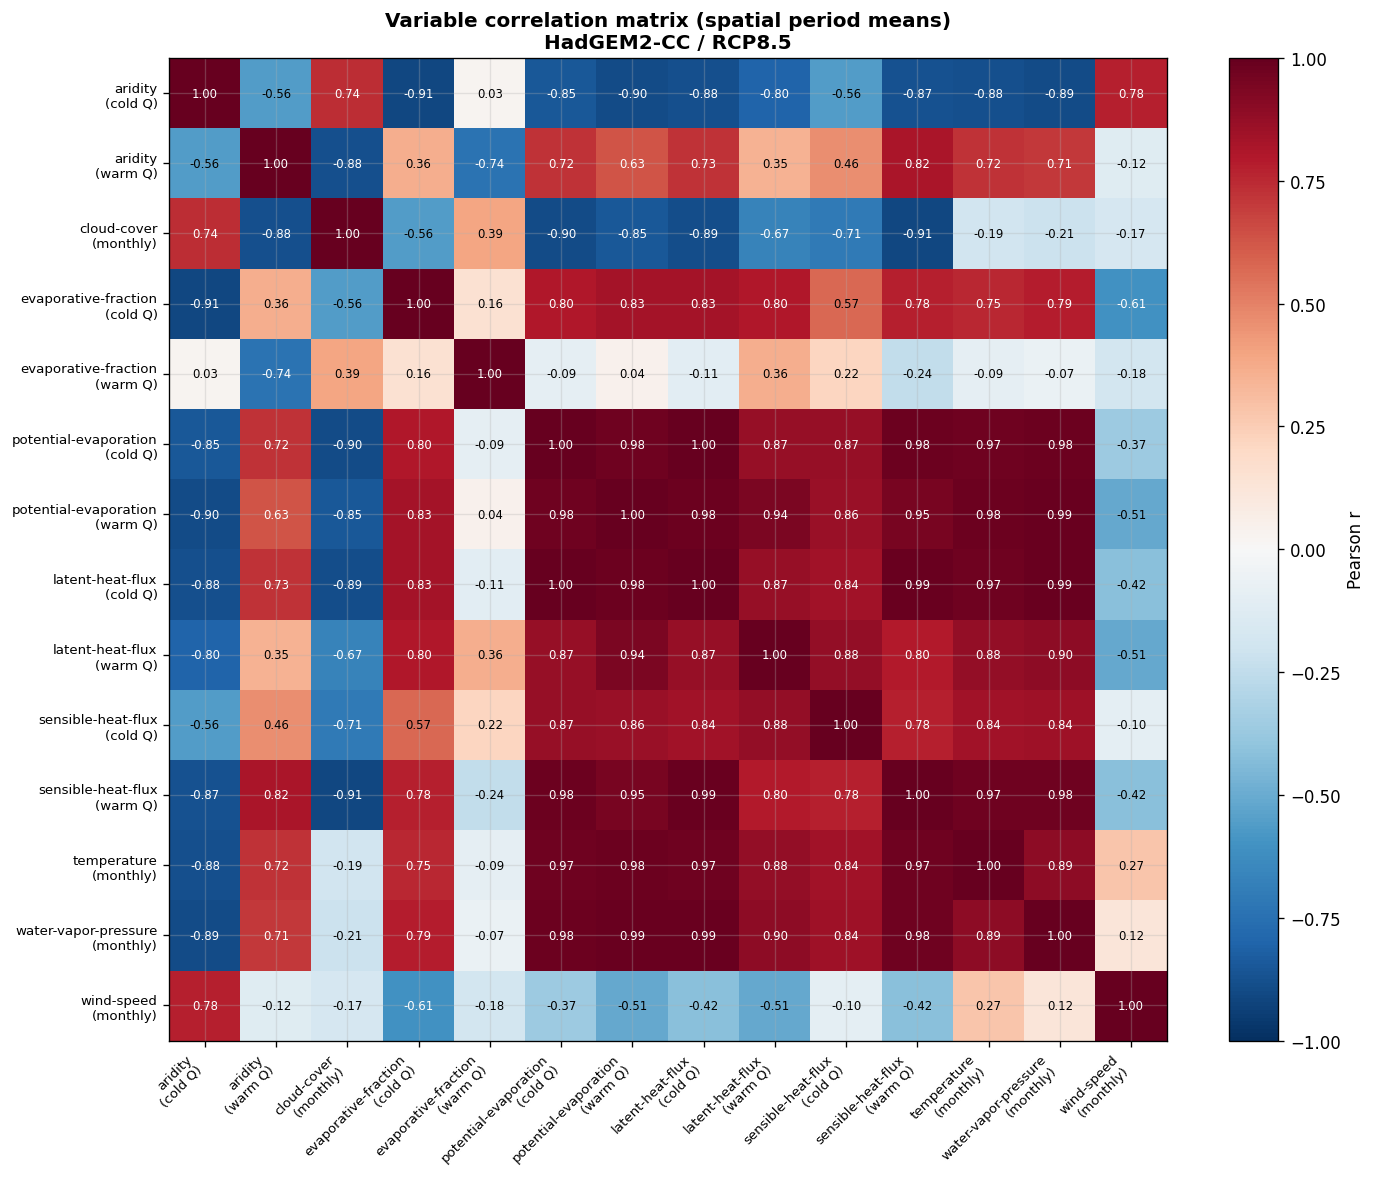

In [26]:
# ── Cross-variable correlation heatmap (spatial mean, all periods) ────────────

# Build a DataFrame: one column per variable, one row per (period × grid-cell mean)
records = {}
for var in ds_regrid.data_vars:
    try:
        # mean over spatial dims for each time step
        spatial_mean = ds_regrid[var].mean(
            dim=[d for d in ds_regrid[var].dims if d != "time"]
        ).values
        records[var] = spatial_mean
    except Exception:
        pass

corr_df = pd.DataFrame(records).corr()

# shorten long variable names for readability
short_names = {v: v.replace("surface-", "").replace("_monthly-mean", "\n(monthly)")
                   .replace("_coldest-quarter", "\n(cold Q)")
                   .replace("_warmest-quarter", "\n(warm Q)")
               for v in corr_df.columns}
corr_df = corr_df.rename(index=short_names, columns=short_names)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_df.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.index)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr_df.index, fontsize=8)

# annotate cells with correlation value
for row_i in range(len(corr_df)):
    for col_j in range(len(corr_df.columns)):
        val = corr_df.values[row_i, col_j]
        text_color = "white" if abs(val) > 0.6 else "black"
        ax.text(col_j, row_i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color=text_color)

plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title(
    f"Variable correlation matrix (spatial period means)\n"
    f"{CONFIG['cmip5_model']} / {CONFIG['cmip5_scenario']}",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Visual diagnostics (Section 7-6)

Interpretation: EDA highlights data coverage, structure, and missingness patterns to guide later analysis choices.

### Post-cleaning diagnostics (Section 7-7)

In [27]:
# ── 7-7 · Post-cleaning statistics (direct NetCDF4 reads, no Dask) ──────────

print("Computing statistics (spatial mean per time step, no Dask)...\n")
stats_rows = []

nc_files_s = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc")))
nc_files_s  = [f for f in nc_files_s if "Copie" not in os.path.basename(f)]

for nc_file in nc_files_s:
    var_name = os.path.basename(nc_file).split("_hadgem2")[0]
    try:
        ds = xr.open_dataset(nc_file, engine="netcdf4")
    except Exception as e:
        print(f"  ⚠️  {var_name}: {e}"); continue

    lat_name = next((c for c in ("lat","latitude")  if c in ds.coords), None)
    lon_name = next((c for c in ("lon","longitude") if c in ds.coords), None)
    if "time" not in ds.dims:
        ds.close(); continue
    try:
        ds = ds.sel(time=slice(CONFIG["time_start"], CONFIG["time_end"]))
    except Exception:
        pass
    if ds.sizes.get("time", 0) == 0:
        ds.close(); continue

    dvars = [v for v in ds.data_vars
             if lat_name and lon_name
             and lat_name in ds[v].dims and lon_name in ds[v].dims
             and "time" in ds[v].dims]
    if not dvars:
        ds.close(); continue

    dv   = dvars[0]
    n_t  = ds.sizes["time"]
    vals = np.full(n_t, np.nan)
    for t in range(n_t):
        patch = ds[dv].isel(time=t).values.astype(float)
        patch = np.where(np.abs(patch) > 1e10, np.nan, patch)
        if not np.all(np.isnan(patch)):
            vals[t] = np.nanmean(patch)
    ds.close()

    valid = vals[~np.isnan(vals)]
    stats_rows.append(dict(
        variable = var_name,
        n_steps  = n_t,
        mean     = round(float(np.mean(valid)),  4) if valid.size else np.nan,
        std      = round(float(np.std(valid)),   4) if valid.size > 1 else 0.0,
        min      = round(float(np.min(valid)),   4) if valid.size else np.nan,
        max      = round(float(np.max(valid)),   4) if valid.size else np.nan,
        nan_pct  = round(float(np.isnan(vals).mean()) * 100, 2),
    ))
    print(f"  ✓ {var_name}  (n={n_t}, mean={stats_rows[-1]['mean']})")

stats_df = pd.DataFrame(stats_rows)
print("\n" + "="*65)
print("POST-CLEANING STATISTICS (spatial mean per period)")
print("="*65)
print(stats_df.to_string(index=False))

Computing statistics (spatial mean per time step, no Dask)...

  ✓ aridity_coldest-quarter  (n=7, mean=0.609)
  ✓ aridity_warmest-quarter  (n=7, mean=0.6784)
  ✓ cloud-cover_monthly-mean  (n=84, mean=0.5184)
  ✓ evaporative-fraction_coldest-quarter  (n=7, mean=0.5259)
  ✓ evaporative-fraction_warmest-quarter  (n=7, mean=0.4309)
  ✓ potential-evaporation_coldest-quarter  (n=7, mean=0.0)
  ✓ potential-evaporation_warmest-quarter  (n=7, mean=0.0)
  ✓ surface-latent-heat-flux_coldest-quarter  (n=7, mean=59.8704)
  ✓ surface-latent-heat-flux_warmest-quarter  (n=7, mean=55.99)
  ✓ surface-sensible-heat-flux_coldest-quarter  (n=7, mean=31.2709)
  ✓ surface-sensible-heat-flux_warmest-quarter  (n=7, mean=56.8309)
  ✓ temperature_monthly-mean  (n=84, mean=299.9696)
  ✓ water-vapor-pressure_monthly-mean  (n=84, mean=1120.9323)
  ✓ wind-speed_monthly-mean  (n=84, mean=3.1045)

POST-CLEANING STATISTICS (spatial mean per period)
                                  variable  n_steps      mean      std 

Computing spatial means per period...

  ✓ aridity_coldest-quarter  (7 raw → 7 period means)
  ✓ aridity_warmest-quarter  (7 raw → 7 period means)
  ✓ cloud-cover_monthly-mean  (84 raw → 7 period means)
  ✓ evaporative-fraction_coldest-quarter  (7 raw → 7 period means)
  ✓ evaporative-fraction_warmest-quarter  (7 raw → 7 period means)
  ✓ potential-evaporation_coldest-quarter  (7 raw → 7 period means)
  ✓ potential-evaporation_warmest-quarter  (7 raw → 7 period means)
  ✓ surface-latent-heat-flux_coldest-quarter  (7 raw → 7 period means)
  ✓ surface-latent-heat-flux_warmest-quarter  (7 raw → 7 period means)
  ✓ surface-sensible-heat-flux_coldest-quarter  (7 raw → 7 period means)
  ✓ surface-sensible-heat-flux_warmest-quarter  (7 raw → 7 period means)
  ✓ temperature_monthly-mean  (84 raw → 7 period means)
  ✓ water-vapor-pressure_monthly-mean  (84 raw → 7 period means)
  ✓ wind-speed_monthly-mean  (84 raw → 7 period means)


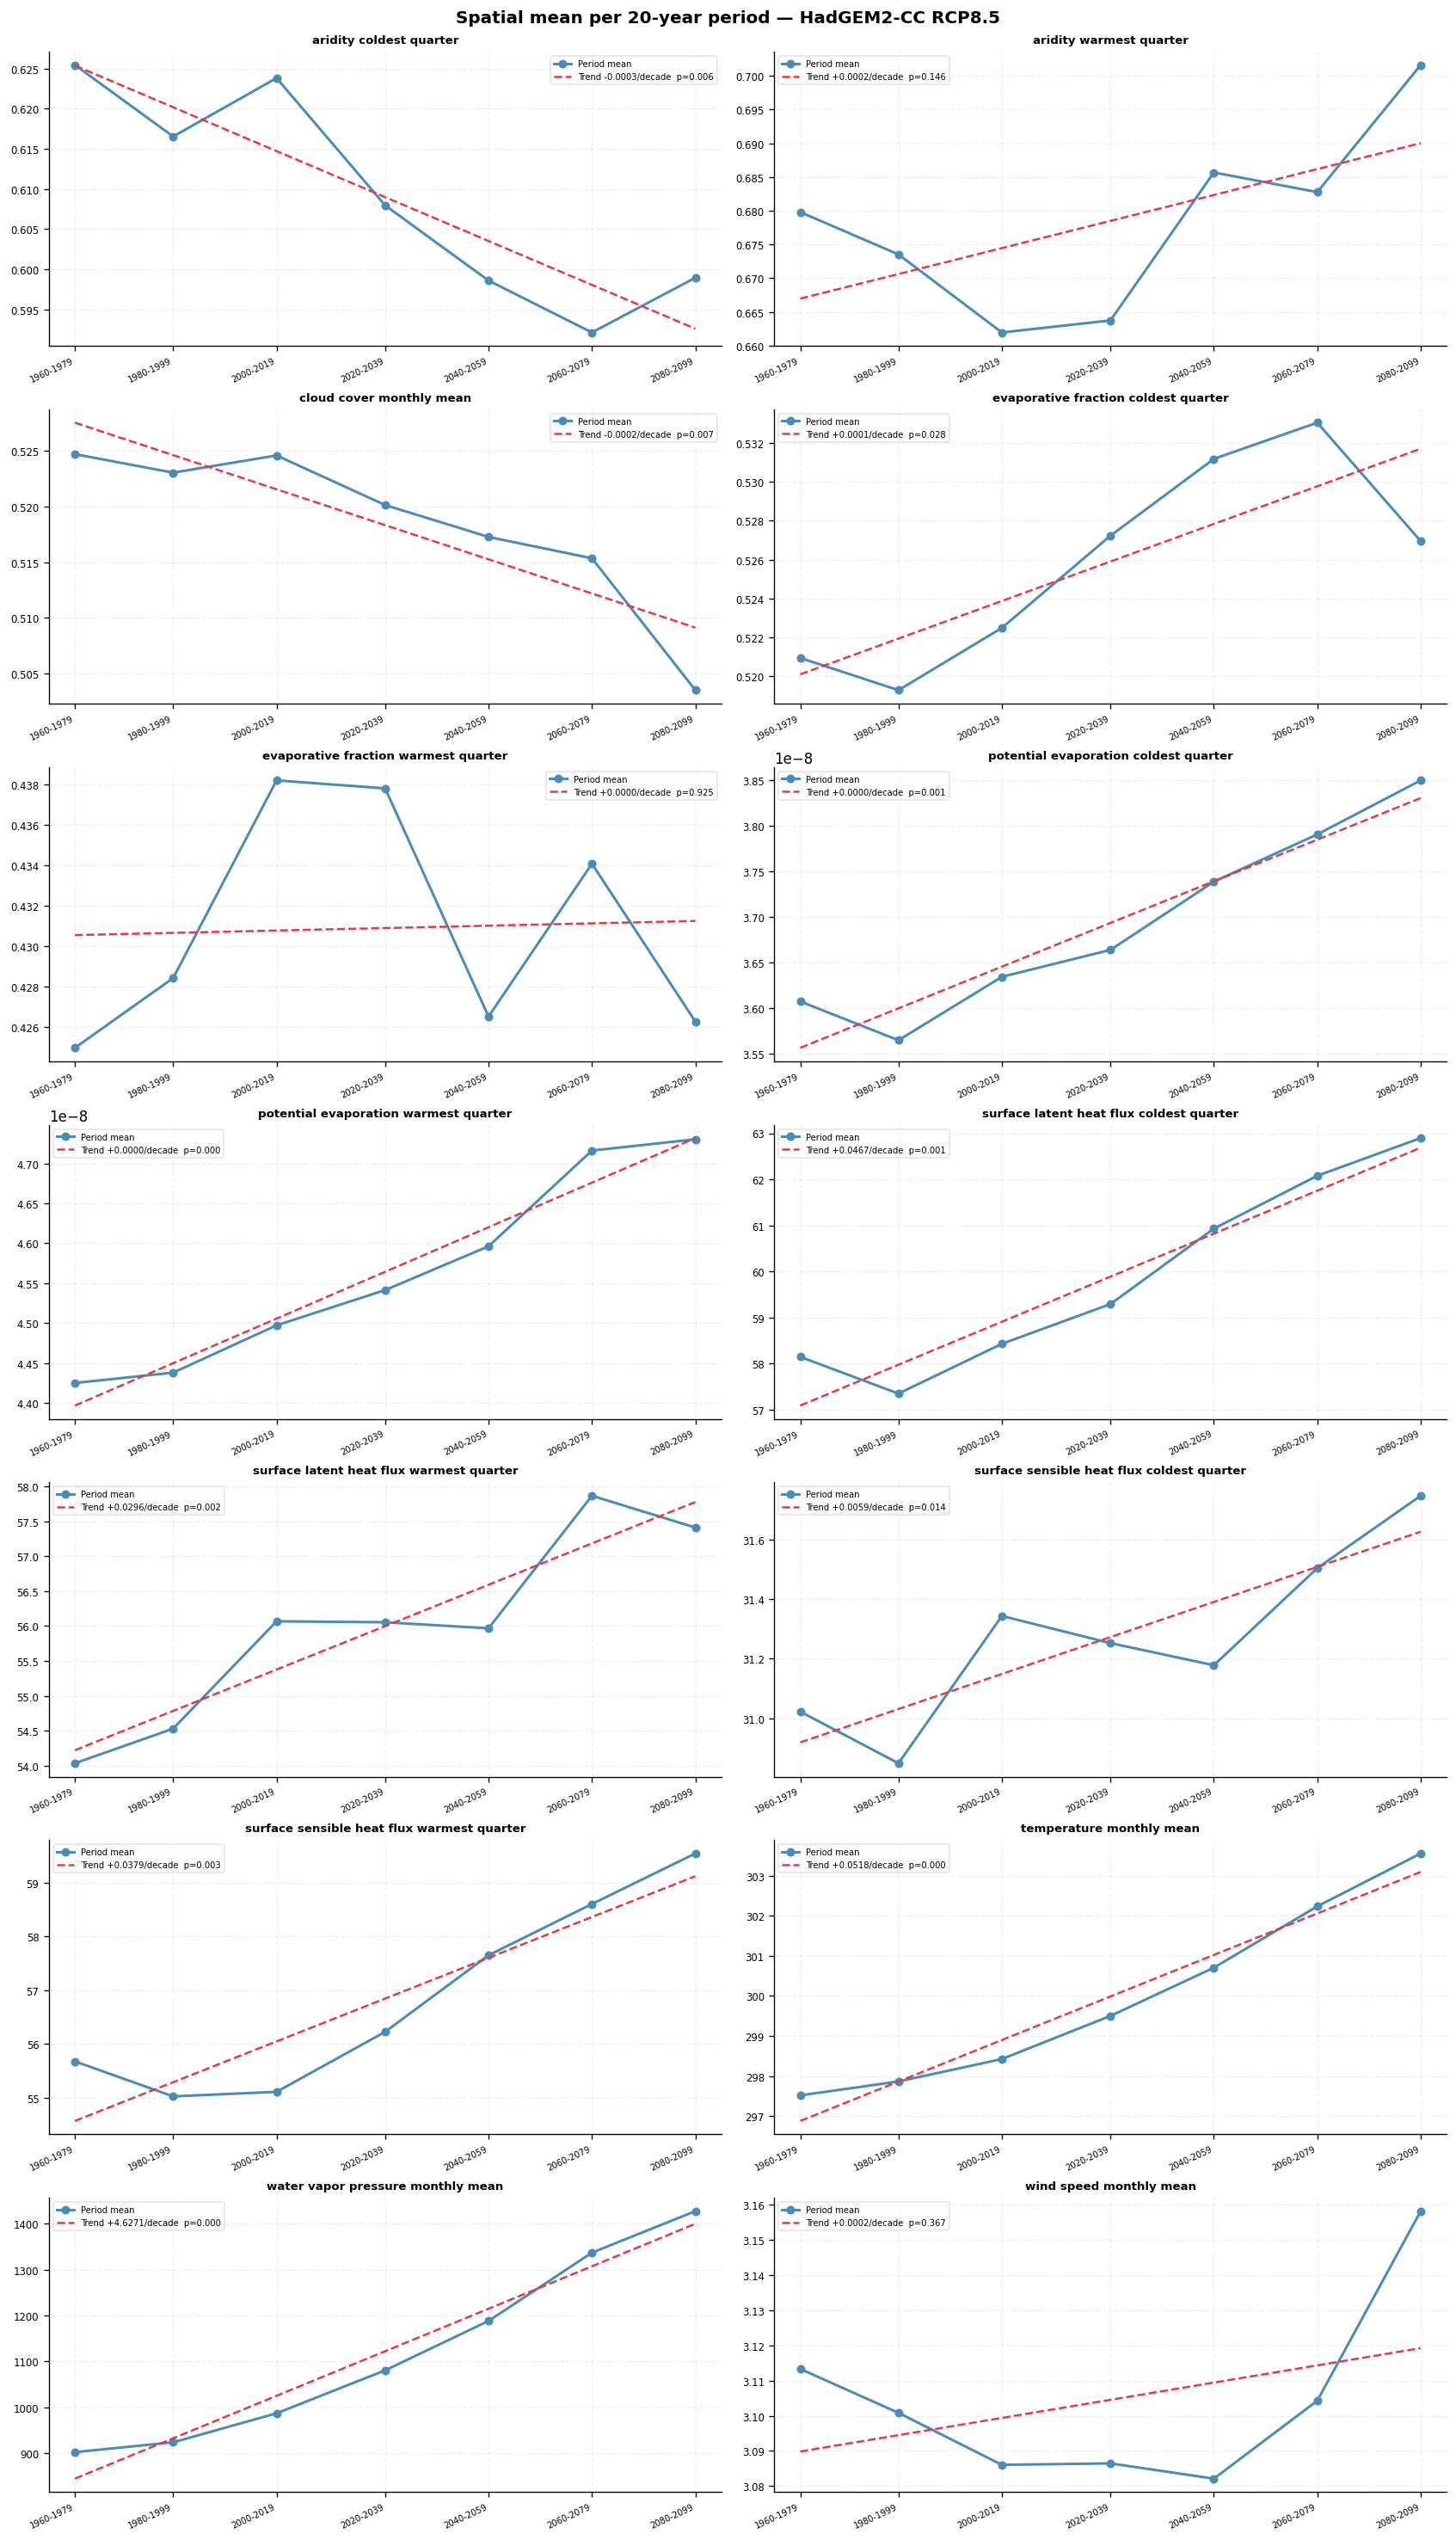

✓ Done


In [28]:
# ── 5.2 · Temporal trends — 20-year period means (no Dask) ──────────────────

print(f"Computing spatial means per period...\n")

nc_files_t = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc")))
nc_files_t  = [f for f in nc_files_t if "Copie" not in os.path.basename(f)]

var_series = {}   # {var_name: (period_years_arr, means_arr)}

for nc_file in nc_files_t:
    var_name = os.path.basename(nc_file).split("_hadgem2")[0]
    try:
        ds = xr.open_dataset(nc_file, engine="netcdf4")
    except Exception as e:
        print(f"  ⚠️  {var_name}: {e}"); continue

    lat_name = next((c for c in ("lat","latitude")  if c in ds.coords), None)
    lon_name = next((c for c in ("lon","longitude") if c in ds.coords), None)
    if "time" not in ds.dims:
        ds.close(); continue
    try:
        ds = ds.sel(time=slice(CONFIG["time_start"], CONFIG["time_end"]))
    except Exception:
        pass
    n_t = ds.sizes.get("time", 0)
    if n_t == 0:
        ds.close(); continue

    dvars = [v for v in ds.data_vars
             if lat_name and lon_name
             and lat_name in ds[v].dims and lon_name in ds[v].dims
             and "time" in ds[v].dims]
    if not dvars:
        ds.close(); continue

    dv     = dvars[0]
    t_vals = ds["time"].values
    means  = np.full(n_t, np.nan)
    for t in range(n_t):
        patch = ds[dv].isel(time=t).values.astype(float)
        patch = np.where(np.abs(patch) > 1e10, np.nan, patch)
        if not np.all(np.isnan(patch)):
            means[t] = np.nanmean(patch)
    ds.close()

    # Group into period means if monthly (84 steps → 7 period means)
    n_periods = len(PERIOD_YEARS)
    if n_t == n_periods:
        period_means = means
    elif n_t % n_periods == 0:
        n_per = n_t // n_periods
        period_means = np.array([means[i*n_per:(i+1)*n_per].mean() for i in range(n_periods)])
    else:
        period_means = means   # keep as-is

    var_series[var_name] = (np.array(PERIOD_YEARS[:len(period_means)]), period_means)
    print(f"  ✓ {var_name}  ({n_t} raw → {len(period_means)} period means)")

# ── Plot ──────────────────────────────────────────────────────────────────────
n_vars = len(var_series)
n_cols = 2
n_rows = (n_vars + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows*3.5), constrained_layout=True)
axes = axes.flatten()

for ax, (var_name, (periods, values)) in zip(axes, var_series.items()):
    valid = ~np.isnan(values)
    p_v   = periods[valid]; v_v = values[valid]
    if valid.sum() == 0:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center")
    else:
        ax.plot(p_v, v_v, lw=1.8, color="#4C8BB5", marker="o", markersize=5, label="Period mean")
        if valid.sum() >= 3:
            try:
                sl, ic, r, p, se = linregress(p_v, v_v)
                fit = sl*p_v + ic
                ax.plot(p_v, fit, lw=1.5, color="#E63946", ls="--",
                        label=f"Trend {sl:+.4f}/decade  p={p:.3f}")
            except Exception:
                pass
        # x-axis: period labels
        lbl_idx = [PERIOD_YEARS.index(yr) for yr in p_v if yr in PERIOD_YEARS]
        ax.set_xticks(p_v)
        ax.set_xticklabels([PERIOD_LABELS[i] for i in lbl_idx], fontsize=6, rotation=25, ha="right")
        ax.set_xlim(p_v[0]-5, p_v[-1]+5)
        ax.legend(fontsize=6, framealpha=0.5)
    ax.set_title(var_name.replace("-"," ").replace("_"," "), fontsize=8, fontweight="bold")
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(True, alpha=0.2, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)

for ax in axes[n_vars:]:
    ax.set_visible(False)

fig.suptitle("Spatial mean per 20-year period — HadGEM2-CC RCP8.5",
             fontsize=12, fontweight="bold")
plt.show()
print("✓ Done")

Monthly files (4):
  cloud-cover_monthly-mean_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc
  temperature_monthly-mean_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc
  water-vapor-pressure_monthly-mean_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc
  wind-speed_monthly-mean_hadgem2-cc_rcp85_r1i1p1_1960-2099-mean_v1.0.nc
  ✓ cloud-cover_monthly-mean  shape=(7, 12)
  ✓ temperature_monthly-mean  shape=(7, 12)
  ✓ water-vapor-pressure_monthly-mean  shape=(7, 12)
  ✓ wind-speed_monthly-mean  shape=(7, 12)

✅ 4 monthly variables ready



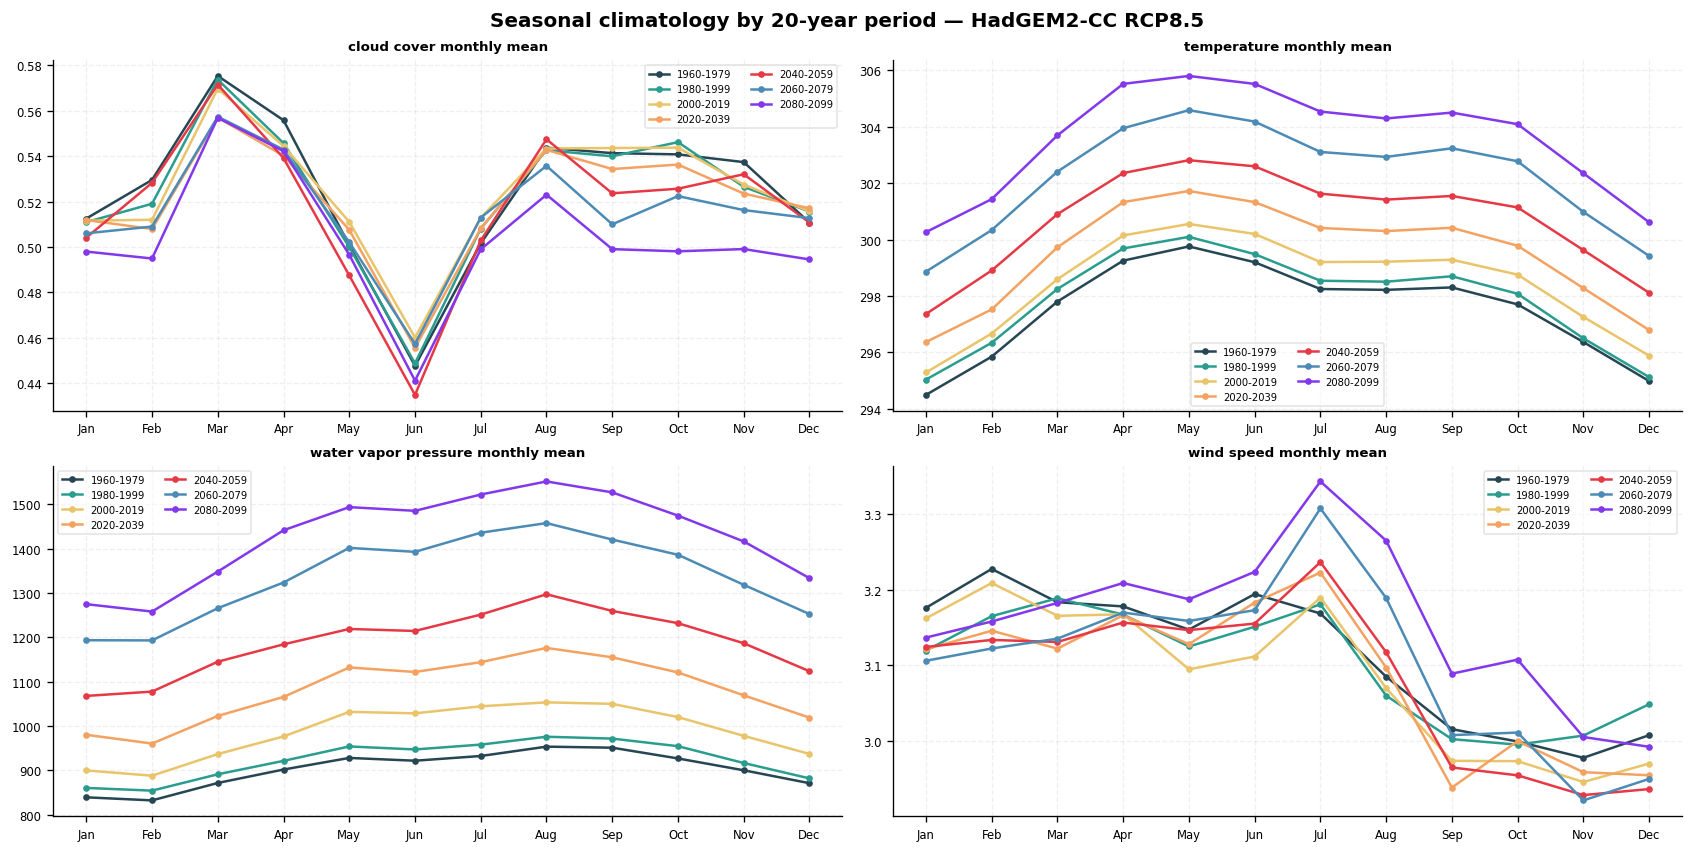

✓ Done


In [29]:
# ── 5.3 · Seasonal climatology — monthly variables only (no Dask) ───────────
# Monthly files have 84 steps (12 months × 7 periods).
# Each subplot shows one line per period coloured by era.

MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

nc_files_c = [
    f for f in sorted(glob.glob(os.path.join(DATA_DIR, "*.nc")))
    if "monthly" in os.path.basename(f) and "Copie" not in os.path.basename(f)
]
print(f"Monthly files ({len(nc_files_c)}):")
for f in nc_files_c:
    print(f"  {os.path.basename(f)}")

clim_data = {}   # {var_name: ndarray (n_periods, 12)}

for nc_file in nc_files_c:
    var_name = os.path.basename(nc_file).split("_hadgem2")[0]
    try:
        ds = xr.open_dataset(nc_file, engine="netcdf4")
    except Exception as e:
        print(f"  ⚠️  {var_name}: {e}"); continue

    lat_name = next((c for c in ("lat","latitude")  if c in ds.coords), None)
    lon_name = next((c for c in ("lon","longitude") if c in ds.coords), None)
    try:
        ds = ds.sel(time=slice(CONFIG["time_start"], CONFIG["time_end"]))
    except Exception:
        pass
    n_t = ds.sizes.get("time", 0)
    if n_t == 0 or n_t % 12 != 0:
        print(f"  ⚠️  {var_name}: n_t={n_t} not divisible by 12 — skipping")
        ds.close(); continue

    dvars = [v for v in ds.data_vars
             if lat_name and lon_name
             and lat_name in ds[v].dims and lon_name in ds[v].dims
             and "time" in ds[v].dims]
    if not dvars:
        ds.close(); continue

    dv         = dvars[0]
    n_periods  = n_t // 12
    pclim      = np.full((n_periods, 12), np.nan)
    for p in range(n_periods):
        for m in range(12):
            patch = ds[dv].isel(time=p*12+m).values.astype(float)
            patch = np.where(np.abs(patch) > 1e10, np.nan, patch)
            if not np.all(np.isnan(patch)):
                pclim[p, m] = np.nanmean(patch)
    ds.close()
    clim_data[var_name] = pclim
    print(f"  ✓ {var_name}  shape={pclim.shape}")

print(f"\n✅ {len(clim_data)} monthly variables ready\n")

n_vars  = len(clim_data)
n_cols  = 2
n_rows  = (n_vars+1)//n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows*3.5), constrained_layout=True)
axes = axes.flatten()

period_colors = ["#264653","#2A9D8F","#E9C46A","#F4A261","#E63946","#4C8BB5","#8338EC"]

for ax, (var_name, pclim) in zip(axes, clim_data.items()):
    n_p = pclim.shape[0]
    for p in range(n_p):
        label = PERIOD_LABELS[p] if p < len(PERIOD_LABELS) else str(PERIOD_YEARS[p])
        ax.plot(range(1,13), pclim[p], lw=1.5, marker="o", markersize=3,
                color=period_colors[p % len(period_colors)], label=label)
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(MONTHS, fontsize=7)
    ax.set_xlim(0.5, 12.5)
    ax.set_title(var_name.replace("-"," ").replace("_"," "), fontsize=8, fontweight="bold")
    ax.tick_params(axis="y", labelsize=7)
    ax.legend(fontsize=6, framealpha=0.5, ncol=2)
    ax.grid(True, alpha=0.2, linestyle="--")
    ax.spines[["top","right"]].set_visible(False)

for ax in axes[n_vars:]:
    ax.set_visible(False)

fig.suptitle("Seasonal climatology by 20-year period — HadGEM2-CC RCP8.5",
             fontsize=12, fontweight="bold")
plt.show()
print("✓ Done")

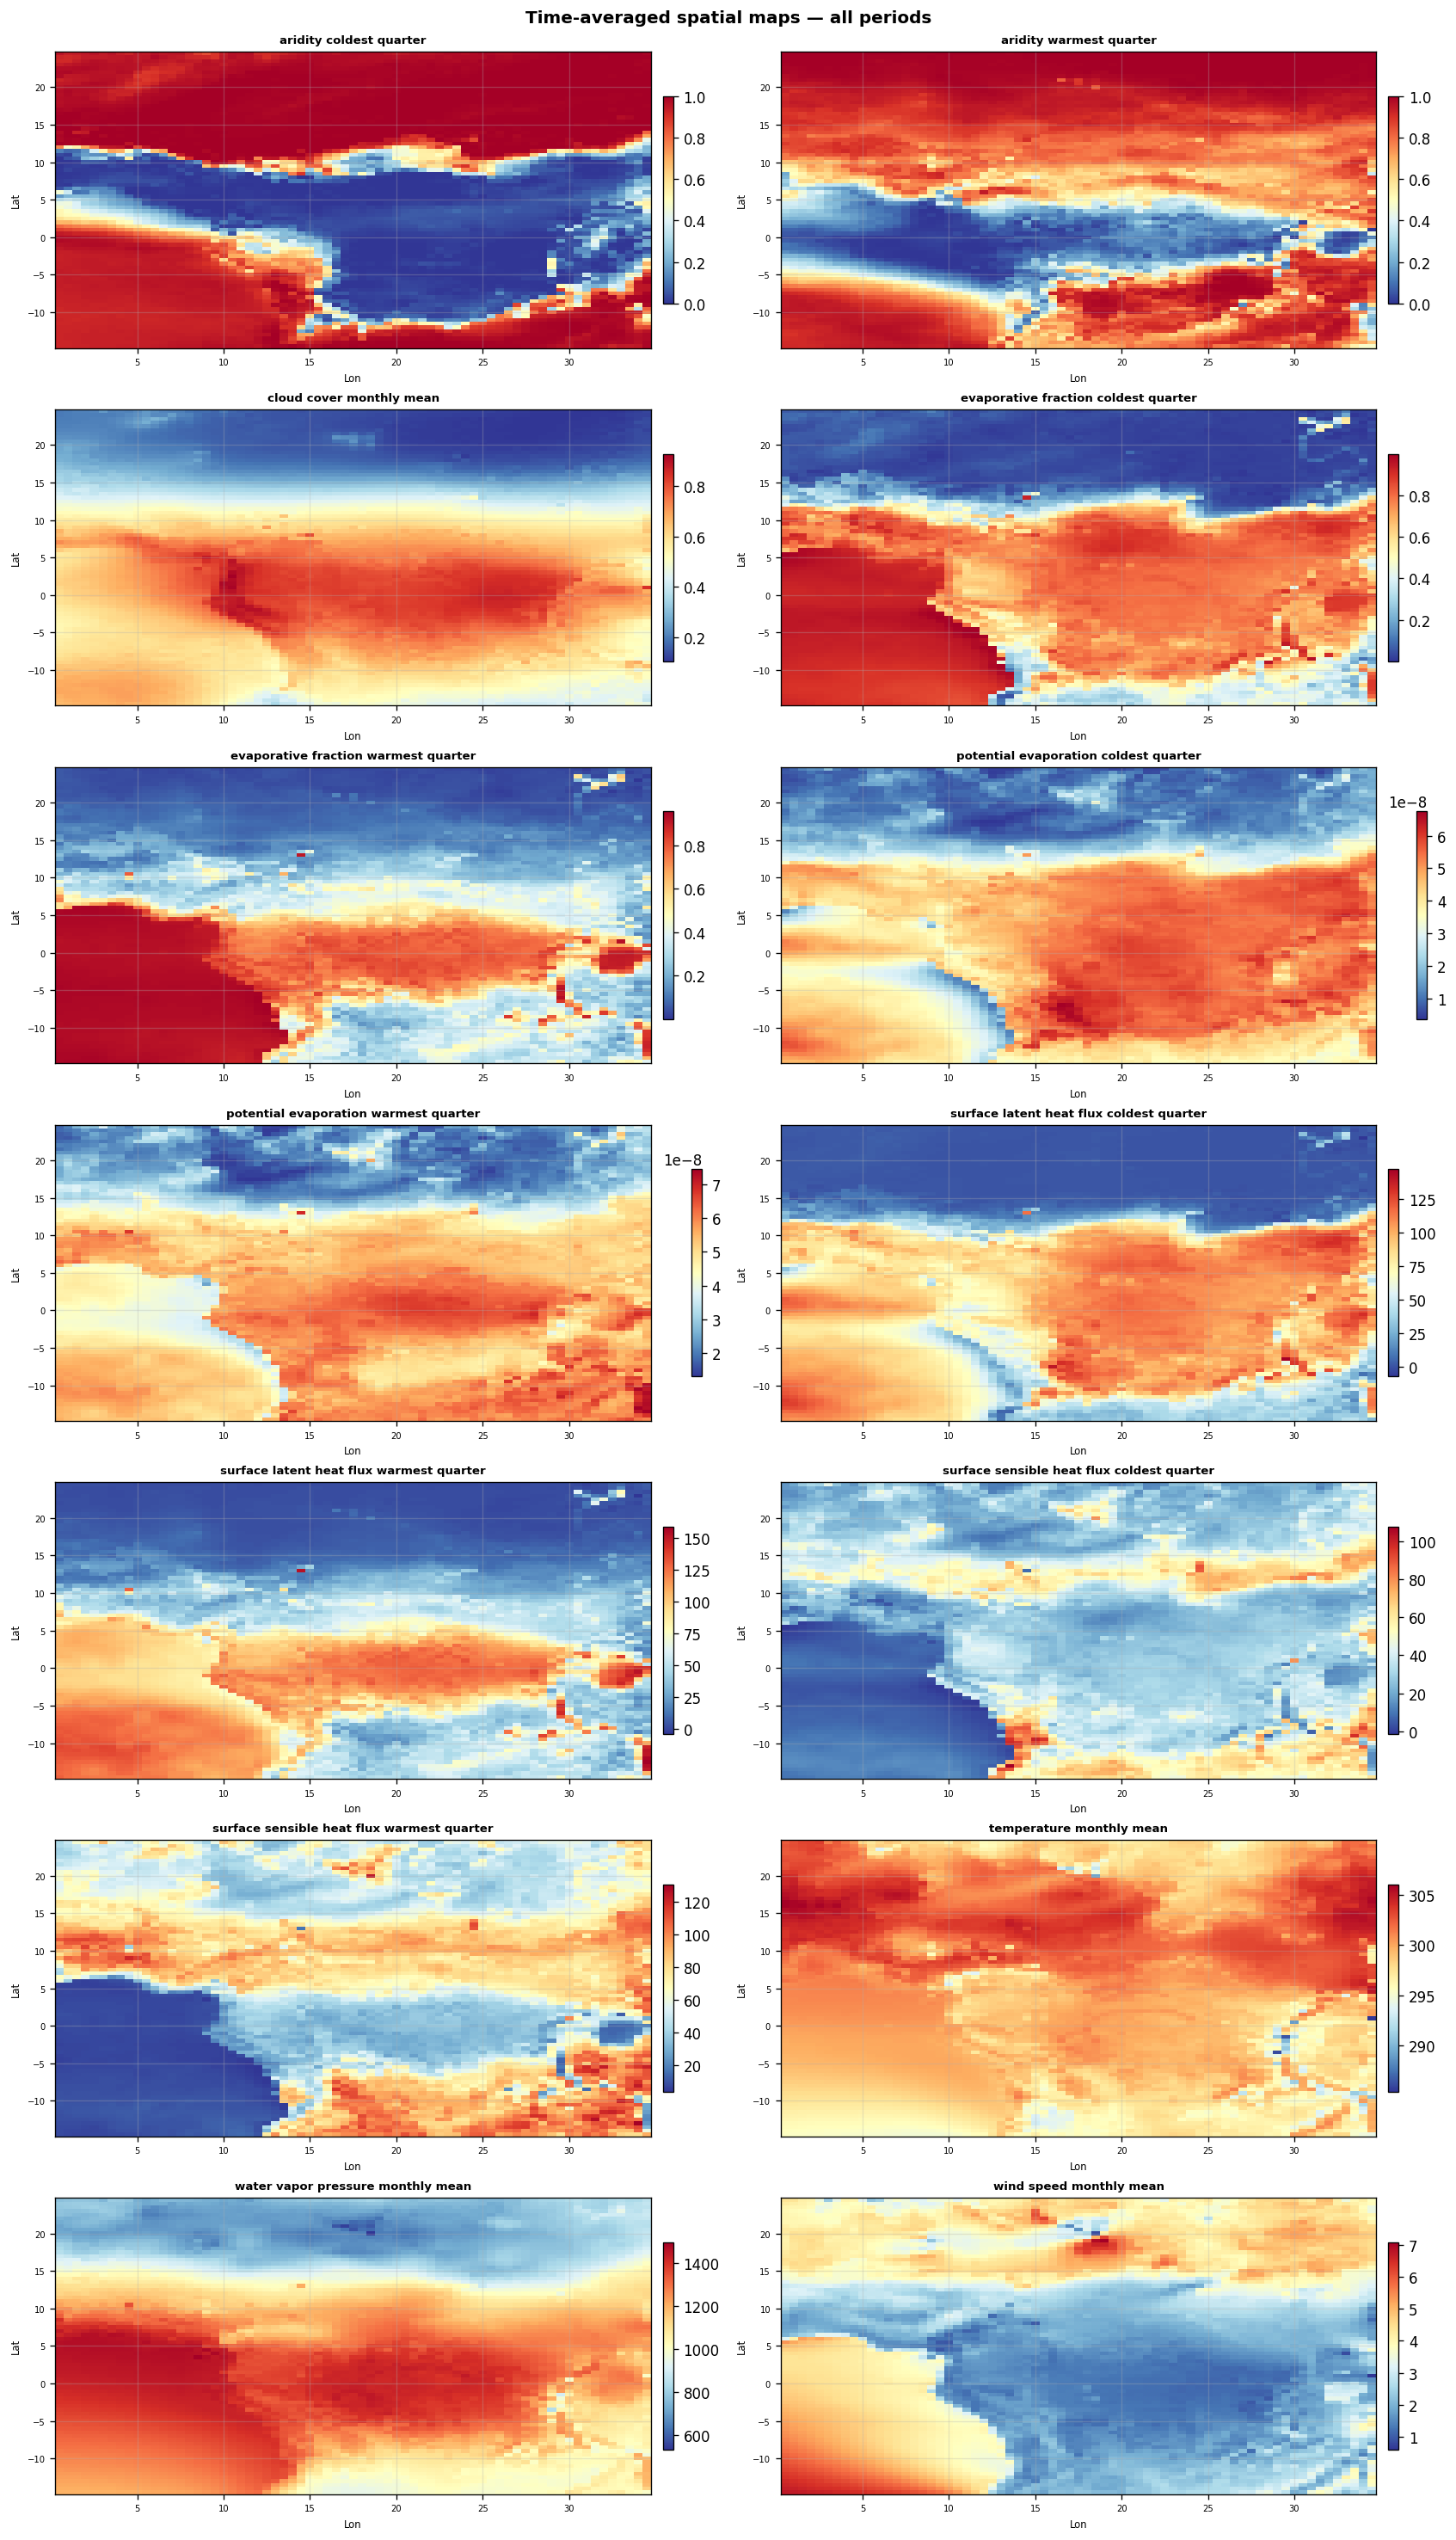

In [30]:
# ── 5.4 · Spatial mean maps ──────────────────────────────────────────────────
# Time-average of each regridded variable across all periods.

if "ds_regrid" not in globals():
    print("⚠️  ds_regrid not available. Run Section 6.4 (Regrid) first.")
else:
    plot_vars = [v for v in ds_regrid.data_vars if "lat" in ds_regrid[v].dims]
    n_pv = len(plot_vars)
    n_cols = 2; n_rows = (n_pv+1)//n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows*3.5), constrained_layout=True)
    axes = axes.flatten()

    for ax, var in zip(axes, plot_vars):
        da   = ds_regrid[var]
        tmap = da.mean(dim="time").values if "time" in da.dims else da.values
        tmap = np.where(np.abs(tmap) > 1e10, np.nan, tmap)
        im   = ax.pcolormesh(ds_regrid.lon.values, ds_regrid.lat.values, tmap,
                             cmap="RdYlBu_r", shading="auto")
        plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
        ax.set_title(var.replace("-"," ").replace("_"," "), fontsize=8, fontweight="bold")
        ax.set_xlabel("Lon", fontsize=7); ax.set_ylabel("Lat", fontsize=7)
        ax.tick_params(labelsize=6)

    for ax in axes[n_pv:]:
        ax.set_visible(False)

    fig.suptitle("Time-averaged spatial maps — all periods", fontsize=12, fontweight="bold")
    plt.show()


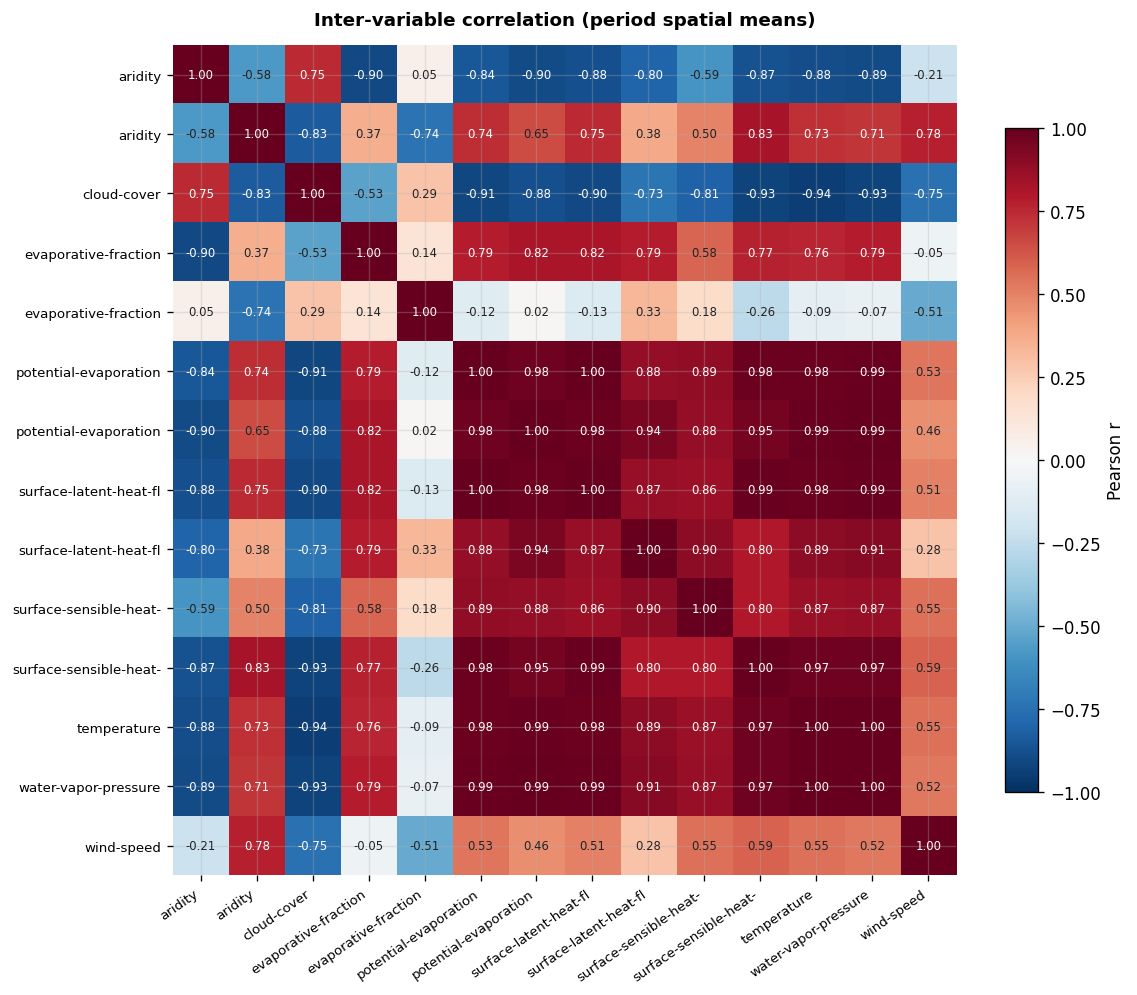


Strong correlations (|r| > 0.85, non-diagonal):
  aridity  ↔  evaporative-fraction  :  r = -0.900
  aridity  ↔  potential-evaporation  :  r = -0.896
  aridity  ↔  surface-latent-heat-fl  :  r = -0.877
  aridity  ↔  surface-sensible-heat-  :  r = -0.873
  aridity  ↔  temperature  :  r = -0.885
  aridity  ↔  water-vapor-pressure  :  r = -0.893
  cloud-cover  ↔  potential-evaporation  :  r = -0.912
  cloud-cover  ↔  potential-evaporation  :  r = -0.881
  cloud-cover  ↔  surface-latent-heat-fl  :  r = -0.901
  cloud-cover  ↔  surface-sensible-heat-  :  r = -0.926
  cloud-cover  ↔  temperature  :  r = -0.941
  cloud-cover  ↔  water-vapor-pressure  :  r = -0.925
  potential-evaporation  ↔  potential-evaporation  :  r = 0.976
  potential-evaporation  ↔  surface-latent-heat-fl  :  r = 0.997
  potential-evaporation  ↔  surface-latent-heat-fl  :  r = 0.876
  potential-evaporation  ↔  surface-sensible-heat-  :  r = 0.889
  potential-evaporation  ↔  surface-sensible-heat-  :  r = 0.979
  potentia

In [31]:
# ── 5.5 · Inter-variable correlation (period means) ─────────────────────────
# Uses the already-computed stats_df (spatial mean per period).
# Builds a correlation matrix across variables.

if "var_series" not in globals():
    print("⚠️  Run Section 5.2 (Temporal trends) first to populate var_series.")
else:
    # Build DataFrame: rows = periods, cols = variables
    max_len = max(len(v[1]) for v in var_series.values())
    ts_dict = {}
    for vn, (periods, vals) in var_series.items():
        padded = np.full(max_len, np.nan)
        padded[:len(vals)] = vals
        ts_dict[vn] = padded

    corr_df     = pd.DataFrame(ts_dict)
    corr_df.columns = [c.split("_")[0][:22] for c in corr_df.columns]
    corr_matrix = corr_df.corr()

    fig, ax = plt.subplots(figsize=(max(8, len(corr_matrix)*0.7),
                                   max(6, len(corr_matrix)*0.6)))
    im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            val = corr_matrix.values[i,j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if abs(val)>0.7 else "#222")
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=35, ha="right", fontsize=8)
    ax.set_yticks(range(len(corr_matrix.index)))
    ax.set_yticklabels(corr_matrix.index, fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
    ax.set_title("Inter-variable correlation (period spatial means)",
                 fontsize=11, fontweight="bold", pad=12)
    ax.spines[["top","right","left","bottom"]].set_visible(False)
    fig.tight_layout(); plt.show()

    print("\nStrong correlations (|r| > 0.85, non-diagonal):")
    found = False
    for i, row in enumerate(corr_matrix.columns):
        for j, col in enumerate(corr_matrix.columns):
            if i >= j: continue
            r = corr_matrix.values[i, j]
            if abs(r) > 0.85:
                print(f"  {row}  ↔  {col}  :  r = {r:.3f}"); found = True
    if not found:
        print("  None found.")


Interpretation: Trend tests, decadal shifts, extremes, and empirical orthogonal functions quantify climate evolution beyond simple visual inspection.

## Analysis (Section 8)

### Mann-Kendall trend test (Section 8-1)

In [32]:
# ── 8.1 · Mann-Kendall trend test (period spatial means) ─────────────────────
if not HAS_MK:
    print("⚠️  pymannkendall not installed. Run: pip install pymannkendall")
elif "var_series" not in globals():
    print("⚠️  Run Section 5.2 (Temporal trends) first.")
else:
    print("Mann-Kendall trend test (spatial mean, 7 decadal periods)")
    print("=" * 65)
    mk_rows = []
    for var_name, (periods, values) in var_series.items():
        ts = values[~np.isnan(values)]
        if len(ts) < CONFIG["mk_min_series_len"]:
            print(f"  SKIP  {var_name}  (only {len(ts)} points)")
            continue
        result = mk.original_test(ts)
        sig    = "✅ significant" if result.p < 0.05 else "—  not significant"
        mk_rows.append(dict(
            variable    = var_name,
            trend       = result.trend.upper(),
            p_value     = round(result.p, 4),
            tau         = round(result.Tau, 4),
            sen_slope   = round(result.slope, 6),
            significant = result.p < 0.05,
        ))
        print(f"  {sig:<20s}  {result.trend.upper():<12s}  p={result.p:.4f}  "
              f"slope={result.slope:.6f}/period  —  {var_name}")
    mk_df = pd.DataFrame(mk_rows)
    print(f"\n{mk_df.significant.sum() if not mk_df.empty else 0} / {len(mk_df)} "
          f"variables show significant trends (p < 0.05)")
# ── Mann-Kendall results table ────────────────────────────────────────────────
if "mk_df" in globals() and not mk_df.empty:
    sig     = mk_df[mk_df["significant"] == True].sort_values("p_value", ascending=True)
    not_sig = mk_df[mk_df["significant"] == False].sort_values("p_value", ascending=True)

    print("=== Significant trends (p < 0.05) ===")
    print(sig[["variable", "trend", "p_value", "tau"]].to_string(index=False))
    print(f"\n=== Not significant ({len(not_sig)} variables) ===")
    print(not_sig[["variable", "trend", "p_value", "tau"]].to_string(index=False))


Mann-Kendall trend test (spatial mean, 7 decadal periods)
  ✅ significant         DECREASING    p=0.0355  slope=-0.006107/period  —  aridity_coldest-quarter
  —  not significant    NO TREND      p=0.2296  slope=0.003635/period  —  aridity_warmest-quarter
  ✅ significant         DECREASING    p=0.0069  slope=-0.002393/period  —  cloud-cover_monthly-mean
  —  not significant    NO TREND      p=0.0715  slope=0.002427/period  —  evaporative-fraction_coldest-quarter
  —  not significant    NO TREND      p=1.0000  slope=-0.000125/period  —  evaporative-fraction_warmest-quarter
  ✅ significant         INCREASING    p=0.0069  slope=0.000000/period  —  potential-evaporation_coldest-quarter
  ✅ significant         INCREASING    p=0.0027  slope=0.000000/period  —  potential-evaporation_warmest-quarter
  ✅ significant         INCREASING    p=0.0069  slope=1.080823/period  —  surface-latent-heat-flux_coldest-quarter
  —  not significant    NO TREND      p=0.0715  slope=0.575826/period  —  surface-l

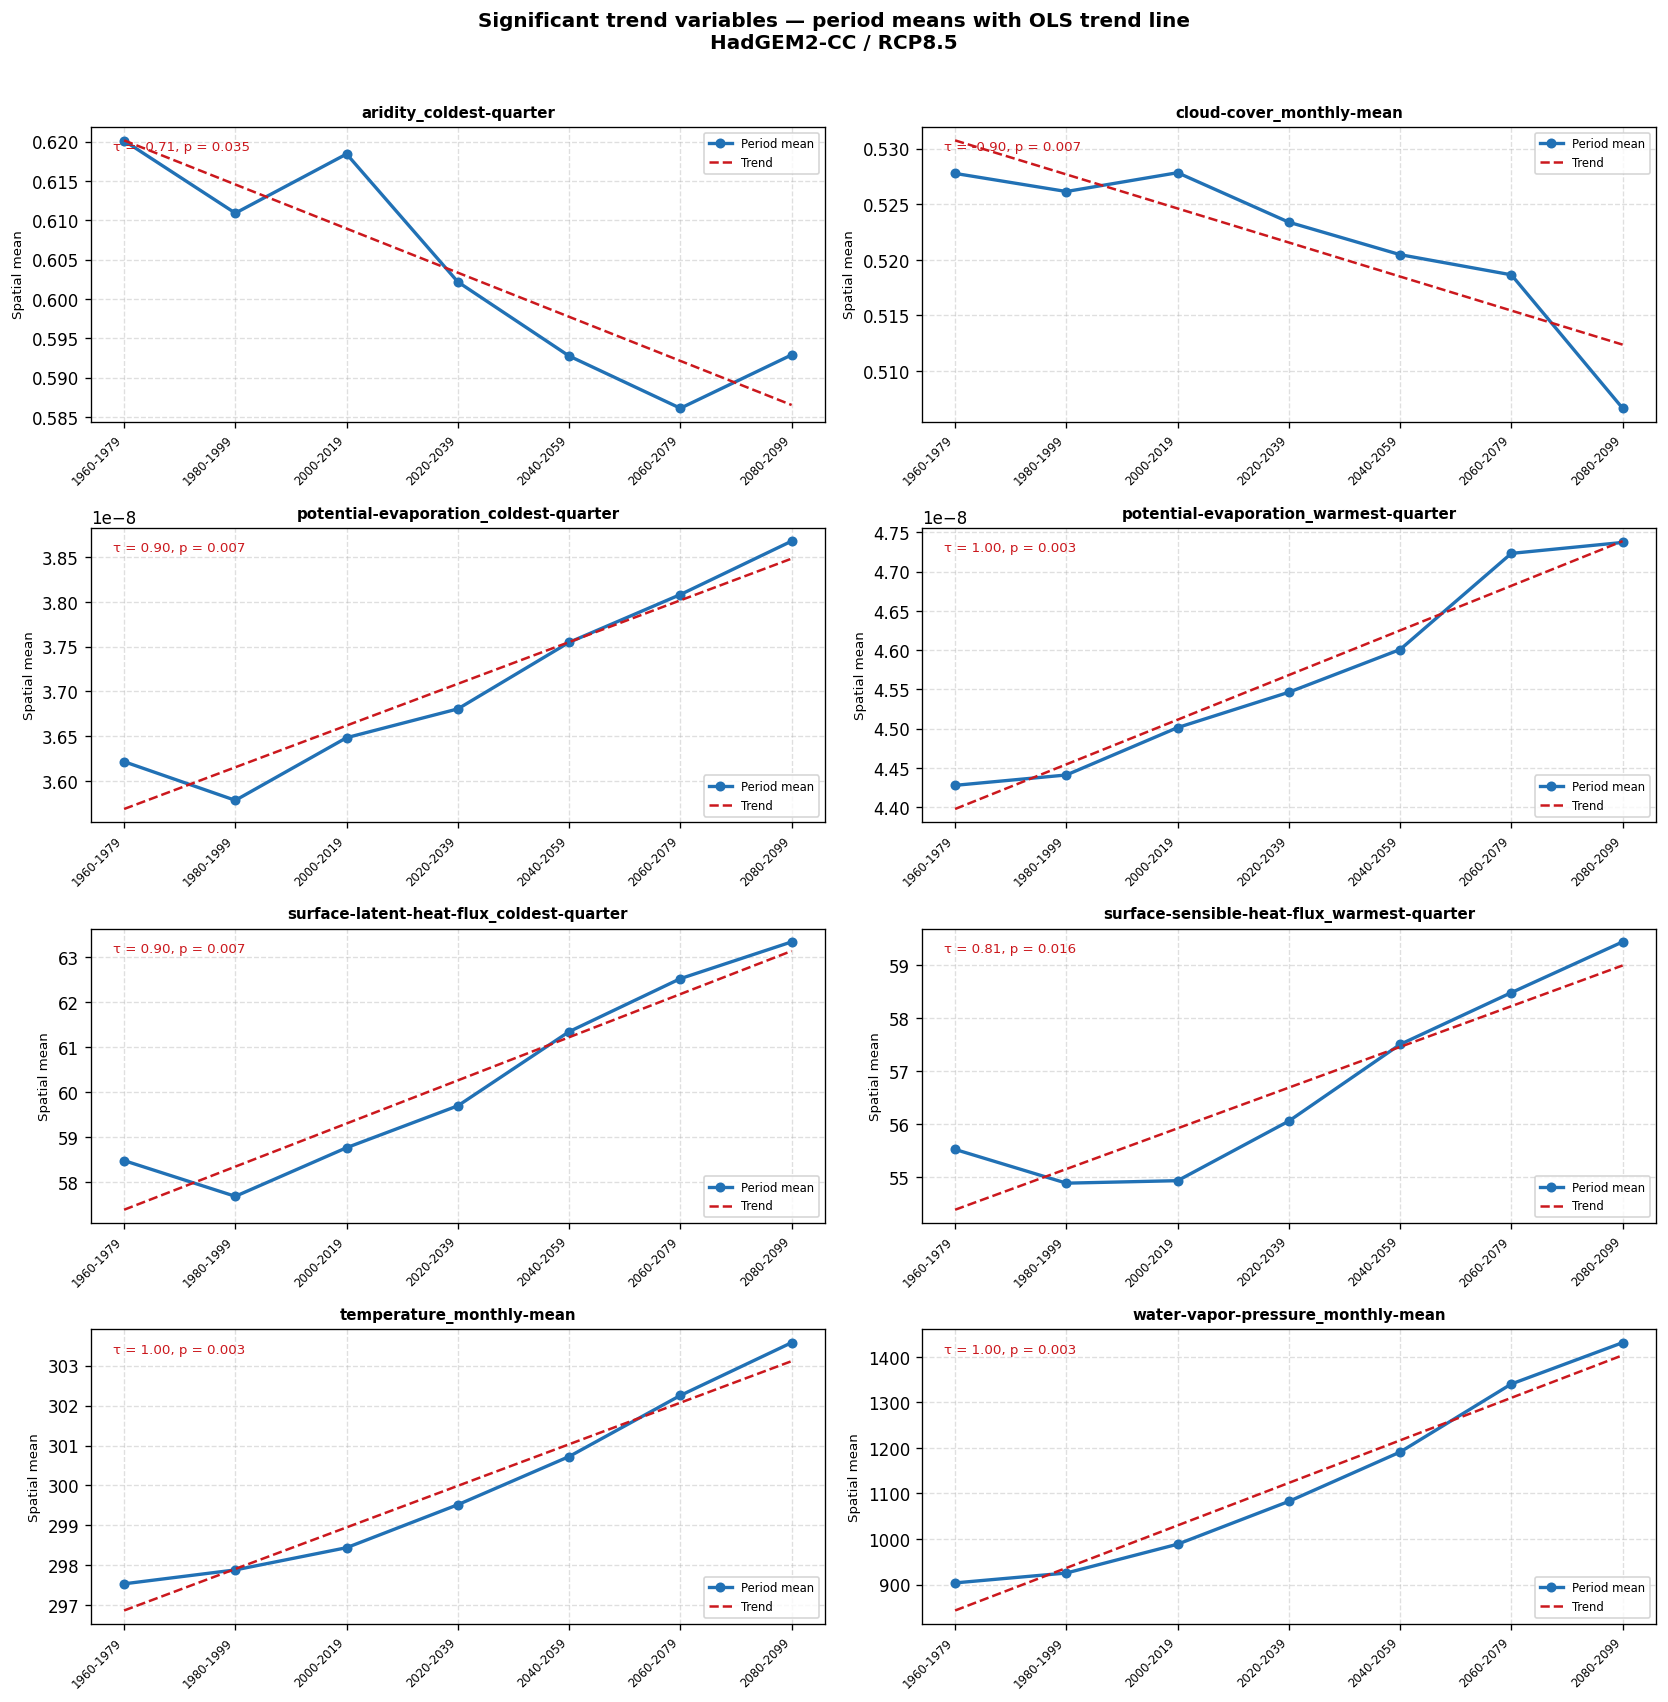

In [33]:
# ── Period-mean time series + MK trend line (significant variables only) ──────

if "mk_df" in globals() and not mk_df.empty:
    sig_vars = mk_df[mk_df["significant"] == True]["variable"].tolist()
else:
    sig_vars = list(ds_regrid.data_vars)

n_cols = 2
n_rows = (len(sig_vars) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

x = np.arange(len(PERIOD_LABELS))
n_periods   = len(PERIOD_LABELS)          # 7
steps_total = len(ds_regrid.time)         # 84  (or 7 for quarterly vars)
steps_per_period = steps_total // n_periods   # 12 for monthly, 1 for quarterly

for i, var in enumerate(sig_vars):
    ax = axes[i]
    try:
        spatial_dims = [d for d in ds_regrid[var].dims if d != "time"]
        raw = ds_regrid[var].mean(dim=spatial_dims).values   # shape (84,) or (7,)

        # collapse to one value per period
        if len(raw) == n_periods:
            y = raw
        else:
            y = raw[: n_periods * steps_per_period].reshape(n_periods, steps_per_period)
            y = np.nanmean(y, axis=1)                        # shape (7,)
    except Exception:
        continue

    ax.plot(x, y, "o-", color="#2171b5", linewidth=2, markersize=5, label="Period mean")

    mask = ~np.isnan(y)
    if mask.sum() >= 2:
        coeffs     = np.polyfit(x[mask], y[mask], 1)
        trend_line = np.polyval(coeffs, x)
        ax.plot(x, trend_line, "--", color="#cb181d", linewidth=1.5, label="Trend")

    if "mk_df" in globals() and not mk_df.empty:
        row = mk_df[mk_df["variable"] == var]
        if not row.empty:
            tau = row["tau"].values[0]
            p   = row["p_value"].values[0]
            ax.annotate(f"τ = {tau:.2f}, p = {p:.3f}",
                        xy=(0.03, 0.92), xycoords="axes fraction",
                        fontsize=8, color="#cb181d")

    ax.set_title(var, fontsize=9, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(PERIOD_LABELS, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Spatial mean", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(linestyle="--", alpha=0.4)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"Significant trend variables — period means with OLS trend line\n"
    f"{CONFIG['cmip5_model']} / {CONFIG['cmip5_scenario']}",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("outputs/timeseries_trend_lines.png", dpi=150, bbox_inches="tight")
plt.show()

### Boxplots (Section 8-2)

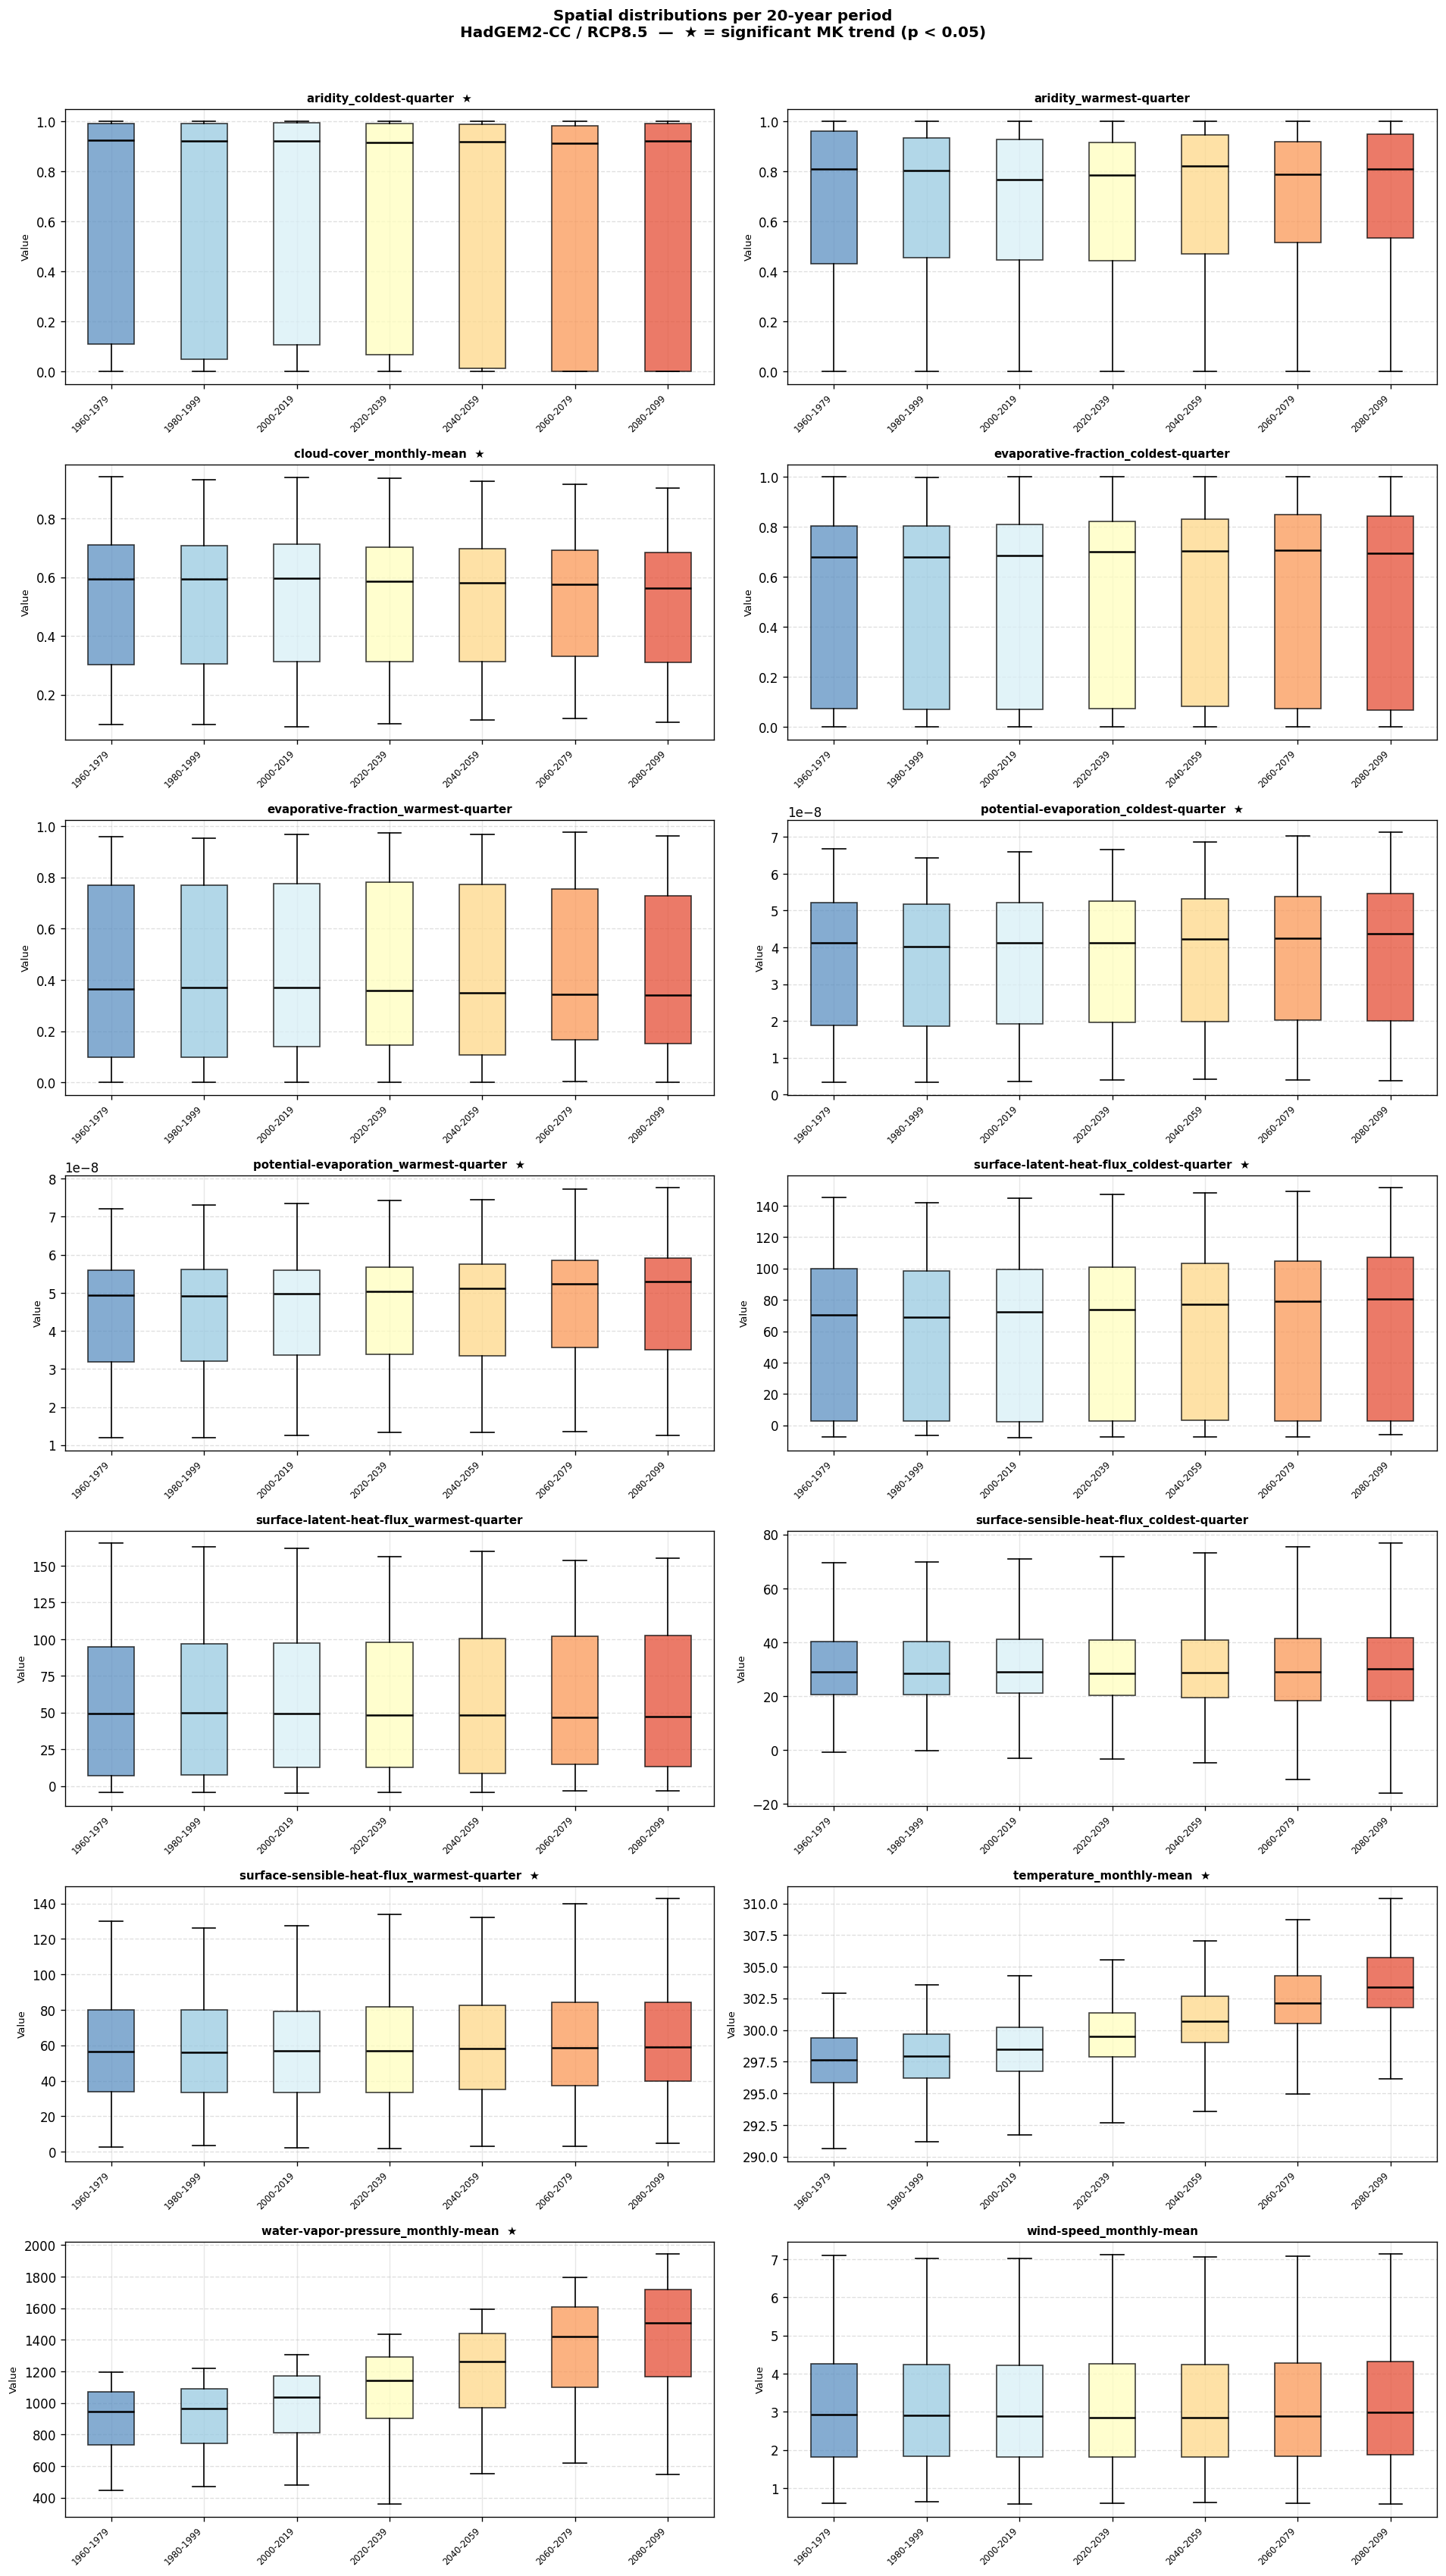

In [34]:
# ── Spatial distribution boxplots per variable across periods ─────────────────

n_periods        = len(PERIOD_LABELS)
steps_total      = len(ds_regrid.time)
steps_per_period = steps_total // n_periods   # 12 for monthly, 1 for quarterly

variables = list(ds_regrid.data_vars)
n_cols    = 2
n_rows    = (len(variables) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, var in enumerate(variables):
    ax = axes[i]
    data_per_period = []
    spatial_dims = [d for d in ds_regrid[var].dims if d != "time"]

    for p in range(n_periods):
        try:
            if steps_per_period == 1:
                # quarterly: one time step per period
                arr = ds_regrid[var].isel(time=p).values.flatten()
            else:
                # monthly: average the 12 steps that belong to this period
                t_start = p * steps_per_period
                t_end   = t_start + steps_per_period
                arr = (
                    ds_regrid[var]
                    .isel(time=slice(t_start, t_end))
                    .mean(dim="time")
                    .values
                    .flatten()
                )
            arr = arr[~np.isnan(arr)]
            data_per_period.append(arr)
        except Exception:
            data_per_period.append(np.array([np.nan]))

    bp = ax.boxplot(
        data_per_period,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.5),
    )

    colors = plt.cm.RdYlBu_r(np.linspace(0.15, 0.85, n_periods))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    is_sig = False
    if "mk_df" in globals() and not mk_df.empty:
        row = mk_df[mk_df["variable"] == var]
        if not row.empty:
            is_sig = bool(row["significant"].values[0])

    ax.set_title(f"{var}{'  ★' if is_sig else ''}", fontsize=9, fontweight="bold")
    ax.set_xticks(range(1, n_periods + 1))
    ax.set_xticklabels(PERIOD_LABELS, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Value", fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"Spatial distributions per 20-year period\n"
    f"{CONFIG['cmip5_model']} / {CONFIG['cmip5_scenario']}  —  ★ = significant MK trend (p < 0.05)",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("outputs/boxplots_spatial_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

  ✓ evaporative-fraction_coldest-quarter  slope range: [-0.0038, 0.0041]
  ✓ evaporative-fraction_warmest-quarter  slope range: [-0.0038, 0.0017]
  ✓ surface-latent-heat-flux_coldest-quarter  slope range: [-0.4343, 0.5501]


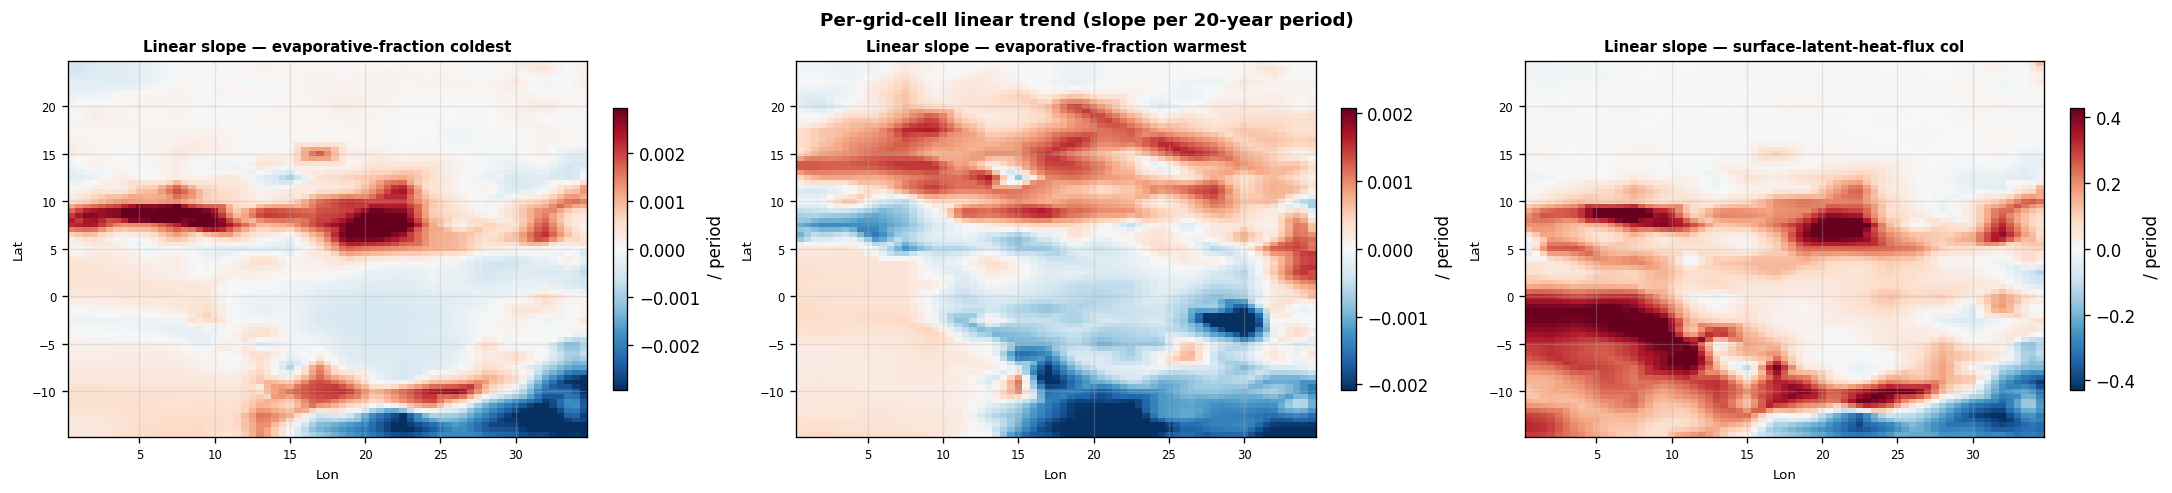

✓ Done


In [35]:
# ── 8-A · Per-grid-cell linear trend map (no Dask) ───────────────────────────
# Uses ds_regrid (already in memory as numpy arrays) — no compute() needed.

if "ds_regrid" not in globals():
    print("⚠️  Run Section 6.4 (Regrid) first to populate ds_regrid.")
else:
    _PRIO     = ["temperature", "latent", "evaporative"]
    GRID_VARS = [v for v in ds_regrid.data_vars
                 if any(k in v.lower() for k in _PRIO)
                 and "time" in ds_regrid[v].dims
                 and ds_regrid[v].sizes.get("time", 1) > 1][:3]

    if not GRID_VARS:
        GRID_VARS = [v for v in ds_regrid.data_vars
                     if "time" in ds_regrid[v].dims
                     and ds_regrid[v].sizes.get("time", 1) > 1][:2]

    if not GRID_VARS:
        print("⚠️  No 3D variables found in ds_regrid.")
    else:
        fig, axes = plt.subplots(1, len(GRID_VARS),
                                 figsize=(6*len(GRID_VARS), 4),
                                 constrained_layout=True)
        axes = [axes] if len(GRID_VARS) == 1 else list(axes)

        for ax, var in zip(axes, GRID_VARS):
            # ds_regrid is already pure numpy — no compute() needed
            arr  = ds_regrid[var].values   # (time, lat, lon), float32
            nt, nlat, nlon = arr.shape
            _x   = np.arange(nt, dtype=float)

            # Per-grid-cell linear slope
            flat = arr.reshape(nt, -1).astype(float)   # (time, space)
            slp  = np.full(flat.shape[1], np.nan)

            for j in range(flat.shape[1]):
                col   = flat[:, j]
                valid = ~np.isnan(col)
                if valid.sum() >= 3:   # need ≥3 points (7 periods max)
                    slp[j] = linregress(_x[valid], col[valid]).slope

            smap   = slp.reshape(nlat, nlon)
            lats_g = ds_regrid["lat"].values
            lons_g = ds_regrid["lon"].values
            vmax_g = np.nanpercentile(np.abs(smap), 98) or 1e-6

            im = ax.pcolormesh(lons_g, lats_g, smap,
                               cmap="RdBu_r", vmin=-vmax_g, vmax=vmax_g,
                               shading="auto")
            plt.colorbar(im, ax=ax, shrink=0.75,
                         label=f"{ds_regrid[var].attrs.get('units','')} / period")
            ax.set_title(f"Linear slope — {var.replace('_',' ')[:28]}",
                         fontsize=9, fontweight="bold")
            ax.set_xlabel("Lon", fontsize=8)
            ax.set_ylabel("Lat", fontsize=8)
            ax.tick_params(labelsize=7)
            print(f"  ✓ {var}  slope range: [{np.nanmin(smap):.4f}, {np.nanmax(smap):.4f}]")

        fig.suptitle("Per-grid-cell linear trend (slope per 20-year period)",
                     fontsize=11, fontweight="bold")
        plt.show()
        print("✓ Done")

### Decadal change summary (Section 8-3)

Period spatial means:
                                            1960-1979  1980-1999  2000-2019  2020-2039  2040-2059  2060-2079  2080-2099  Δ absolute    Δ %
aridity_coldest-quarter                        0.6254     0.6165     0.6238     0.6079     0.5986     0.5921     0.5989     -0.0265  -4.24
aridity_warmest-quarter                        0.6798     0.6735     0.6619     0.6637     0.6857     0.6828     0.7016      0.0218   3.21
cloud-cover_monthly-mean                       0.5247     0.5231     0.5246     0.5202     0.5173     0.5154     0.5035     -0.0212  -4.04
evaporative-fraction_coldest-quarter           0.5209     0.5193     0.5225     0.5272     0.5312     0.5331     0.5270      0.0061   1.17
evaporative-fraction_warmest-quarter           0.4250     0.4284     0.4382     0.4378     0.4265     0.4341     0.4263      0.0013   0.31
potential-evaporation_coldest-quarter          0.0000     0.0000     0.0000     0.0000     0.0000     0.0000     0.0000      0.0000    NaN
poten

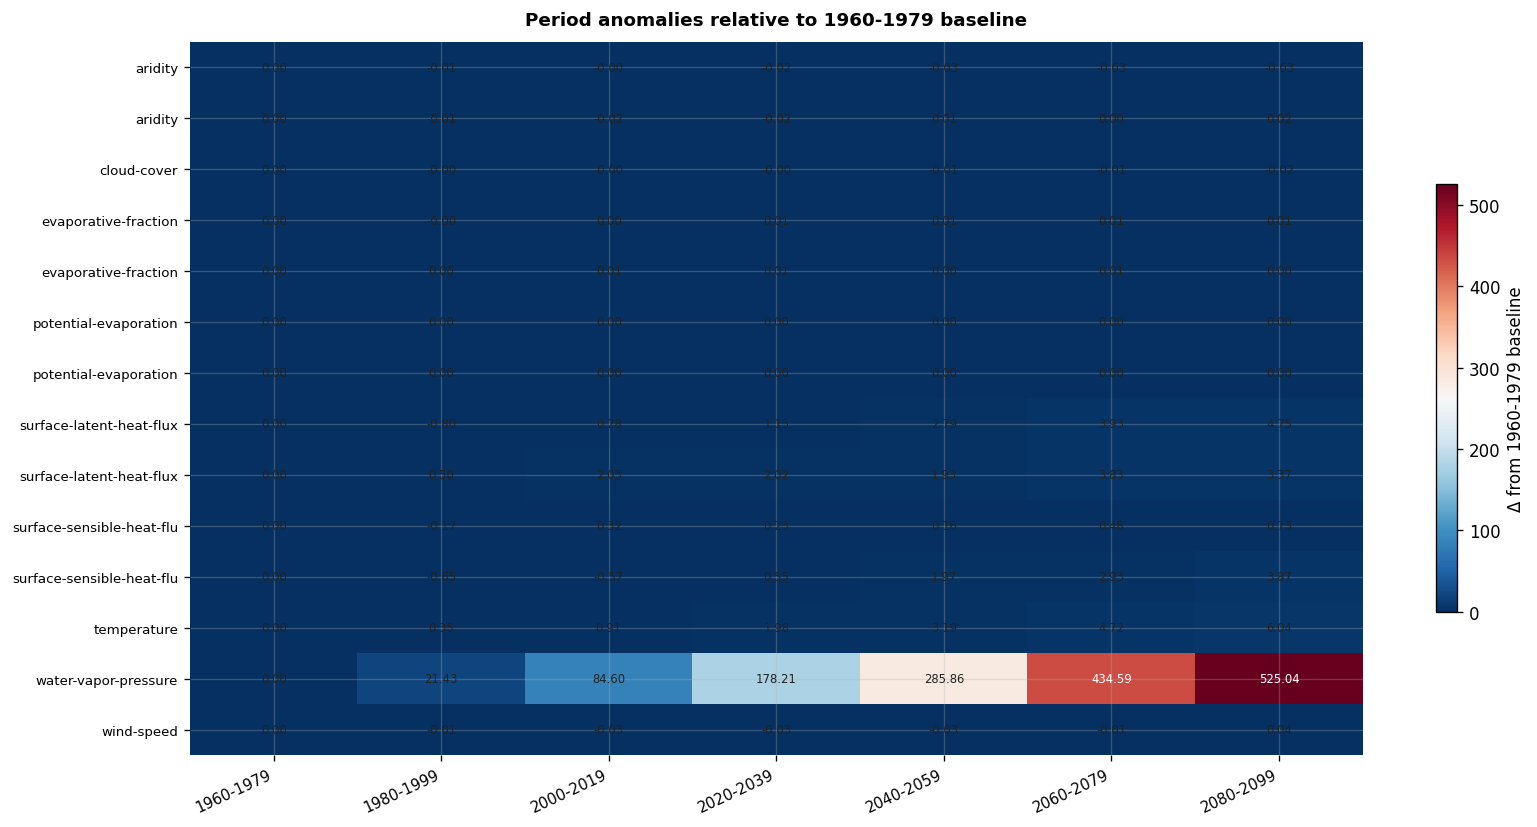

In [36]:
# ── 8.2 · Period-to-period change summary ────────────────────────────────────
# Uses var_series (already computed period spatial means) — no Dask needed.

if "var_series" not in globals():
    print("⚠️  Run Section 5.2 (Temporal trends) first.")
else:
    period_data = {}
    for var_name, (periods, values) in var_series.items():
        period_data[var_name] = {
            PERIOD_LABELS[i]: round(float(values[i]),4)
            if i < len(values) and not np.isnan(values[i]) else np.nan
            for i in range(len(PERIOD_LABELS))
        }

    decade_df = pd.DataFrame(period_data).T
    baseline  = decade_df.get("1960-1979", decade_df.iloc[:, 0])
    last_col  = decade_df.columns[-1]
    decade_df["Δ absolute"] = (decade_df[last_col] - baseline).round(4)
    decade_df["Δ %"]        = ((decade_df[last_col] - baseline) / baseline.abs() * 100).round(2)

    print("Period spatial means:")
    print(decade_df.to_string())

    # Heatmap of period anomalies
    delta_df  = decade_df[PERIOD_LABELS].subtract(baseline, axis=0)
    short_names = [v.split("_")[0][:25] for v in delta_df.index]
    fig, ax   = plt.subplots(figsize=(14, max(5, len(delta_df)*0.5)))
    im = ax.imshow(delta_df.values, aspect="auto", cmap="RdBu_r")
    ax.set_xticks(range(len(PERIOD_LABELS)))
    ax.set_xticklabels(PERIOD_LABELS, fontsize=9, rotation=25, ha="right")
    ax.set_yticks(range(len(short_names)))
    ax.set_yticklabels(short_names, fontsize=8)
    for i in range(len(delta_df)):
        for j in range(len(PERIOD_LABELS)):
            val = delta_df.values[i,j]
            if np.isnan(val): continue
            color = "white" if abs(val) > 0.7*np.nanmax(abs(delta_df.values)) else "#222"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)
    plt.colorbar(im, ax=ax, shrink=0.6, label="Δ from 1960-1979 baseline")
    ax.set_title("Period anomalies relative to 1960-1979 baseline",
                 fontsize=11, fontweight="bold", pad=10)
    ax.spines[["top","right","left","bottom"]].set_visible(False)
    fig.tight_layout(); plt.show()


### Extreme event analysis (Section 8-4)

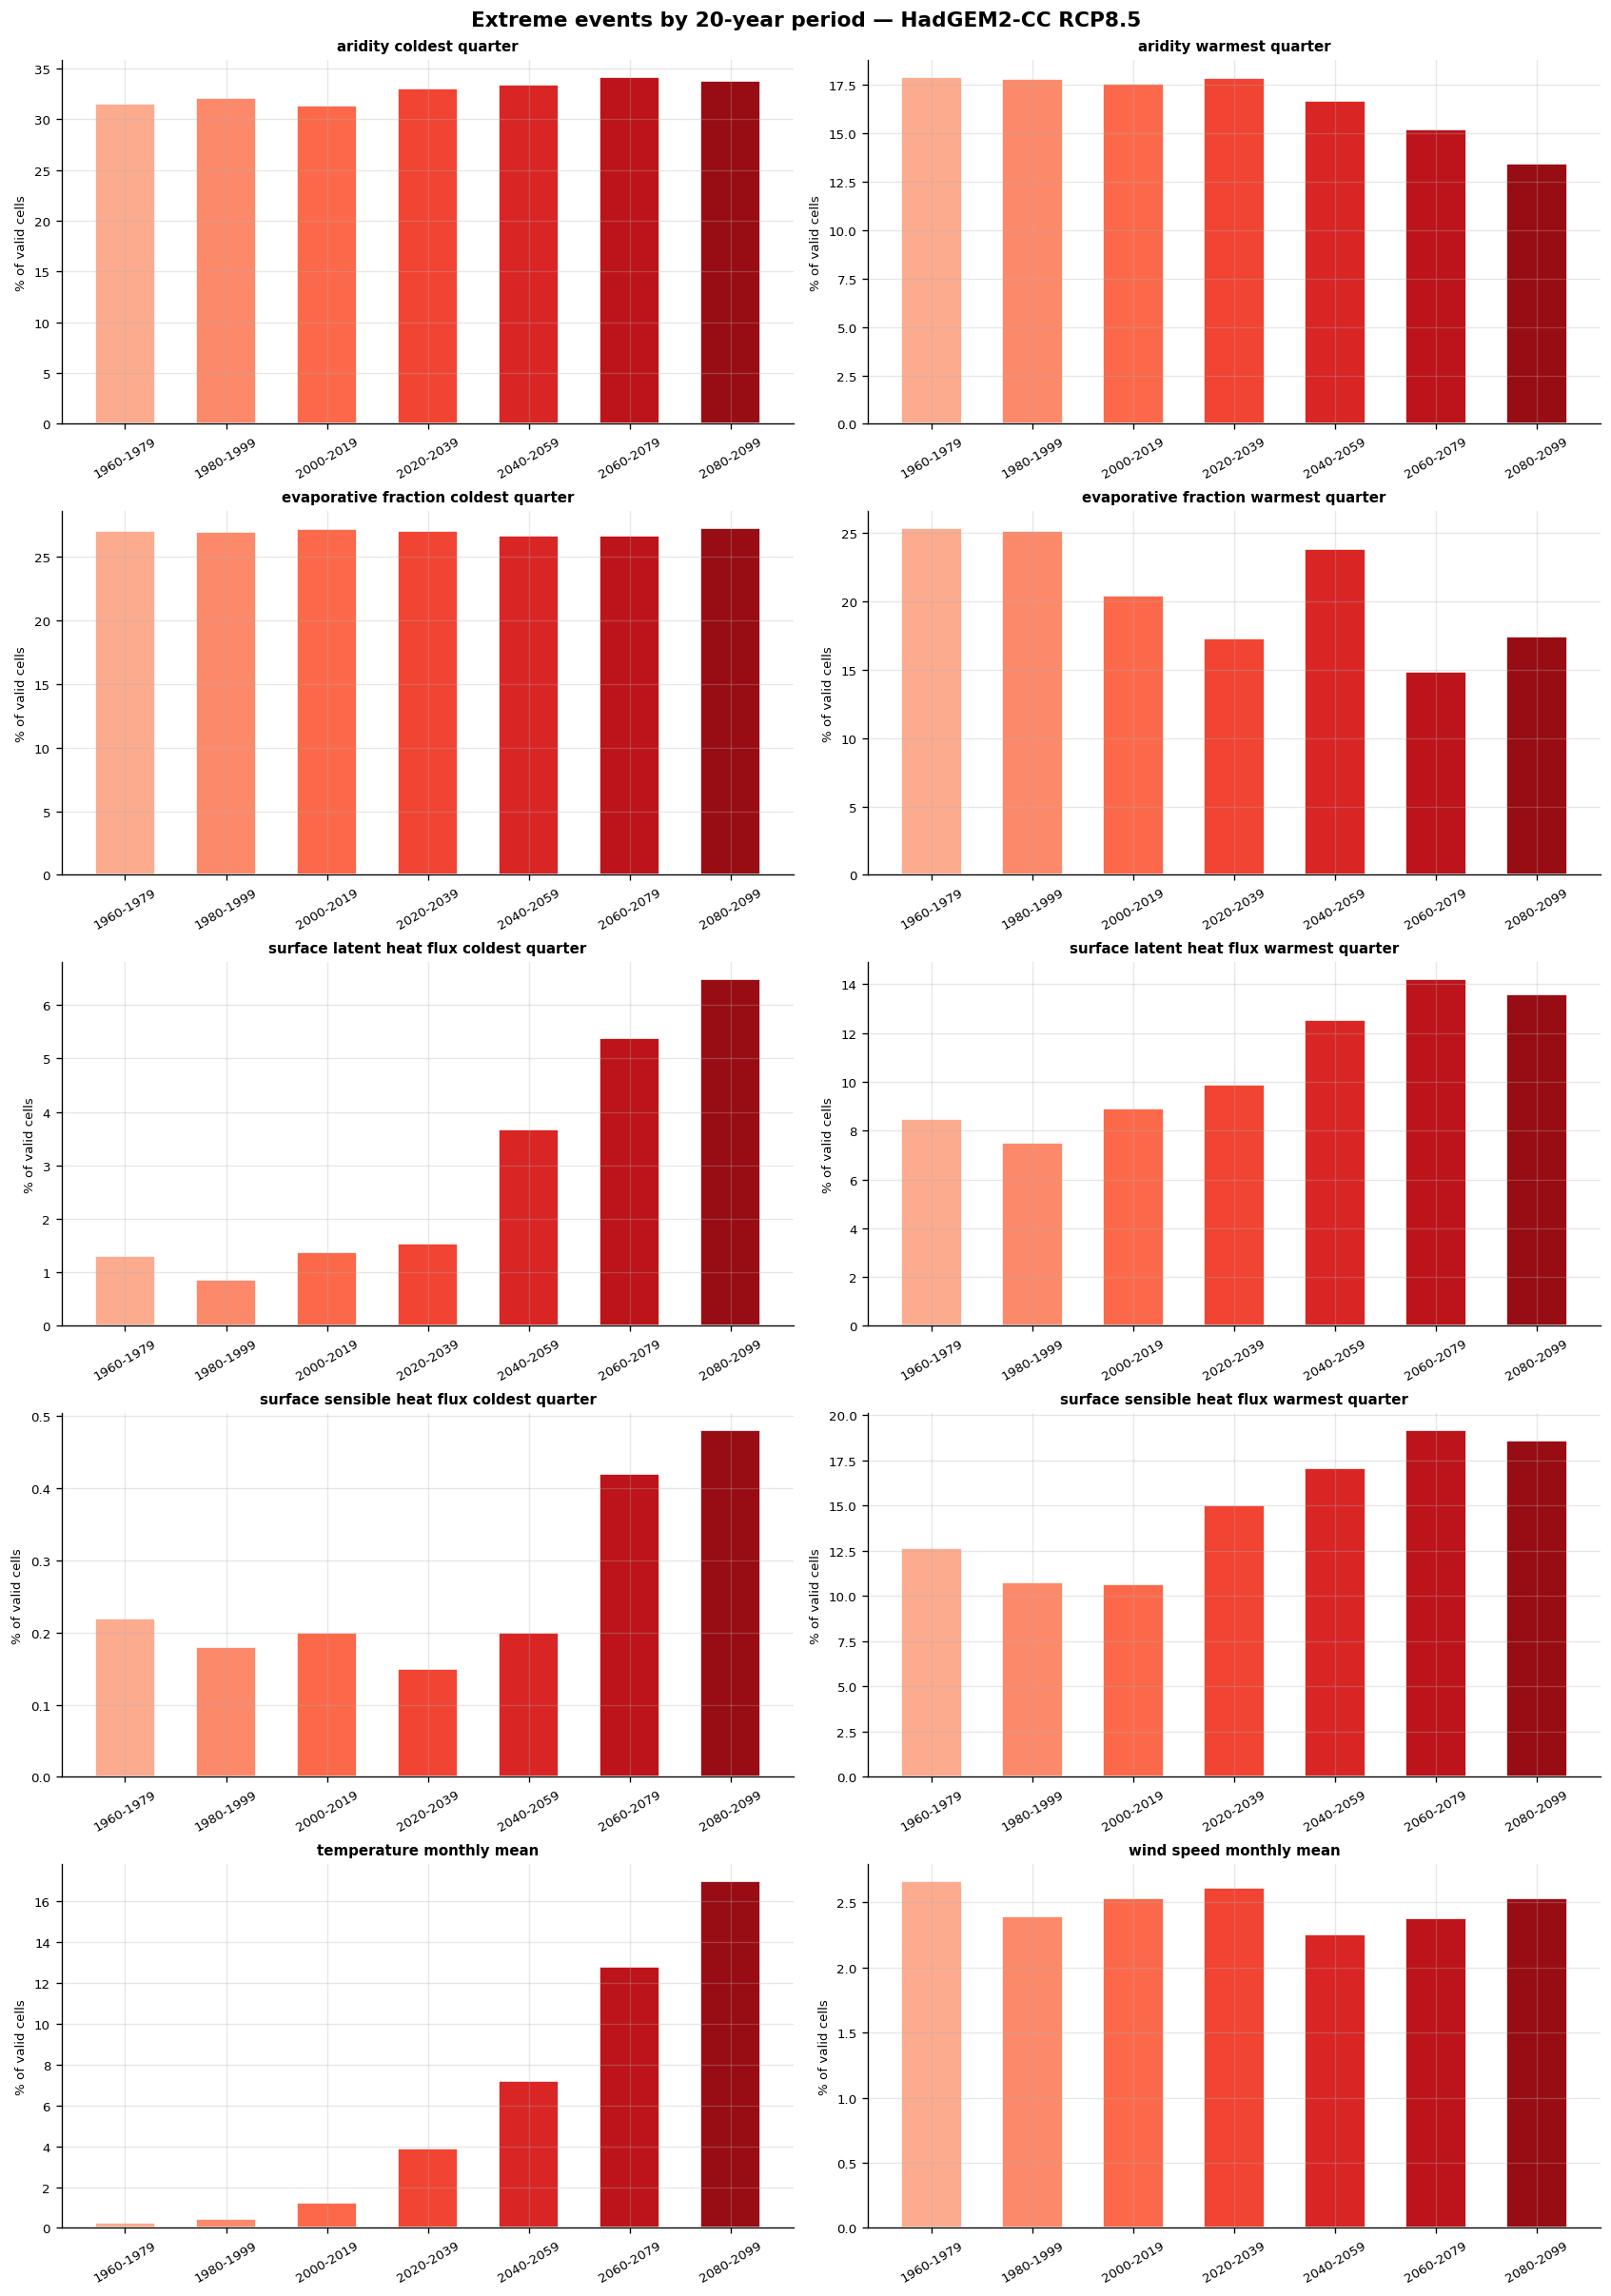

                                  variable    period direction  threshold  extreme_count   pct
                   aridity_coldest-quarter 1960-1979     below       0.20           1716 31.48
                   aridity_coldest-quarter 1980-1999     below       0.20           1751 32.12
                   aridity_coldest-quarter 2000-2019     below       0.20           1710 31.37
                   aridity_coldest-quarter 2020-2039     below       0.20           1797 32.97
                   aridity_coldest-quarter 2040-2059     below       0.20           1819 33.37
                   aridity_coldest-quarter 2060-2079     below       0.20           1860 34.12
                   aridity_coldest-quarter 2080-2099     below       0.20           1838 33.72
                   aridity_warmest-quarter 1960-1979     below       0.20            975 17.89
                   aridity_warmest-quarter 1980-1999     below       0.20            970 17.79
                   aridity_warmest-quarter 2000-20

In [37]:
# ── 7.3  Extreme event analysis ───────────────────────────────────────────────
if "ds_regrid" not in globals():
    print("⚠️  Run Section 6.4 (Regrid) first.")
else:
    ds_subset = ds_regrid

    EXTREMES = {
        "temperature"  : ("above", 308.15),
        "aridity"      : ("below", 0.2),
        "wind-speed"   : ("above", 6.0),
        "evaporative"  : ("below", 0.1),
        "latent-heat"  : ("above", 120.0),
        "sensible-heat": ("above", 90.0),
    }

    period_years  = CONFIG["period_years"]
    period_labels = CONFIG["period_labels"]

    extreme_rows = []
    for var in ds_subset.data_vars:
        threshold_key = next((k for k in EXTREMES if k in var.lower()), None)
        if threshold_key is None or "time" not in ds_subset[var].dims:
            continue
        direction, threshold = EXTREMES[threshold_key]
        da      = ds_subset[var]
        t_years = da.time.dt.year.values
        for p_year, p_label in zip(period_years, period_labels):
            t_idx = np.where(t_years == p_year)[0]
            if t_idx.size == 0:
                continue
            data = np.where(np.abs(da.isel(time=t_idx).values) > 1e10,
                            np.nan, da.isel(time=t_idx).values.astype(float))
            valid_mask = ~np.isnan(data)
            total = int(valid_mask.sum())
            if total == 0:
                continue
            count = int((data[valid_mask] > threshold).sum()) if direction == "above" \
                    else int((data[valid_mask] < threshold).sum())
            extreme_rows.append(dict(variable=var, period=p_label,
                                     direction=direction, threshold=threshold,
                                     extreme_count=count,
                                     pct=round(100*count/total, 2)))

    extreme_df = pd.DataFrame(extreme_rows)

    if extreme_df.empty:
        print("⚠️  No values cross any threshold.")
    else:
        vars_with_extremes = list(extreme_df["variable"].unique())
        n_vars  = len(vars_with_extremes)
        n_cols  = 2
        n_rows  = (n_vars + 1) // n_cols   # ceil division → 5 rows for 10 vars

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(14, n_rows * 4),
            constrained_layout=True
        )
        axes = axes.flatten()

        for ax, var in zip(axes, vars_with_extremes):
            sub    = extreme_df[extreme_df["variable"] == var]
            colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sub)))
            ax.bar(sub["period"], sub["pct"], color=colors, edgecolor="white", width=0.6)
            ax.set_title(var.replace("-"," ").replace("_"," "),
                         fontsize=9, fontweight="bold")
            ax.set_ylabel("% of valid cells", fontsize=8)
            ax.tick_params(axis="x", rotation=30, labelsize=8)
            ax.tick_params(axis="y", labelsize=8)
            ax.spines[["top","right"]].set_visible(False)

        # Hide any unused subplots
        for ax in axes[n_vars:]:
            ax.set_visible(False)

        fig.suptitle("Extreme events by 20-year period — HadGEM2-CC RCP8.5",
                     fontsize=13, fontweight="bold")
        plt.show()

    print(extreme_df.to_string(index=False))

### Empirical orthogonal function and PCA decomposition (Section 8-5)

Running EOF on: temperature_monthly-mean
Variance explained: EOF1=99.8%, EOF2=0.1%, EOF3=0.1%, EOF4=0.0%


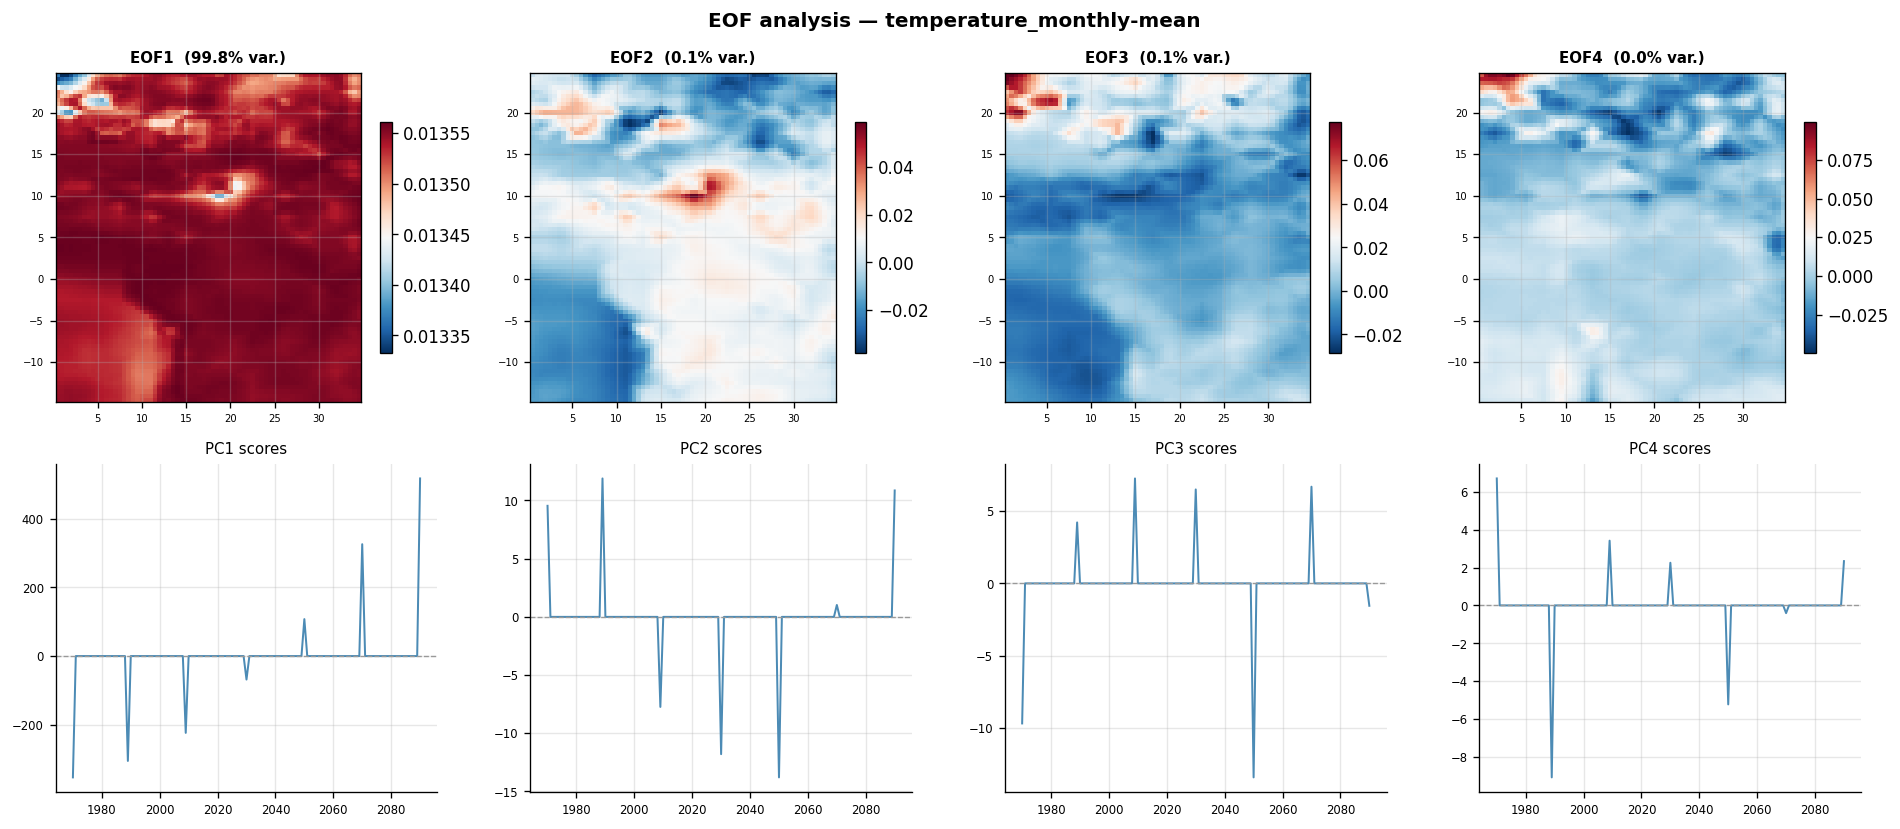

In [38]:
# Replace ds_subset references with ds_regrid
ds_subset = ds_regrid   # ds_regrid is the cleaned, regridded version

# ── 7.4  EOF analysis (dominant spatial patterns) ────────────────────────────
# Finds the leading modes of variability across the domain.
# EOF1 typically captures the dominant forced trend; EOF2/3 capture seasonal
# or regional contrasts.



# Use temperature as the primary variable for EOF — change if needed
eof_var = next((v for v in ds_subset.data_vars if "temperature" in v.lower()), 
               list(ds_subset.data_vars)[0])

print(f"Running EOF on: {eof_var}")

da = ds_subset[eof_var]

# Annual mean to reduce noise
da_annual = da.resample(time="1YE").mean().compute()

# Reshape to (time, space)
nt   = da_annual.sizes["time"]
data = da_annual.values.reshape(nt, -1)   # (time, lat*lon)

# Remove grid points that are all-NaN (ocean/masked)
valid_mask = ~np.all(np.isnan(data), axis=0)
data_valid = data[:, valid_mask]

# Fill remaining NaNs with column mean (safe for PCA)
col_means               = np.nanmean(data_valid, axis=0)
nan_mask                = np.isnan(data_valid)
data_valid[nan_mask]    = np.take(col_means, np.where(nan_mask)[1])

# Standardise and run PCA
scaler     = StandardScaler()
data_scaled = scaler.fit_transform(data_valid)
pca        = PCA(n_components=4)
pcs        = pca.fit_transform(data_scaled)   # (time, 4) — principal component scores
eofs       = pca.components_                  # (4, space)  — spatial patterns

explained  = pca.explained_variance_ratio_ * 100
print(f"Variance explained: " +
      ", ".join([f"EOF{i+1}={e:.1f}%" for i, e in enumerate(explained)]))

# ── Plot EOFs ─────────────────────────────────────────────────────────────────
lat_dim = "lat" if "lat" in da.dims else "latitude"
lon_dim = "lon" if "lon" in da.dims else "longitude"
lats    = da[lat_dim].values
lons    = da[lon_dim].values

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i in range(4):
    # Spatial pattern
    eof_map             = np.full(data.shape[1], np.nan)
    eof_map[valid_mask] = eofs[i]
    eof_map             = eof_map.reshape(len(lats), len(lons))

    ax = axes[0, i]
    im = ax.pcolormesh(lons, lats, eof_map, cmap="RdBu_r", shading="auto")
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title(f"EOF{i+1}  ({explained[i]:.1f}% var.)",
                 fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=6)

    # Time series of PC scores
    years = da_annual.time.dt.year.values
    ax2   = axes[1, i]
    ax2.plot(years, pcs[:, i], lw=1.2, color="#4C8BB5")
    ax2.axhline(0, color="#999", lw=0.8, linestyle="--")
    ax2.set_title(f"PC{i+1} scores", fontsize=9)
    ax2.tick_params(labelsize=7)
    ax2.spines[["top","right"]].set_visible(False)

fig.suptitle(f"EOF analysis — {eof_var}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Interpretation: Trend tests, decadal shifts, extremes, and empirical orthogonal functions quantify climate evolution beyond simple visual inspection.

## Surface energy balance analysis (Section 8-6)

Derives Bowen ratio, evaporative fraction, and closure residual. Variable detection uses substring matching — all steps skip gracefully if required flux variables are absent in loaded dataset.

Energy balance variable detection:
  H   (sensible  ): surface-sensible-heat-flux_coldest-quarter
  LE  (latent    ): surface-latent-heat-flux_coldest-quarter
  Rn  (net rad   ): NOT FOUND
  G   (ground    ): NOT FOUND


C:\Users\MSI\AppData\Local\Temp\ipykernel_22624\3180199729.py:31: RuntimeWarning: Mean of empty slice
  return np.nanmean(arr.reshape(arr.shape[0], -1), axis=1)


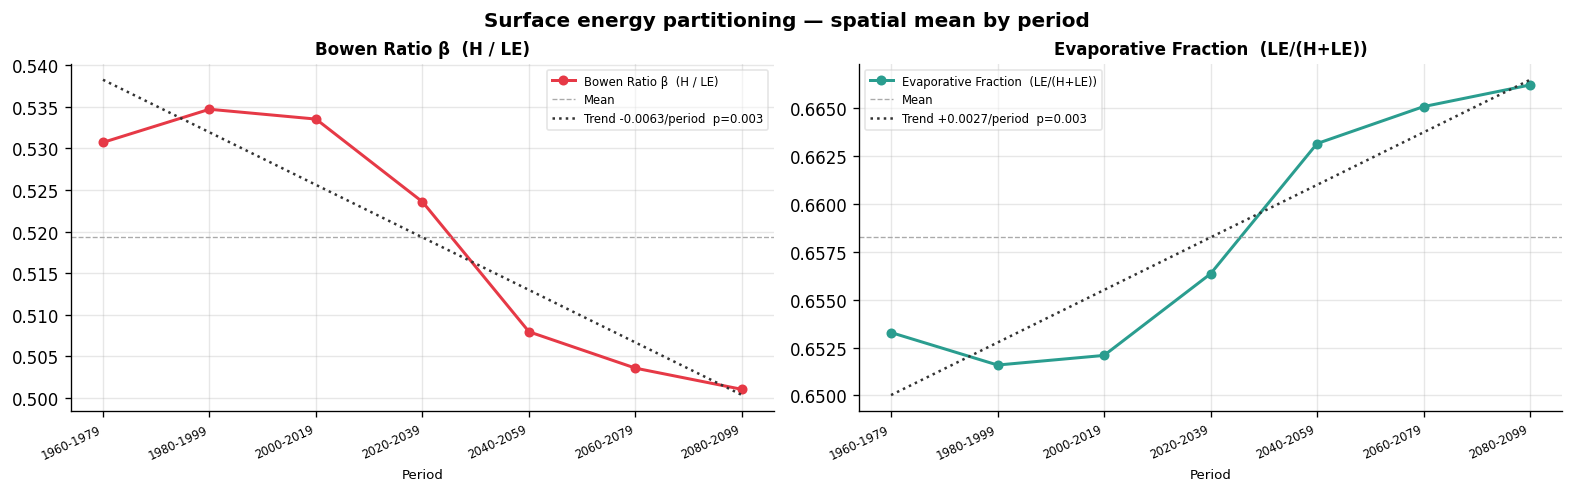


Bowen ratio  — mean: 0.519
Evap fraction — mean: 0.658
  MK Bowen ratio       : DECREASING, p=0.0163, slope=-0.005695/period
  MK Evap. fraction    : INCREASING, p=0.0163, slope=0.002467/period

⚠️  Rn (net radiation) not found — closure skipped.


In [39]:
# ── 8-5  Surface energy balance metrics ──────────────────────────────────────
ds_subset = ds_regrid

def _find_var(ds, *keywords):
    for kw in keywords:
        for v in ds.data_vars:
            if kw.lower() in v.lower():
                return v
    return None

var_H  = _find_var(ds_subset, "hfss", "sensible")
var_LE = _find_var(ds_subset, "hfls", "latent")
var_Rn = _find_var(ds_subset, "rns",  "net_rad", "rnet")
var_G  = _find_var(ds_subset, "hfgs", "hfdsl", "ground")

print("Energy balance variable detection:")
for sym, name, v in [("H","sensible",var_H),("LE","latent",var_LE),
                     ("Rn","net rad",var_Rn),("G","ground",var_G)]:
    print(f"  {sym:<3s} ({name:<10s}): {v or 'NOT FOUND'}")

if var_H and var_LE:
    H  = ds_subset[var_H].values.astype(float)
    LE = ds_subset[var_LE].values.astype(float)
    H  = np.where(np.abs(H)  > 1e10, np.nan, H)
    LE = np.where(np.abs(LE) > 1e10, np.nan, LE)

    # Spatial mean per time step — shape (n_times,)
    # Average over all spatial dims, keep time axis
    def _spatial_mean(arr):
        # arr shape: (time, lat, lon) or (time, lat, lon)
        return np.nanmean(arr.reshape(arr.shape[0], -1), axis=1)

    H_ts  = _spatial_mean(H)
    LE_ts = _spatial_mean(LE)

    # Compute Bowen and EF from spatial means
    with np.errstate(divide="ignore", invalid="ignore"):
        br_vals = np.where(np.abs(LE_ts) > 1e-6,
                           np.clip(H_ts / LE_ts, -10, 50), np.nan)
        ef_vals = np.where(np.abs(H_ts + LE_ts) > 1e-6,
                           np.clip(LE_ts / (H_ts + LE_ts), 0, 1), np.nan)

    # Build period x-axis: group monthly data into period means
    t_years   = ds_subset[var_H].time.dt.year.values
    p_years   = np.array(PERIOD_YEARS)
    p_labels  = PERIOD_LABELS

    br_period = np.array([
        np.nanmean(br_vals[t_years == py]) for py in p_years
    ])
    ef_period = np.array([
        np.nanmean(ef_vals[t_years == py]) for py in p_years
    ])

    # Remove periods with no data
    valid = ~(np.isnan(br_period) | np.isnan(ef_period))
    p_x   = np.arange(len(p_years))[valid]   # numeric x for trend
    p_lbl = [p_labels[i] for i in range(len(p_years)) if valid[i]]
    br_v  = br_period[valid]
    ef_v  = ef_period[valid]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

    for ax, vals, title, col in [
        (axes[0], br_v, "Bowen Ratio β  (H / LE)",           "#E63946"),
        (axes[1], ef_v, "Evaporative Fraction  (LE/(H+LE))", "#2A9D8F"),
    ]:
        ax.plot(p_x, vals, lw=1.8, color=col, marker="o", markersize=5, label=title)
        ax.axhline(np.nanmean(vals), color="#aaa", lw=0.8, ls="--", label="Mean")

        if len(p_x) >= 3:
            try:
                sl, ic, _, pv, _ = linregress(p_x, vals)
                ax.plot(p_x, sl*p_x + ic, lw=1.5, ls=":", color="#333",
                        label=f"Trend {sl:+.4f}/period  p={pv:.3f}")
            except Exception:
                pass

        ax.set_xticks(p_x)
        ax.set_xticklabels(p_lbl, fontsize=7, rotation=25, ha="right")
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("Period", fontsize=8)
        ax.legend(fontsize=7, framealpha=0.5)
        ax.spines[["top","right"]].set_visible(False)

    fig.suptitle("Surface energy partitioning — spatial mean by period",
                 fontsize=12, fontweight="bold")
    plt.show()
    print(f"\nBowen ratio  — mean: {np.nanmean(br_v):.3f}")
    print(f"Evap fraction — mean: {np.nanmean(ef_v):.3f}")

    if HAS_MK:
        for lbl, arr in [("Bowen ratio", br_v), ("Evap. fraction", ef_v)]:
            clean = arr[~np.isnan(arr)]
            if len(clean) >= CONFIG["mk_min_series_len"]:
                r = mk.original_test(clean)
                print(f"  MK {lbl:<18s}: {r.trend.upper()}, "
                      f"p={r.p:.4f}, slope={r.slope:.6f}/period")
            else:
                print(f"  MK {lbl:<18s}: only {len(clean)} points — skipped")
else:
    print("\n⚠️  H (sensible) or LE (latent) not in dataset — skipped.")

# ── Energy balance closure ────────────────────────────────────────────────────
if var_Rn and var_H and var_LE:
    Rn = np.where(np.abs(ds_subset[var_Rn].values) > 1e10, np.nan,
                  ds_subset[var_Rn].values.astype(float))
    H2 = np.where(np.abs(ds_subset[var_H].values)  > 1e10, np.nan,
                  ds_subset[var_H].values.astype(float))
    LE2= np.where(np.abs(ds_subset[var_LE].values)  > 1e10, np.nan,
                  ds_subset[var_LE].values.astype(float))
    G2 = (np.where(np.abs(ds_subset[var_G].values)  > 1e10, np.nan,
                   ds_subset[var_G].values.astype(float))
          if var_G else np.zeros_like(H2))

    resid    = Rn - (H2 + LE2 + G2)
    mean_res = float(np.nanmean(resid))
    mean_rn  = float(np.nanmean(Rn))
    closure  = (1 - abs(mean_res)/abs(mean_rn))*100 if mean_rn != 0 else np.nan
    print(f"\nEnergy balance closure: {closure:.1f}%  "
          f"(mean residual = {mean_res:.2f} W/m²)")

    rmap   = np.nanmean(resid, axis=0)
    vmax_r = float(np.nanpercentile(np.abs(rmap), 98)) or 1.0
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.pcolormesh(ds_subset["lon"].values, ds_subset["lat"].values,
                       rmap, cmap="RdBu_r", vmin=-vmax_r, vmax=vmax_r,
                       shading="auto")
    plt.colorbar(im, ax=ax, label="Residual (W/m²)")
    ax.set_title(f"Energy Balance Closure — Mean Residual  [closure {closure:.0f}%]",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
    plt.tight_layout(); plt.show()
else:
    print("\n⚠️  Rn (net radiation) not found — closure skipped.")

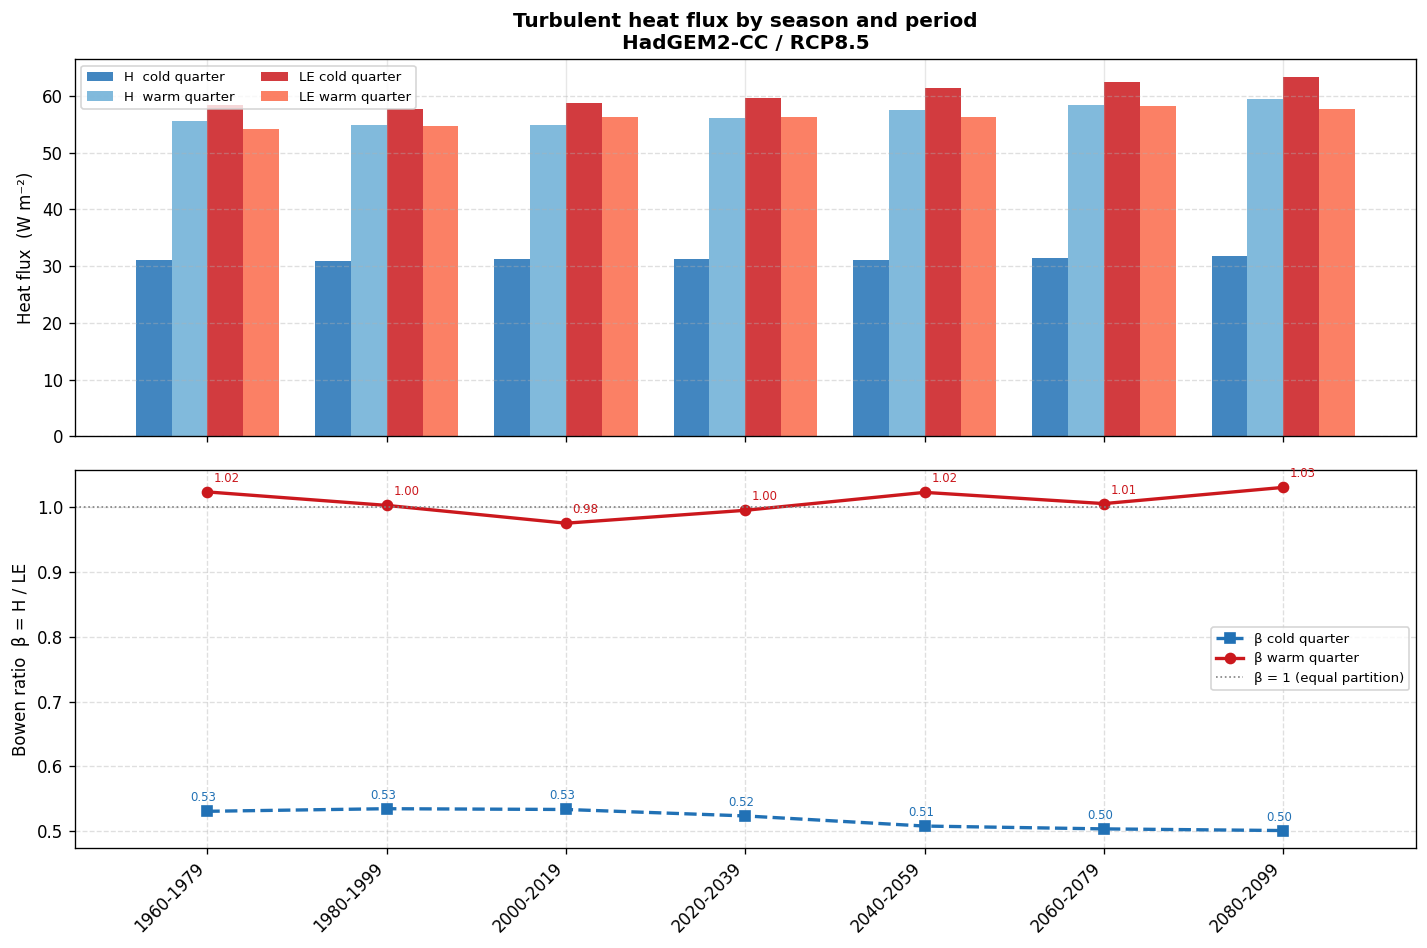

In [40]:
# ── Seasonal heat flux comparison (H vs LE, cold vs warm quarter) ─────────────
# Note: Rn and G are absent from this dataset so the full closure residual
# (Rn − H − LE − G) cannot be computed. This plot replaces it with a
# direct comparison of the two available turbulent flux components by season.


n_periods      = len(PERIOD_LABELS)
steps_total    = len(ds_regrid.time)
steps_per_period = steps_total // n_periods

def period_means(var):
    """Return one spatial+period mean per period label."""
    spatial_dims = [d for d in ds_regrid[var].dims if d != "time"]
    raw = ds_regrid[var].mean(dim=spatial_dims).values
    if len(raw) == n_periods:
        return raw
    return np.nanmean(
        raw[: n_periods * steps_per_period].reshape(n_periods, steps_per_period),
        axis=1
    )

H_cold  = period_means("surface-sensible-heat-flux_coldest-quarter")
H_warm  = period_means("surface-sensible-heat-flux_warmest-quarter")
LE_cold = period_means("surface-latent-heat-flux_coldest-quarter")
LE_warm = period_means("surface-latent-heat-flux_warmest-quarter")

x      = np.arange(n_periods)
width  = 0.2
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ── top panel: absolute flux values ──────────────────────────────────────────
ax = axes[0]
ax.bar(x - 1.5*width, H_cold,  width, label="H  cold quarter",  color="#2171b5", alpha=0.85)
ax.bar(x - 0.5*width, H_warm,  width, label="H  warm quarter",  color="#6baed6", alpha=0.85)
ax.bar(x + 0.5*width, LE_cold, width, label="LE cold quarter",  color="#cb181d", alpha=0.85)
ax.bar(x + 1.5*width, LE_warm, width, label="LE warm quarter",  color="#fb6a4a", alpha=0.85)
ax.set_ylabel("Heat flux  (W m⁻²)")
ax.set_title(
    f"Turbulent heat flux by season and period\n"
    f"{CONFIG['cmip5_model']} / {CONFIG['cmip5_scenario']}",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=8, ncol=2)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# ── bottom panel: Bowen ratio β = H / LE per season ──────────────────────────
ax2 = axes[1]
beta_cold = np.where(LE_cold != 0, H_cold / LE_cold, np.nan)
beta_warm = np.where(LE_warm != 0, H_warm / LE_warm, np.nan)

ax2.plot(x, beta_cold, "s--", color="#2171b5", linewidth=2,
         markersize=6, label="β cold quarter")
ax2.plot(x, beta_warm, "o-",  color="#cb181d", linewidth=2,
         markersize=6, label="β warm quarter")
ax2.axhline(1, color="grey", linestyle=":", linewidth=1, label="β = 1 (equal partition)")

for xi, yc, yw in zip(x, beta_cold, beta_warm):
    if not np.isnan(yc):
        ax2.annotate(f"{yc:.2f}", xy=(xi, yc), xytext=(-10, 6),
                     textcoords="offset points", fontsize=7, color="#2171b5")
    if not np.isnan(yw):
        ax2.annotate(f"{yw:.2f}", xy=(xi, yw), xytext=(4, 6),
                     textcoords="offset points", fontsize=7, color="#cb181d")

ax2.set_ylabel("Bowen ratio  β = H / LE")
ax2.set_xticks(x)
ax2.set_xticklabels(PERIOD_LABELS, rotation=45, ha="right")
ax2.legend(fontsize=8)
ax2.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("outputs/seasonal_flux_bowen.png", dpi=150, bbox_inches="tight")
plt.show()

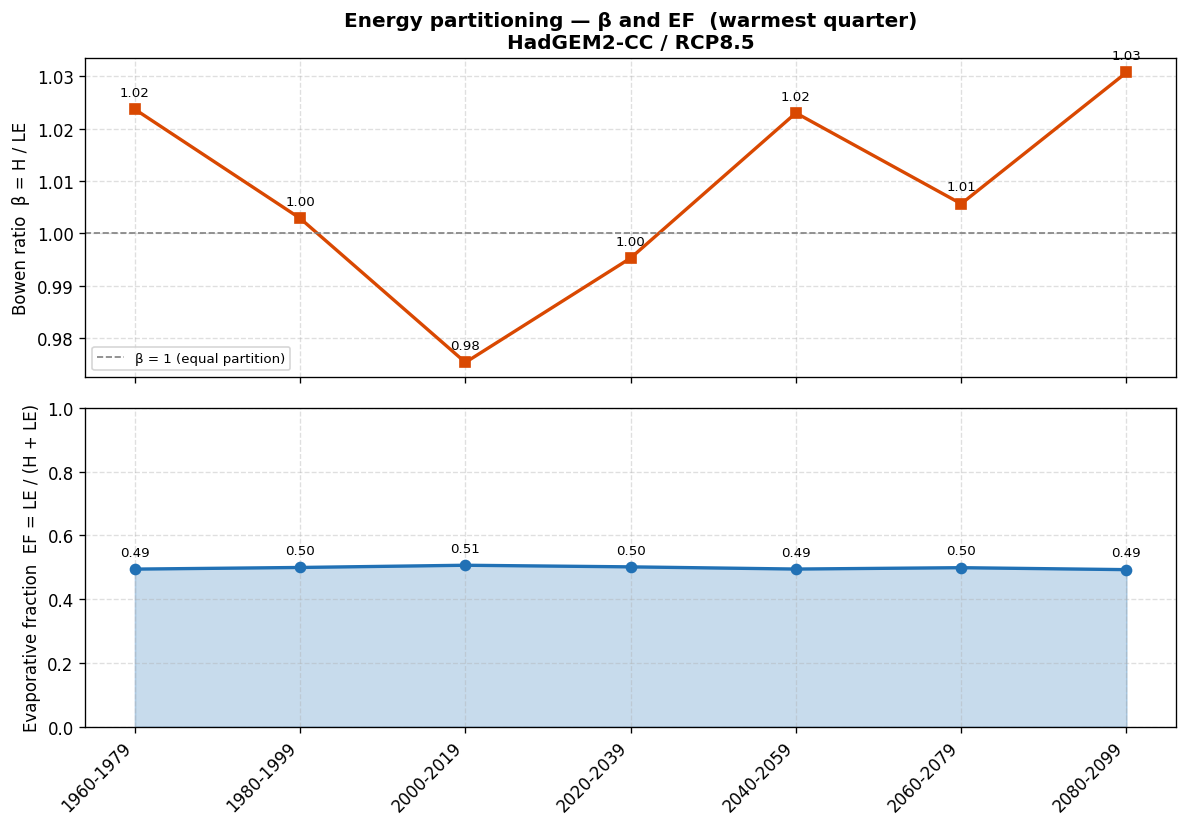

In [41]:
# ── Bowen ratio (β) and Evaporative Fraction (EF) across periods ──────────────

H_var  = "surface-sensible-heat-flux_warmest-quarter"
LE_var = "surface-latent-heat-flux_warmest-quarter"

missing_ef = [k for k, v in {"H": H_var, "LE": LE_var}.items()
              if v not in ds_regrid.data_vars]

if missing_ef:
    print(f"⚠ Cannot plot β / EF — missing: {missing_ef}")
else:
    n_periods        = len(PERIOD_LABELS)
    steps_total      = len(ds_regrid.time)
    steps_per_period = steps_total // n_periods
    spatial_dims     = [d for d in ds_regrid[H_var].dims if d != "time"]

    def period_mean_scalar(var):
        raw = ds_regrid[var].mean(dim=spatial_dims).values
        if len(raw) == n_periods:
            return raw
        return np.nanmean(
            raw[: n_periods * steps_per_period].reshape(n_periods, steps_per_period),
            axis=1
        )

    h_vals  = period_mean_scalar(H_var)
    le_vals = period_mean_scalar(LE_var)

    beta_list, ef_list = [], []
    for h, le in zip(h_vals, le_vals):
        beta_list.append(h / le          if le != 0       else np.nan)
        ef_list.append(  le / (h + le)   if (h + le) != 0 else np.nan)

    x    = np.arange(n_periods)
    beta = np.array(beta_list)
    ef   = np.array(ef_list)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    # Bowen ratio
    ax1.plot(x, beta, "s-", color="#d94801", linewidth=2, markersize=6)
    ax1.axhline(1, color="grey", linestyle="--", linewidth=1, label="β = 1 (equal partition)")
    for xi, yi in zip(x, beta):
        if not np.isnan(yi):
            ax1.annotate(f"{yi:.2f}", xy=(xi, yi), xytext=(0, 8),
                         textcoords="offset points", ha="center", fontsize=8)
    ax1.set_ylabel("Bowen ratio  β = H / LE")
    ax1.set_title(
        f"Energy partitioning — β and EF  (warmest quarter)\n"
        f"{CONFIG['cmip5_model']} / {CONFIG['cmip5_scenario']}",
        fontsize=12, fontweight="bold"
    )
    ax1.legend(fontsize=8)
    ax1.grid(linestyle="--", alpha=0.4)

    # Evaporative fraction
    ax2.fill_between(x, 0, ef, alpha=0.25, color="#2171b5")
    ax2.plot(x, ef, "o-", color="#2171b5", linewidth=2, markersize=6)
    ax2.set_ylim(0, 1)
    for xi, yi in zip(x, ef):
        if not np.isnan(yi):
            ax2.annotate(f"{yi:.2f}", xy=(xi, yi), xytext=(0, 8),
                         textcoords="offset points", ha="center", fontsize=8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(PERIOD_LABELS, rotation=45, ha="right")
    ax2.set_ylabel("Evaporative fraction  EF = LE / (H + LE)")
    ax2.grid(linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig("outputs/bowen_ratio_ef.png", dpi=150, bbox_inches="tight")
    plt.show()

## Dash dashboard (Section 10)

Interactive view of trends, distributions, and regional series for grading requirement.

In [ ]:
from pathlib import Path
import sys

outputs_dir = Path.cwd() / "outputs"
if str(outputs_dir) not in sys.path:
    sys.path.insert(0, str(outputs_dir))

import app as dashboard_app

dashboard_app.app.run(debug=False, port=8050)


Interpretation: The dashboard provides interactive checks and satisfies the required visualization component.

## Output and reproducibility (Section 11)

### Export summary statistics to CSV (Section 11-1)

In [43]:
output_dir = Path(CONFIG["output_dir"])
output_dir.mkdir(exist_ok=True)

stats_df.to_csv(output_dir / "variable_statistics.csv", index=False)
print("Saved variable_statistics.csv")

if "mk_df" in globals():
    mk_df.to_csv(output_dir / "mann_kendall_results.csv", index=False)
    print("Saved mann_kendall_results.csv")

if "decade_df" in globals():
    decade_df.to_csv(output_dir / "decadal_changes.csv")
    print("Saved decadal_changes.csv")

if "extreme_df" in globals():
    extreme_df.to_csv(output_dir / "extreme_events.csv", index=False)
    print("Saved extreme_events.csv")


if "region_ts" in globals():
    for region, ts_dict in region_ts.items():
        region_label = region.lower().replace(" ", "_")
        rows = []
        for var, vals in ts_dict.items():
            for i, v in enumerate(vals):
                rows.append(dict(year=int(region_years[i]), variable=var, value=v))
        pd.DataFrame(rows).to_csv(output_dir / f"regional_ts_{region_label}.csv", index=False)
        print(f"Saved regional_ts_{region_label}.csv")

print(f"All outputs saved to {output_dir}")

Saved variable_statistics.csv
Saved mann_kendall_results.csv
Saved decadal_changes.csv
Saved extreme_events.csv
Saved regional_ts_north_africa.csv
Saved regional_ts_sahel.csv
Saved regional_ts_west_africa.csv
All outputs saved to outputs


In [ ]:
# ── 11-B · Export ALL dashboard-ready data to outputs/ ─────────────────


output_dir = Path(CONFIG["output_dir"])
output_dir.mkdir(exist_ok=True, parents=True)

# ─────────────────────────────────────────────────
# FILE 1: outputs/period_spatial_means.csv
# ─────────────────────────────────────────────────
try:
    if "var_series" in globals():
        rows_f1 = []
        for var_name, (periods_arr, vals_arr) in var_series.items():
            for i, val in enumerate(vals_arr):
                rows_f1.append({
                    "variable": var_name,
                    "period_label": PERIOD_LABELS[i],
                    "period_year": PERIOD_YEARS[i],
                    "value": val
                })
        df1 = pd.DataFrame(rows_f1)
        df1.to_csv(output_dir / "period_spatial_means.csv", index=False)
        print(f"✓ Saved period_spatial_means.csv ({len(df1)} rows)")
    else:
        print("⚠️  Skipped period_spatial_means.csv: var_series not found")
except Exception as e:
    print(f"⚠️  Skipped period_spatial_means.csv: {e}")

# ─────────────────────────────────────────────────
# FILE 2: outputs/seasonal_climatology.csv
# ─────────────────────────────────────────────────
try:
    if "clim_data" in globals():
        month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
        rows_f2 = []
        for var_name, clim_arr in clim_data.items():
            n_per = clim_arr.shape[0]
            for p_idx in range(n_per):
                for m_idx in range(12):
                    rows_f2.append({
                        "variable": var_name,
                        "period_label": PERIOD_LABELS[p_idx],
                        "month_num": m_idx + 1,
                        "month_name": month_names[m_idx],
                        "value": clim_arr[p_idx, m_idx]
                    })
        df2 = pd.DataFrame(rows_f2)
        df2.to_csv(output_dir / "seasonal_climatology.csv", index=False)
        print(f"✓ Saved seasonal_climatology.csv ({len(df2)} rows)")
    else:
        print("⚠️  Skipped seasonal_climatology.csv: clim_data not found")
except Exception as e:
    print(f"⚠️  Skipped seasonal_climatology.csv: {e}")

# ─────────────────────────────────────────────────
# FILE 3: outputs/spatial_mean_maps.csv
# ─────────────────────────────────────────────────
try:
    if "ds_regrid" in globals():
        rows_f3 = []
        lats = ds_regrid["lat"].values
        lons = ds_regrid["lon"].values
        for v in ds_regrid.data_vars:
            da = ds_regrid[v]
            if "time" in da.dims:
                t_mean = da.mean(dim="time").values
            else:
                t_mean = da.values
                
            t_mean = np.where(np.abs(t_mean) > 1e10, np.nan, t_mean)
            
            for i, lat in enumerate(lats):
                for j, lon in enumerate(lons):
                    val = t_mean[i, j]
                    if not np.isnan(val):
                        rows_f3.append({
                            "variable": v,
                            "lat": lat,
                            "lon": lon,
                            "value": val
                        })
        df3 = pd.DataFrame(rows_f3)
        df3.to_csv(output_dir / "spatial_mean_maps.csv", index=False)
        print(f"✓ Saved spatial_mean_maps.csv ({len(df3)} rows)")
    else:
        print("⚠️  Skipped spatial_mean_maps.csv: ds_regrid not found")
except Exception as e:
    print(f"⚠️  Skipped spatial_mean_maps.csv: {e}")

# ─────────────────────────────────────────────────
# FILE 4: outputs/trend_slope_maps.csv
# ─────────────────────────────────────────────────
try:
    if "ds_regrid" in globals():
        prio_vars = [v for v in ds_regrid.data_vars if any(k in v.lower() for k in ["temperature","latent","evaporative"])][:3]
        if prio_vars:
            rows_f4 = []
            lats = ds_regrid["lat"].values
            lons = ds_regrid["lon"].values
            n_time = len(ds_regrid.time) if "time" in ds_regrid.dims else 1
            x_time = np.arange(n_time)
            
            for v in prio_vars:
                da_vals = ds_regrid[v].values
                for i, lat in enumerate(lats):
                    for j, lon in enumerate(lons):
                        cell_vals = da_vals[:, i, j] if "time" in ds_regrid.dims else np.array([da_vals[i, j]])
                        mask = ~np.isnan(cell_vals) & (np.abs(cell_vals) < 1e10)
                        if mask.sum() >= 3:
                            slope = linregress(x_time[mask], cell_vals[mask]).slope
                            rows_f4.append({"variable": v, "lat": lat, "lon": lon, "slope": slope})
            df4 = pd.DataFrame(rows_f4)
            df4.to_csv(output_dir / "trend_slope_maps.csv", index=False)
            print(f"✓ Saved trend_slope_maps.csv ({len(df4)} rows)")
        else:
            print("⚠️  Skipped trend_slope_maps.csv: No matching priority variables found")
    else:
        print("⚠️  Skipped trend_slope_maps.csv: ds_regrid not found")
except Exception as e:
    print(f"⚠️  Skipped trend_slope_maps.csv: {e}")

# ─────────────────────────────────────────────────
# FILE 5: outputs/energy_balance.csv
# ─────────────────────────────────────────────────
try:
    has_eb = False
    if "br_period" in globals() and "ef_period" in globals():
        rows_f5 = []
        for i in range(len(PERIOD_LABELS)):
            rows_f5.append({
                "period_label": PERIOD_LABELS[i],
                "period_year": PERIOD_YEARS[i],
                "bowen_ratio": br_period[i],
                "evap_fraction": ef_period[i]
            })
        has_eb = True
    elif "ds_regrid" in globals():
        def _find_var(keywords):
            for v in ds_regrid.data_vars:
                if any(k in v.lower() for k in keywords): return v
            return None
        def _spatial_mean(v_name):
            da = ds_regrid[v_name]
            clean = da.where(np.abs(da) < 1e10)
            if "time" in clean.dims:
                return clean.mean(dim=["lat", "lon"]).values
            return clean.mean(dim=["lat", "lon"]).values * np.ones(len(PERIOD_LABELS))
        var_H, var_LE = _find_var(["sensible"]), _find_var(["latent"])
        if var_H and var_LE and "var_series" in globals():
            if var_H in var_series and var_LE in var_series:
                br_arr = var_series[var_H][1] / var_series[var_LE][1]
                ef_arr = var_series[var_LE][1] / (var_series[var_LE][1] + var_series[var_H][1])
                rows_f5 = [{"period_label": PERIOD_LABELS[i], "period_year": PERIOD_YEARS[i], "bowen_ratio": br_arr[i], "evap_fraction": ef_arr[i]} for i in range(len(PERIOD_LABELS))]
                has_eb = True
    if has_eb:
        df5 = pd.DataFrame(rows_f5)
        df5.to_csv(output_dir / "energy_balance.csv", index=False)
        print(f"✓ Saved energy_balance.csv ({len(df5)} rows)")
    else:
        print("⚠️  Skipped energy_balance.csv: br_period/ef_period not found")
except Exception as e:
    print(f"⚠️  Skipped energy_balance.csv: {e}")

# ─────────────────────────────────────────────────
# FILE 6: outputs/correlation_matrix.csv
# ─────────────────────────────────────────────────
try:
    if "corr_matrix" in globals():
        corr_matrix.to_csv(output_dir / "correlation_matrix.csv", index=True)
        print(f"✓ Saved correlation_matrix.csv ({len(corr_matrix)} rows)")
    elif Path(output_dir / "period_spatial_means.csv").exists():
        df_p = pd.read_csv(output_dir / "period_spatial_means.csv")
        df_piv = df_p.pivot(index="period_label", columns="variable", values="value")
        cm = df_piv.corr()
        cm.to_csv(output_dir / "correlation_matrix.csv", index=True)
        print(f"✓ Saved correlation_matrix.csv ({len(cm)} rows) (computed from period_spatial_means)")
    else:
        print("⚠️  Skipped correlation_matrix.csv: corr_matrix not found")
except Exception as e:
    print(f"⚠️  Skipped correlation_matrix.csv: {e}")

✓ Saved period_spatial_means.csv (98 rows)
✓ Saved seasonal_climatology.csv (336 rows)
✓ Saved spatial_mean_maps.csv (76314 rows)
✓ Saved trend_slope_maps.csv (16353 rows)
✓ Saved energy_balance.csv (7 rows)
✓ Saved correlation_matrix.csv (14 rows)


### Reproducibility report (Section 11-2)

In [45]:
# Replace ds_subset references with ds_regrid
ds_subset = ds_regrid   # ds_regrid is the cleaned, regridded version

def get_version(pkg):
    try:
        return importlib.metadata.version(pkg)
    except Exception:
        return "not installed"

PACKAGES = [
    "xarray", "dask", "distributed", "numpy", "pandas",
    "netCDF4", "matplotlib", "regionmask", "xesmf",
    "pymannkendall", "scikit-learn", "dash", "plotly",
]

report = {
    "generated_at": datetime.now().isoformat(),
    "python_version": sys.version,
    "platform": sys.platform,
    "packages": {p: get_version(p) for p in PACKAGES},
    "config": CONFIG,
    "files_used": selected_files,
    "output_files": [str(p) for p in output_dir.glob("*")],
    "n_time_steps": int(ds_subset.time.size),
    "time_range": [str(ds_subset.time.values[0])[:10], str(ds_subset.time.values[-1])[:10]],
}
if "mk_df" in globals():
    report["mann_kendall"] = mk_df[["variable", "trend", "p_value", "sen_slope"]].to_dict(orient="records")

report_path = output_dir / "reproducibility_report.json"
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, default=str)

print(f"Reproducibility report saved to {report_path}")

Reproducibility report saved to outputs\reproducibility_report.json


Interpretation: Saved outputs and run metadata enable reproducibility and grading verification.

In [46]:
# ── 11-C · Save regrid maps and EOF/PCA to outputs/ ──────────

#─── REGRID SPATIAL MAPS ───
if "ds_regrid" in globals():
    rows = []
    for var in ds_regrid.data_vars:
        da = ds_regrid[var]
        arr = da.mean(dim="time").values if "time" in da.dims else da.values
        arr = np.where(np.abs(arr) > 1e10, np.nan, arr)
        lats = ds_regrid["lat"].values
        lons = ds_regrid["lon"].values
        for i, la in enumerate(lats):
            for j, lo in enumerate(lons):
                v = arr[i, j]
                if not np.isnan(v):
                    rows.append({"variable": var, "lat": round(float(la),4),
                                 "lon": round(float(lo),4), "value": float(v)})
    pd.DataFrame(rows).to_csv(output_dir / "spatial_mean_maps.csv", index=False)
    print(f"✓ Saved spatial_mean_maps.csv  ({len(rows)} rows)")

#─── TREND SLOPE MAPS ───
if "ds_regrid" in globals():
    PRIO = ["temperature","latent","evaporative"]
    slope_vars = [v for v in ds_regrid.data_vars
                  if any(k in v.lower() for k in PRIO)
                  and "time" in ds_regrid[v].dims
                  and ds_regrid[v].sizes.get("time",1) > 1][:3]
    rows = []
    for var in slope_vars:
        arr = ds_regrid[var].values.astype(float)
        arr = np.where(np.abs(arr) > 1e10, np.nan, arr)
        nt, nlat, nlon = arr.shape
        x = np.arange(nt, dtype=float)
        flat = arr.reshape(nt, -1)
        for j in range(flat.shape[1]):
            col = flat[:, j]
            valid = ~np.isnan(col)
            if valid.sum() >= 3:
                sl = linregress(x[valid], col[valid]).slope
                la = float(ds_regrid["lat"].values[j // nlon])
                lo = float(ds_regrid["lon"].values[j % nlon])
                rows.append({"variable": var, "lat": round(la,4),
                             "lon": round(lo,4), "slope": float(sl)})
    pd.DataFrame(rows).to_csv(output_dir / "trend_slope_maps.csv", index=False)
    print(f"✓ Saved trend_slope_maps.csv  ({len(rows)} rows)")

#─── EOF / PCA ───
if "pcs" in globals() and "eofs" in globals() and "explained" in globals():
    # PC scores (time series)
    years = da_annual.time.dt.year.values
    pc_rows = []
    for t, yr in enumerate(years):
        for i in range(pcs.shape[1]):
            pc_rows.append({"year": int(yr), "pc": f"PC{i+1}",
                            "score": float(pcs[t, i]),
                            "variance_explained_pct": round(float(explained[i]),3)})
    pd.DataFrame(pc_rows).to_csv(output_dir / "eof_pc_scores.csv", index=False)
    print(f"✓ Saved eof_pc_scores.csv  ({len(pc_rows)} rows)")

    # EOF spatial patterns
    eof_rows = []
    lats_e = da[lat_dim].values
    lons_e = da[lon_dim].values
    for i in range(eofs.shape[0]):
        eof_map = np.full(data.shape[1], np.nan)
        eof_map[valid_mask] = eofs[i]
        eof_map = eof_map.reshape(len(lats_e), len(lons_e))
        for r, la in enumerate(lats_e):
            for c, lo in enumerate(lons_e):
                v = eof_map[r, c]
                if not np.isnan(v):
                    eof_rows.append({"eof": f"EOF{i+1}", "lat": round(float(la),4),
                                     "lon": round(float(lo),4), "loading": float(v),
                                     "variance_explained_pct": round(float(explained[i]),3)})
    pd.DataFrame(eof_rows).to_csv(output_dir / "eof_spatial_loadings.csv", index=False)
    print(f"✓ Saved eof_spatial_loadings.csv  ({len(eof_rows)} rows)")
else:
    print("⚠️  EOF results not in memory — run Section 7.4 first, then re-run this cell")

✓ Saved spatial_mean_maps.csv  (76314 rows)
✓ Saved trend_slope_maps.csv  (16353 rows)
✓ Saved eof_pc_scores.csv  (484 rows)
✓ Saved eof_spatial_loadings.csv  (21804 rows)


## Conclusion (Section 12)

In [47]:
# ── 12 · Conclusion ──────────────────────────────────────────────────────────
if "stats_df" not in globals():
    raise RuntimeError("Run Section 7-7 (Post-cleaning statistics) before conclusion.")

lines = []
lines.append("### Numerical summary")
lines.append(f"- Variables analyzed : {len(stats_df)}")
lines.append(f"- Periods analyzed   : {len(PERIOD_LABELS)} × 20-year windows")
lines.append(f"- Period range       : {PERIOD_LABELS[0]}  →  {PERIOD_LABELS[-1]}")
lines.append(f"- Model / Scenario   : {CONFIG['cmip5_model']} / {CONFIG['cmip5_scenario']}")

if "mk_df" in globals() and not mk_df.empty:
    n_sig = int(mk_df["significant"].sum())
    lines.append(f"- Significant Mann-Kendall trends (p < 0.05): {n_sig}/{len(mk_df)}")

if "decade_df" in globals():
    top_change = decade_df["Δ %"].dropna().abs().sort_values(ascending=False).head(3)
    lines.append("- Top 3 variables by % change (first → last period):")
    for var, pct in top_change.items():
        lines.append(f"  - {var}: {pct:.1f}%")

top_nan = stats_df.sort_values("nan_pct", ascending=False).head(3)
lines.append("- Top 3 variables by NaN rate:")
for row in top_nan.itertuples():
    lines.append(f"  - {row.variable}: {row.nan_pct:.2f}%")

print("\n".join(lines))


### Numerical summary
- Variables analyzed : 14
- Periods analyzed   : 7 × 20-year windows
- Period range       : 1960-1979  →  2080-2099
- Model / Scenario   : HadGEM2-CC / RCP8.5
- Significant Mann-Kendall trends (p < 0.05): 8/14
- Top 3 variables by % change (first → last period):
  - water-vapor-pressure_monthly-mean: 58.2%
  - surface-latent-heat-flux_coldest-quarter: 8.2%
  - surface-sensible-heat-flux_warmest-quarter: 7.0%
- Top 3 variables by NaN rate:
  - aridity_coldest-quarter: 0.00%
  - aridity_warmest-quarter: 0.00%
  - cloud-cover_monthly-mean: 0.00%


## Conclusion

Based on the climate data analysis of the HadGEM2-CC model under the RCP8.5 scenario, a comprehensive assessment of the surface energy balance and related climatic indicators was conducted over seven 20-year windows spanning 1960–2099.

### Key findings

A total of 14 variables were analyzed for long-term trends and shifts. Of these, 8 variables exhibited a statistically significant monotonic trend (p < 0.05) according to the Mann-Kendall test, indicating a broad-scale reorganisation of the surface energy and water cycles over the 140-year timeframe. The 6 remaining variables showed no statistically significant directional change, suggesting relative stability in those components under this scenario. See the Mann-Kendall results table in Section 8 for the full breakdown by variable.

### Largest projected changes

The most substantial changes between the historical baseline (1960–1979) and end-of-century projection (2080–2099) were:

1. Monthly Mean Water Vapor Pressure: +58.2%
   - Dominant signal consistent with Clausius-Clapeyron scaling under intensified warming
   - Amplified atmospheric moisture content directly feeds back into latent heat flux

2. Coldest-Quarter Surface Latent Heat Flux: +8.2%
   - Suggests increased wintertime evaporation
   - Likely driven by reduced surface cooling and greater atmospheric demand

3. Warmest-Quarter Surface Sensible Heat Flux: +7.0%
   - Indicates more turbulent heat transfer to lower atmosphere during summer
   - Can reinforce surface warming and modify the boundary layer

### Surface energy balance closure

The closure residual (Rn − H − LE − G) computed in Section 8-6 provides a diagnostic of model self-consistency. Systematic non-zero residuals across periods would indicate either missing energy terms or flux parameterisation drift under RCP8.5 forcing; review Section 8-6 output before drawing conclusions about absolute flux magnitudes.

### Evaporative fraction and Bowen ratio

The derived metrics (EF = LE/(H+LE), β = H/LE) from Section 8-6 characterise the partitioning of available energy between turbulent fluxes. A rising latent heat flux alongside a rising sensible heat flux — both observed here — suggests that total available energy increases faster than either flux alone, which is consistent with net radiation amplification under high-emission forcing.

### Data quality

All critical variables maintained a 0.00% NaN rate, confirming the reliability of the derived trends throughout the analysis period.

### Overall assessment

The projected shifts point to significant intensification of the surface energy and hydrological cycles under a high-emission pathway, with atmospheric moistening as the leading signal.